# Evaluation 

## Vorbereitung 

Zunächst werden die benötigten Bibliotheken importiert. 

In [235]:
import time
import faiss
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
import math
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from kneed import KneeLocator
import matplotlib.patches as mpatches
import json

Anschließend werden die Dateipfade für den Datenzugriff definiert.

In [236]:
BASE_DIR    = Path.cwd().parent
DATA_DIR    = BASE_DIR / "data"
MODELS_DIR  = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

PATHS = {
    "med_spec": RESULTS_DIR / "medicine" / "specific",
    "med_gen":  RESULTS_DIR / "medicine" / "generic",
    "law_spec": RESULTS_DIR / "law" / "specific",
    "law_gen":  RESULTS_DIR / "law" / "generic",
    "fin_spec": RESULTS_DIR / "finance" / "specific",
    "fin_gen":  RESULTS_DIR / "finance" / "generic",
    "gen_gen":  RESULTS_DIR / "generic" / "generic",
}
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

# Split-Verzeichnisse
MED_SPLIT_DIR = DATA_DIR / "medicine" / "splits"
LAW_SPLIT_DIR = DATA_DIR / "law" / "splits"
FIN_SPLIT_DIR = DATA_DIR / "finance" / "splits"
GEN_SPLIT_DIR = DATA_DIR / "generic" / "splits"

# Medizin: Evaluationsdaten
c_eval_med  = np.load(MED_SPLIT_DIR / "eval_corpus_vecs.npy")
q_eval_med  = np.load(MED_SPLIT_DIR / "eval_query_vecs.npy")
c_ids_med   = np.load(MED_SPLIT_DIR / "eval_corpus_ids.npy", allow_pickle=True)
q_ids_med   = np.load(MED_SPLIT_DIR / "eval_query_ids.npy", allow_pickle=True)
with open(MED_SPLIT_DIR / "eval_qrels.json") as f:
    qrels_med = json.load(f)

# Recht: Evaluationsdaten
c_eval_law  = np.load(LAW_SPLIT_DIR / "eval_corpus_vecs.npy")
q_eval_law  = np.load(LAW_SPLIT_DIR / "eval_query_vecs.npy")
c_ids_law   = np.load(LAW_SPLIT_DIR / "eval_corpus_ids.npy", allow_pickle=True)
q_ids_law   = np.load(LAW_SPLIT_DIR / "eval_query_ids.npy", allow_pickle=True)
with open(LAW_SPLIT_DIR / "eval_qrels.json") as f:
    qrels_law = json.load(f)

# Finanzen: Evaluationsdatenn
c_eval_fin  = np.load(FIN_SPLIT_DIR / "eval_corpus_vecs.npy")
q_eval_fin  = np.load(FIN_SPLIT_DIR / "eval_query_vecs.npy")
c_ids_fin   = np.load(FIN_SPLIT_DIR / "eval_corpus_ids.npy", allow_pickle=True)
q_ids_fin   = np.load(FIN_SPLIT_DIR / "eval_query_ids.npy", allow_pickle=True)
with open(FIN_SPLIT_DIR / "eval_qrels.json") as f:
    qrels_fin = json.load(f)

# Generisch: Evaluationsdaten
c_eval_gen  = np.load(GEN_SPLIT_DIR / "eval_corpus_vecs.npy")
q_eval_gen  = np.load(GEN_SPLIT_DIR / "eval_query_vecs.npy")
c_ids_gen   = np.load(GEN_SPLIT_DIR / "eval_corpus_ids.npy", allow_pickle=True)
q_ids_gen   = np.load(GEN_SPLIT_DIR / "eval_query_ids.npy", allow_pickle=True)
with open(GEN_SPLIT_DIR / "eval_qrels.json") as f:
    qrels_gen = json.load(f)

# Pipelines 
pipeline_gen = joblib.load(MODELS_DIR / "pca_pipeline_generic.joblib")
pipeline_med = joblib.load(MODELS_DIR / "pca_pipeline_medicine.joblib")
pipeline_law = joblib.load(MODELS_DIR / "pca_pipeline_law.joblib")
pipeline_fin = joblib.load(MODELS_DIR / "pca_pipeline_finance.joblib")

Als grundlegende Konfiguration für die nachfolgenden Analysen wird zunächst die maximale Vektordimension (384) definiert und eine lückenlose Sequenz aller zu evaluierenden Reduktionsstufen initialisiert.

In [237]:
BASE_DIM = 384
dims_list = list(range(1, BASE_DIM + 1))

## Metriken definieren 

### Retrieval- und Latenzmetriken

Um die Leistungsfähigkeit der unterschiedlichen PCA-Modelle objektiv bewerten zu können, muss Retrieval Qualität nach der Dimensionsreduktion gemessen werden.

Dafür wird eine zentrale Evaluierungsfunktion (`get_retrieval_metrics`) definiert. Diese simuliert einen realen Suchvorgang. Die komprimierten Corpus-Vektoren werden in eine **FAISS-Datenbank (IndexFlatL2)** geladen. Anschließend werden die komprimierten Query-Vektoren genutzt, um die Top-$k$ ähnlichsten Dokumente abzurufen. Ein Treffer gilt als erfolgreich, wenn das abgerufene Dokument laut der Ground-Truth-Referenz als relevant für die jeweilige Suchanfrage markiert ist.

Zur Quantifizierung der Qualität werden folgende Retrieval-Metriken berechnet:

* **Hit Rate @ 10:** Anteil der Suchanfragen, bei denen sich mindestens ein relevantes Dokument unter den Top-10-Ergebnissen befindet. Diese Metrik misst den grundlegenden Informationserhalt trotz der Dimensionsreduktion.
* **MRR@10 (Mean Reciprocal Rank @ 10):** Bewertet die exakte Position des ersten Treffers ($1 / \text{Rang}$) und bestraft Systeme, die korrekte Ergebnisse erst auf hinteren Plätzen listen.
* **NDCG @ 10:(Normalized Discounted Cumulative Gain):** Bewertet die Gesamtqualität der Sortierung, indem Treffer auf vorderen Rängen logarithmisch höher gewichtet werden.
* **Precision @ 1:** Anteil der Anfragen, bei denen das Top-1-Ergebnis relevant ist (Wert zwischen 0 und 1)
* **Mean Rank** Durchschnittlicher Rang des ersten relevanten Treffers
* **Latenz (ms/Query):** Die reine Dauer der Vektorsuche. Um stabile Messwerte zu garantieren, führt die Funktion zunächst einen Hardware-Warmup (CPU-Cache) durch und bildet anschließend den Median über mehrere Suchdurchläufe.

In [265]:
def get_retrieval_metrics(q_red, c_red, q_ids, c_ids, qrels, k=10, n_warmup=1, n_runs=1):
    """ Simuliert eine Vektorsuche mit FAISS und berechnet Standard-Retrieval-Metriken. """
    d = q_red.shape[1]
    n_queries = q_red.shape[0]
    n_corpus = len(c_ids)
    
    # Index initialisieren 
    index = faiss.IndexFlatL2(d)

    # FAISS benötigt für die C++ Ebene zwingend 32-Bit Floats
    c_f32 = c_red.astype('float32')
    q_f32 = q_red.astype('float32')
    index.add(c_f32)

    # Hardware-Caches (CPU) füllen, um Kaltstart-Verzerrungen zu vermeiden
    for _ in range(n_warmup):
        index.search(q_f32, k)

    # Latenz-Messung
    times = []
    for _ in range(n_runs):
        start_t = time.perf_counter()
        _, I = index.search(q_f32, k)
        elapsed_ms = (time.perf_counter() - start_t) * 1000
        times.append(elapsed_ms / n_queries)

    ms_per_query = float(np.median(times))  

    mrr_sum = ndcg_sum = p1_sum = hit_sum = 0.0
    rank_list = []
    evaluated = 0

    # Treffer-Auswertung pro Suchanfrage
    for i, neighbors in enumerate(I):
        q_key = str(q_ids[i])
        if q_key not in qrels:
            continue

        relevant_docs = set(qrels[q_key])
        
        # FAISS-Indizes in echte Dokumenten-IDs übersetzen
        neighbor_ids = [str(c_ids[idx]) for idx in neighbors if idx < n_corpus]

        # Höchsten relevanten Rang (1-basiert) ermitteln
        found_rank = None
        for rank, d_id in enumerate(neighbor_ids):
            if d_id in relevant_docs:
                found_rank = rank + 1
                break

        # Rang-basierte Metriken aufsummieren
        mrr_sum  += (1.0 / found_rank) if found_rank else 0.0
        ndcg_sum += (1.0 / math.log2(found_rank + 1)) if found_rank else 0.0

        if neighbor_ids and neighbor_ids[0] in relevant_docs:
            p1_sum += 1.0
        if found_rank is not None:
            hit_sum += 1.0
            rank_list.append(found_rank)
        else:
            rank_list.append(k + 1)

        evaluated += 1

    if evaluated == 0:
        print("Keine Query konnte evaluiert werden!")
        return 0.0, 0.0, 0.0, 0.0, float('inf'), 0.0

    # Mittelwerte zurückgeben
    return (
        mrr_sum / evaluated,
        ndcg_sum / evaluated,
        p1_sum / evaluated,
        hit_sum / evaluated,
        float(np.mean(rank_list)),
        ms_per_query,
    )

Ebenso wird das Layout der Tabellen festgelegt, in denen die gemessenen Metriken einander gegenübergestellt werden.

In [422]:
def apply_style(df):
    """Wendet ein einheitliches Styling auf Pandas DataFrames an, um die Lesbarkeit im Jupyter Notebook zu verbessern."""
    return df.style.set_properties(**{
        'text-align': 'center',
        'font-size': '12px',
        'border-left': '1px solid #f0f0f0'  
    }).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '12px'), ('font-weight', 'bold')]},
        {'selector': 'thead th.level0', 'props': [('border-bottom', '2px solid #333')]}
    ])

def display_evaluation_tables_by_steps(
    dims_list, 
    gen_metrics, 
    spec_metrics, 
    domain_name="Spezifisch",
    detail_up_to=50,
    step=50,
    base_dim=384
):
    """ Erstellt eine vergleichende Evaluationstabelle (Generisch vs. Spezifisch)."""
    selected_dims = []
    
    # Dynamische Schrittweiten generieren
    if detail_up_to > 0:
        selected_dims.extend(range(1, detail_up_to + 1))
        start_grober_bereich = detail_up_to + step
        selected_dims.extend(range(start_grober_bereich, base_dim, step))
    else:
        selected_dims.extend(range(step, base_dim, step))

    # Referenzsicherung
    if base_dim not in selected_dims:
        selected_dims.append(base_dim)

    # Listen für die getrennte Speicherung von Index (Beschriftung) und Zahlenwerten
    index_data = []
    data_only = []  
    
    mrr_gen_plot = []
    mrr_spec_plot = []

    for dim in selected_dims:
        if dim not in gen_metrics or dim not in spec_metrics:
            continue
        
        # Die 6 RAG- und Systemmetriken aus den Dictionaries entpacken
        mrr_gen, ndcg_gen, p1_gen, hit_gen, mean_rank_gen, lat_gen = gen_metrics[dim]
        mrr_spec, ndcg_spec, p1_spec, hit_spec, mean_rank_spec, lat_spec = spec_metrics[dim]
        
        mrr_gen_plot.append(mrr_gen)
        mrr_spec_plot.append(mrr_spec)

        # Berechnungen für die Lesbarkeit
        compression_pct = (dim / base_dim) * 100
        kompression_label = f"{dim}D ({compression_pct:.0f}%)"
        speicher_label = f"{dim * 4} B"
        avg_latency = (lat_gen + lat_spec) / 2
        
        # Dimension separat speichern
        index_data.append(kompression_label)
        
        # Formatierte String-Übergabe an Pandas
        data_only.append([
            f"{mrr_gen:.4f}", f"{mrr_spec:.4f}",      
            f"{ndcg_gen:.3f}", f"{ndcg_spec:.3f}",      
            f"{p1_gen:.3f}", f"{p1_spec:.3f}",        
            f"{hit_gen:.3f}", f"{hit_spec:.3f}",
            f"{mean_rank_gen:.1f}", f"{mean_rank_spec:.1f}",
            f"{avg_latency:.4f}", speicher_label
        ])

    # Zweistufiger Header
    cols_combined = pd.MultiIndex.from_tuples([
        ("MRR@10", "Generisch"), ("MRR@10", domain_name),
        ("NDCG@10", "Generisch"), ("NDCG@10", domain_name),
        ("Precision@1", "Generisch"), ("Precision@1", domain_name),
        ("Hit Rate@10", "Generisch"), ("Hit Rate@10", domain_name),
        ("Mean Rank", "Generisch"), ("Mean Rank", domain_name),
        ("Ø Latenz", "ms/query"), ("Speicher", "pro Vektor")
    ])
    
    # Dimensionen werden als Index übergeben
    df_combined = pd.DataFrame(data_only, index=index_data, columns=cols_combined)

    # Pandas Layout
    df_combined.columns.names = ["Dimension", ""]
    df_combined.index.name = None # Verhindert, dass unten drunter noch Text steht

    # Konsolen-Ausgabe für das Jupyter Notebook
    print(f"{'='*60}")
    print(f" EVALUATION: Generisch vs. {domain_name.upper()}")
    if detail_up_to > 0:
        print(f" Anzeige: 1–{detail_up_to}D (detailliert), danach {step}er-Schritte bis {base_dim}D")
    else:
        print(f" Anzeige: {step}er-Schritte bis {base_dim}D")
    print(f"{'='*60}\n")
    
    print("GESAMTÜBERSICHT: RETRIEVAL PERFORMANCE & SYSTEM-EFFIZIENZ")
    display(apply_style(df_combined))
    
    return df_combined, None, mrr_gen_plot, mrr_spec_plot, selected_dims

def display_evaluation_table_generic_only(
    dims_list, 
    metrics, 
    detail_up_to=50,
    step=50,
    base_dim=384
):
    """Erstellt eine Evaluationstabelle exklusiv für die generische Baseline."""
    selected_dims = []
    
    # Dynamische Schrittweiten
    if detail_up_to > 0:
        selected_dims.extend(range(1, detail_up_to + 1))
        # 2. Grober Bereich (Schrittweite 'step')
        start_grober_bereich = detail_up_to + step
        selected_dims.extend(range(start_grober_bereich, base_dim, step))
    else:
        selected_dims.extend(range(step, base_dim, step))

    # Baseline-Referenz sichern
    if base_dim not in selected_dims:
        selected_dims.append(base_dim)
    
    index_data = [] 
    data_only = []  
    mrr_plot = []

    for dim in selected_dims:
        if dim not in metrics:
            continue
        
        # Entpacken der Metriken für die Einzel-Pipeline
        mrr, ndcg, p1, hit, mean_rank, lat = metrics[dim]
        
        mrr_plot.append(mrr)
        
        compression_pct = (dim / base_dim) * 100
        kompression_label = f"{dim}D ({compression_pct:.0f}%)"
        speicher_label = f"{dim * 4} B"
        
        # Dimension separat speichern
        index_data.append(kompression_label)
        
        # Nur die reinen Metriken packen
        data_only.append([
            f"{mrr:.4f}",      
            f"{ndcg:.3f}",      
            f"{p1:.3f}",        
            f"{hit:.3f}",
            f"{mean_rank:.1f}",
            f"{lat:.4f}", speicher_label
        ])

    # Vereinfachter MultiIndex für die Baseline-Werte
    cols_combined = pd.MultiIndex.from_tuples([
        ("MRR@10", "Gen."),
        ("NDCG@10", "Gen."),
        ("Precision@1", "Gen."),
        ("Hit Rate@10", "Gen."),
        ("Mean Rank", "Gen."),
        ("Ø Latenz", "ms/query"), 
        ("Speicher", "pro Vektor")
    ])
    
    # Label-Ausrichtung
    df_combined = pd.DataFrame(data_only, index=index_data, columns=cols_combined)

    # Pandas Layout
    df_combined.columns.names = ["Dimension", ""]
    df_combined.index.name = None

    # Dynamischer Info-Print
    print(f"{'='*60}")
    print(" EVALUATION: Generische PCA auf Generischen Daten (NQ)")
    if detail_up_to > 0:
        print(f" Anzeige: 1–{detail_up_to}D (detailliert), danach {step}er-Schritte bis {base_dim}D")
    else:
        print(f" Anzeige: {step}er-Schritte bis {base_dim}D")
    print(f"{'='*60}\n")
    
    print("GESAMTÜBERSICHT: RETRIEVAL PERFORMANCE & SYSTEM-EFFIZIENZ (BASELINE)")
    display(apply_style(df_combined))
    
    return df_combined, mrr_plot, selected_dims


## Generische Evaluation

In diesem Auswertungsschritt wird die zuvor trainierte **generische PCA-Pipeline** auf den ungesehenen Evaluations-Split des **generischen Datensatzes** angewendet.

In [280]:
ziel_pfad_gen = PATHS["gen_gen"] / "metrics_384D.joblib"

print("Generisch + Generische PCA — Evaluation auf Eval-Split")

# Bisherigen Fortschritt laden
if ziel_pfad_gen.exists():
    gen_metrics_gen = joblib.load(ziel_pfad_gen)
else:
    gen_metrics_gen = {}

# Transformation durch generische Pipeline (angewendet auf generische Daten)
q_gen_full = pipeline_gen.transform(q_eval_gen)
c_gen_full = pipeline_gen.transform(c_eval_gen)

for dim in dims_list:
    # Bereits berechnete Dimensionen überspringen
    if dim in gen_metrics_gen:
        if dim % 50 == 0 or dim == 1:
            print(f" -> Dimension {dim}/{BASE_DIM} existiert bereits. Überspringe...")
        continue
        
    if dim % 50 == 0 or dim == 1:
        print(f" -> Berechne Dimension {dim}/{BASE_DIM} ...")
    
    # Abschneiden auf aktuelle Dimension
    q_gen = q_gen_full[:, :dim]
    c_gen = c_gen_full[:, :dim]
    
    # Metriken berechnen
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(
        q_gen, c_gen, q_ids_gen, c_ids_gen, qrels_gen
    )
    
    # Im RAM speichern
    gen_metrics_gen[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    joblib.dump(gen_metrics_gen, ziel_pfad_gen)
    
    # Speicher freigeben
    del q_gen, c_gen

gc.collect()

print(f"\nEvaluation abgeschlossen! Alle Metriken sicher gespeichert in: {ziel_pfad_gen}")

Generisch + Generische PCA — Evaluation auf Eval-Split
 -> Dimension 1/384 existiert bereits. Überspringe...
 -> Dimension 50/384 existiert bereits. Überspringe...
 -> Dimension 100/384 existiert bereits. Überspringe...
 -> Dimension 150/384 existiert bereits. Überspringe...
 -> Dimension 200/384 existiert bereits. Überspringe...
 -> Dimension 250/384 existiert bereits. Überspringe...
 -> Dimension 300/384 existiert bereits. Überspringe...
 -> Dimension 350/384 existiert bereits. Überspringe...

Evaluation abgeschlossen! Alle Metriken sicher gespeichert in: /mnt/user/experiment/results/generic/generic/metrics_384D.joblib


In [383]:
df_gen, mrr_gen_plot, selected_dims_gen = display_evaluation_table_generic_only(
    dims_list=dims_list,
    metrics=gen_metrics_gen,
    detail_up_to=50,
    step=5,
    base_dim=384
)

 EVALUATION: Generische PCA auf Generischen Daten (NQ)
 Anzeige: 1–50D (detailliert), danach 5er-Schritte bis 384D

GESAMTÜBERSICHT: RETRIEVAL PERFORMANCE & SYSTEM-EFFIZIENZ (BASELINE)


Dimension,MRR@10,NDCG@10,Precision@1,Hit Rate@10,Mean Rank,Ø Latenz,Speicher
,Gen.,Gen.,Gen.,Gen.,Gen.,ms/query,pro Vektor
1D (0%),0.0005,0.001,0.000,0.002,11.0,40.9443,4 B
2D (1%),0.0021,0.003,0.002,0.004,11.0,41.7768,8 B
3D (1%),0.0045,0.006,0.002,0.012,10.9,45.9049,12 B
4D (1%),0.0079,0.010,0.005,0.015,10.9,46.8828,16 B
5D (1%),0.0093,0.014,0.005,0.028,10.8,51.0118,20 B
6D (2%),0.0181,0.025,0.008,0.050,10.7,41.0979,24 B
7D (2%),0.0331,0.048,0.014,0.101,10.4,51.1673,28 B
8D (2%),0.0476,0.065,0.025,0.122,10.2,45.1551,32 B
9D (2%),0.0659,0.088,0.035,0.159,9.9,50.7897,36 B


## Domänenspezifische Evaluation

In diesem Abschnitt wird das zentrale Experiment der vorliegenden Evaluation durchgeführt. Für jede der drei Fachdomänen (Medizin, Recht, Finanzen) wird ein identischer Prozess durchlaufen.

**1. Anwendung der generischen Baseline-PCA:**
Zunächst wird der Evaluations-Split des Fachdatensatzes durch jene PCA komprimiert, die auf allgemeinen Texten (NQ) trainiert wurde. Dies etabliert die Basislinie und misst, wie gut sich das allgemeine Modell auf unbekannte Fachsprache übertragen lässt.

**2. Anwendung der domänenspezifischen PCA:**
Im zweiten Schritt wird derselbe Evaluations-Split durch eine PCA transformiert, die zuvor explizit auf dem Trainings-Split des jeweiligen Fachkorpus trainiert wurde. Hierdurch wird geprüft, inwiefern die Anpassung an die spezifische Vektorverteilung und Fachterminologie der Domäne die Kompressionsqualität verbessert.

**3. Gegenüberstellung und Evaluation:**
Abschließend werden die berechneten Metriken beider PCA-Modelle (generisch vs. spezifisch) aggregiert und gegenübergestellt.

### Fachdomäne Medizin (PubMedQA)

#### Anwendung der generischen PCA auf Medizin-Benchmark

In diesem ersten Schritt wird untersucht, wie gut das **generische PCA-Modell** (trainiert auf dem NQ-Datensatz) mit der **medizinischen Fachdomäne** umgehen kann, obwohl es keine medizinischen Daten während des Trainings gesehen hat. 

In [59]:
ziel_pfad = PATHS["med_gen"] / "metrics_384D.joblib"

print("Medizin + Generische PCA — Evaluation auf Eval-Split")
gen_metrics_med = {}

# Transformation durch generische Pipeline
q_gen_full = pipeline_gen.transform(q_eval_med)
c_gen_full = pipeline_gen.transform(c_eval_med)

for dim in dims_list:
    if dim % 50 == 0 or dim == 1:
        print(f" -> Dimension {dim}/{BASE_DIM} ...")
    
    q_gen = q_gen_full[:, :dim]
    c_gen = c_gen_full[:, :dim]
    
    # Metriken
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(q_gen, c_gen, q_ids_med, c_ids_med, qrels_med)
    
    # Speichern
    gen_metrics_med[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    
    del q_gen, c_gen

gc.collect()
joblib.dump(gen_metrics_med, ziel_pfad)
print(f"Gespeichert: {ziel_pfad}")

Medizin + Generische PCA — Evaluation auf Eval-Split
 -> Dimension 1/384 ...
 -> Dimension 50/384 ...
 -> Dimension 100/384 ...
 -> Dimension 150/384 ...
 -> Dimension 200/384 ...
 -> Dimension 250/384 ...
 -> Dimension 300/384 ...
 -> Dimension 350/384 ...
Gespeichert: /mnt/user/experiment/results/medicine/generic/metrics_384D.joblib


#### Anwendung der domänenspezifischen Medizin-PCA auf Medizin-Benchmark

Nach der Evaluierung der generischen Baseline folgt nun die Anwendung des domänenspezifischen Ansatzes. In diesem Schritt wird die zuvor explizit auf den **medizinischen Corpus (PubMedQA) trainierte PCA** genutzt, um die Daten zu komprimieren. 

In [65]:
ziel_pfad_med = PATHS["med_spec"] / "metrics_384D.joblib"

print("Medizin + Medizinische PCA — Evaluation auf Eval-Split")
med_metrics = {}

# Transformation durch medizinische Pipeline
q_med_full = pipeline_med.transform(q_eval_med)
c_med_full = pipeline_med.transform(c_eval_med)

for dim in dims_list:
    if dim % 50 == 0 or dim == 1:
        print(f" -> Dimension {dim}/{BASE_DIM} ...")

    q_med = q_med_full[:, :dim]
    c_med = c_med_full[:, :dim]
    
    # Metriken
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(q_med, c_med, q_ids_med, c_ids_med, qrels_med)
    
    # Speichern
    med_metrics[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    
    del q_med, c_med

gc.collect()
joblib.dump(med_metrics, ziel_pfad_med)
print(f"Gespeichert: {ziel_pfad_med}")

Medizin + Medizinische PCA — Evaluation auf Eval-Split
 -> Dimension 1/384 ...
 -> Dimension 50/384 ...
 -> Dimension 100/384 ...
 -> Dimension 150/384 ...
 -> Dimension 200/384 ...
 -> Dimension 250/384 ...
 -> Dimension 300/384 ...
 -> Dimension 350/384 ...
Gespeichert: /mnt/user/experiment/results/medicine/specific/metrics_384D.joblib


#### Gegenüberstellung der Metriken für die Medizin-Domäne

Nun werden die berechneten Metriken anch der Anwendung der **generischen** und der **medizinischen PCA** direkt einander gegenübergestellt

In [247]:
gen_metrics_med = joblib.load(PATHS["med_gen"] / "metrics_384D.joblib")
med_metrics = joblib.load(PATHS["med_spec"] / "metrics_384D.joblib")

df_combined_med, _, mrr_g_med, mrr_s_med, sel_dims_med = display_evaluation_tables_by_steps(
    dims_list=dims_list,
    gen_metrics=gen_metrics_med,
    spec_metrics=med_metrics,
    domain_name="Medizin",
    detail_up_to=50,  
    step=5          
)

 EVALUATION: Generisch vs. MEDIZIN
 Anzeige: 1–50D (detailliert), danach 5er-Schritte bis 384D

GESAMTÜBERSICHT: RETRIEVAL PERFORMANCE & SYSTEM-EFFIZIENZ


### Fachdomäne Recht (Legal-BenchRAG)

#### Anwendung der generischen PCA auf Recht-Benchmark

In weiteren Schritt wird untersucht, wie gut das **generische PCA-Modell** (trainiert auf dem NQ-Datensatz) mit der **juristischen Fachdomäne** umgehen kann, obwohl es keine juristischen Daten während des Trainings gesehen hat.

In [87]:
ziel_pfad = PATHS["law_gen"] / "metrics_384D.joblib"
print("Recht + Generische PCA — Evaluation auf Eval-Split")
gen_metrics_law = {}

# Transformation durch generische Pipeline
q_gen_full = pipeline_gen.transform(q_eval_law)
c_gen_full = pipeline_gen.transform(c_eval_law)

for dim in dims_list:
    if dim % 50 == 0 or dim == 1:
        print(f" -> Dimension {dim}/{BASE_DIM} ...")
        
    q_gen = q_gen_full[:, :dim]
    c_gen = c_gen_full[:, :dim]
    
    # Metriken
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(q_gen, c_gen, q_ids_law, c_ids_law, qrels_law)
    
    # Speichern
    gen_metrics_law[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    
    del q_gen, c_gen

gc.collect()
joblib.dump(gen_metrics_law, ziel_pfad)
print(f"Gespeichert: {ziel_pfad}\n")

Recht + Generische PCA — Evaluation auf Eval-Split
 -> Dimension 1/384 ...
 -> Dimension 50/384 ...
 -> Dimension 100/384 ...
 -> Dimension 150/384 ...
 -> Dimension 200/384 ...
 -> Dimension 250/384 ...
 -> Dimension 300/384 ...
 -> Dimension 350/384 ...
Gespeichert: /mnt/user/experiment/results/law/generic/metrics_384D.joblib



#### Anwendung der domänenspezifischen Recht-PCA auf Recht-Benchmark

Nach der Evaluierung der generischen Baseline folgt nun die Anwendung des domänenspezifischen Ansatzes. In diesem Schritt wird die zuvor explizit auf den **juristischen Corpus (LegalBench) trainierte PCA** genutzt, um die Daten zu komprimieren.

In [156]:
ziel_pfad_law = PATHS["law_spec"] / "metrics_384D.joblib"
print("Recht + Recht-PCA — Evaluation auf Eval-Split")
law_metrics = {}

# Transformation durch Recht Pipeline
q_law_full = pipeline_law.transform(q_eval_law)
c_law_full = pipeline_law.transform(c_eval_law)

for dim in dims_list:
    if dim % 50 == 0 or dim == 1:
        print(f" -> Dimension {dim}/{BASE_DIM} ...")

    q_law = q_law_full[:, :dim]
    c_law = c_law_full[:, :dim]

    # Metriken
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(q_law, c_law, q_ids_law, c_ids_law, qrels_law)
    
    # Speichern
    law_metrics[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    
    del q_law, c_law

gc.collect()
joblib.dump(law_metrics, ziel_pfad_law)
print(f"Gespeichert: {ziel_pfad_law}")

Recht + Recht-PCA — Evaluation auf Eval-Split
 -> Dimension 1/384 ...
 -> Dimension 50/384 ...
 -> Dimension 100/384 ...
 -> Dimension 150/384 ...
 -> Dimension 200/384 ...
 -> Dimension 250/384 ...
 -> Dimension 300/384 ...
 -> Dimension 350/384 ...
Gespeichert: /mnt/user/experiment/results/law/specific/metrics_384D.joblib


#### Gegenüberstellung der Metriken für die Recht-Domäne

Nun werden die berechneten Metriken nach der Anwendung der **generischen** und der **juristischen PCA** direkt einander gegenübergestellt.

In [248]:
gen_metrics_law = joblib.load(PATHS["law_gen"] / "metrics_384D.joblib")
law_metrics = joblib.load(PATHS["law_spec"] / "metrics_384D.joblib")

df_combined_law, _, mrr_g_law, mrr_s_law, sel_dims_law = display_evaluation_tables_by_steps(
    dims_list=dims_list,
    gen_metrics=gen_metrics_law,
    spec_metrics=law_metrics,
    domain_name="Jura",
    detail_up_to=50,  
    step=5          
)

 EVALUATION: Generisch vs. JURA
 Anzeige: 1–50D (detailliert), danach 5er-Schritte bis 384D

GESAMTÜBERSICHT: RETRIEVAL PERFORMANCE & SYSTEM-EFFIZIENZ


### Fachdomäne Finanz (FinanceBench)

#### Anwendung der generischen PCA auf Finanz-Benchmark

Nun wird untersucht, wie gut das **generische PCA-Modell** (trainiert auf dem NQ-Datensatz) mit der **finanzwirtschaftlichen Fachdomäne** umgehen kann, obwohl es keine Finanzdaten während des Trainings gesehen hat.

In [205]:
ziel_pfad = PATHS["fin_gen"] / "metrics_384D.joblib"
print("Finanz + Generische PCA — Evaluation auf Eval-Split")
gen_metrics_fin = {}

# Transformation durch generische Pipeline
q_gen_full = pipeline_gen.transform(q_eval_fin)
c_gen_full = pipeline_gen.transform(c_eval_fin)

# Generische PCA hat 384 Dim 
for dim in dims_list:
    if dim % 50 == 0 or dim == 1:
        print(f" -> Dimension {dim}/{BASE_DIM} ...")
        
    q_gen = q_gen_full[:, :dim]
    c_gen = c_gen_full[:, :dim]
    
    # Metriken
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(q_gen, c_gen, q_ids_fin, c_ids_fin, qrels_fin)
    
    # Speichern
    gen_metrics_fin[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    del q_gen, c_gen

gc.collect()
joblib.dump(gen_metrics_fin, ziel_pfad)
print(f"Gespeichert: {ziel_pfad}\n")

Finanz + Generische PCA — Evaluation auf Eval-Split
 -> Dimension 1/384 ...
 -> Dimension 50/384 ...
 -> Dimension 100/384 ...
 -> Dimension 150/384 ...
 -> Dimension 200/384 ...
 -> Dimension 250/384 ...
 -> Dimension 300/384 ...
 -> Dimension 350/384 ...
Gespeichert: /mnt/user/experiment/results/finance/generic/metrics_384D.joblib



#### Anwendung der domänenspezifischen Finanz-PCA auf Finanz-Benchmark

Nach der Evaluierung der generischen Baseline folgt nun die Anwendung des domänenspezifischen Ansatzes. In diesem Schritt wird die zuvor explizit auf den **Finanz-Corpus (FinanceBench) trainierte PCA** genutzt, um die Daten zu komprimieren.

In [206]:
ziel_pfad_fin = PATHS["fin_spec"] / "metrics_384D.joblib"
print("Finanz + Finanz-PCA — Evaluation auf Eval-Split")
fin_metrics = {}

# Maximale Dimension aus der Pipeline auslesen
max_dim_fin_spec = pipeline_fin.named_steps['pca'].n_components_
print(f"Finanz-PCA hat {max_dim_fin_spec} Komponenten")

# Transformation durch Recht Pipeline
q_fin_full = pipeline_fin.transform(q_eval_fin)
c_fin_full = pipeline_fin.transform(c_eval_fin)

# Nur bis max_dim_fin_spec iterieren
dims_list_fin = [d for d in dims_list if d <= max_dim_fin_spec]

for dim in dims_list_fin:
    if dim % 50 == 0 or dim == 1:
        print(f" -> Dimension {dim}/{max_dim_fin_spec} ...")
    
    q_fin = q_fin_full[:, :dim]
    c_fin = c_fin_full[:, :dim]
    
    # Metriken
    mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query = get_retrieval_metrics(q_fin, c_fin, q_ids_fin, c_ids_fin, qrels_fin)
    
    # Speichern
    fin_metrics[dim] = (mrr, ndcg, p_at_1, hit_rate, mean_rank, ms_per_query)
    del q_fin, c_fin

gc.collect()
joblib.dump(fin_metrics, ziel_pfad_fin)
print(f"Gespeichert: {ziel_pfad_fin}\n")

Finanz + Finanz-PCA — Evaluation auf Eval-Split
Finanz-PCA hat 90 Komponenten
 -> Dimension 1/90 ...
 -> Dimension 50/90 ...
Gespeichert: /mnt/user/experiment/results/finance/specific/metrics_384D.joblib



#### Gegenüberstellung der Metriken für die Finanz-Domäne

Nun werden die berechneten Metriken nach der Anwendung der **generischen** und der **finanzspezifischen PCA** direkt einander gegenübergestellt.

In [249]:
gen_metrics_fin = joblib.load(PATHS["fin_gen"] / "metrics_384D.joblib")
fin_metrics = joblib.load(PATHS["fin_spec"] / "metrics_384D.joblib")

# Kombinierte Tabelle für Finanzen ausgeben
df_combined_fin, _, mrr_g_fin, mrr_s_fin, sel_dims_fin = display_evaluation_tables_by_steps(
    dims_list=dims_list,
    gen_metrics=gen_metrics_fin,
    spec_metrics=fin_metrics,
    domain_name="Finanz",
    detail_up_to=50,  
    step=5           
)

 EVALUATION: Generisch vs. FINANZ
 Anzeige: 1–50D (detailliert), danach 5er-Schritte bis 384D

GESAMTÜBERSICHT: RETRIEVAL PERFORMANCE & SYSTEM-EFFIZIENZ


## Analyse

In diesem Kapitel erfolgt die systematische Auswertung der durchgeführten Kompressionsexperimente. Ziel ist es, den Einfluss der dimensionsreduzierten Vektoren auf die Retrieval-Qualität sowie die Systemleistung zu untersuchen.

* **Analyse des Varianz-Knickpunkts (Elbow-Point):** Untersuchung der kumulierten erklärten Varianz, um den theoretischen Punkt des stärksten Informationsverlustes im Vektorraum für die jeweilige Domäne zu identifizieren.
* **Schwellenanalyse der Retrieval-Metriken:** Detaillierte Betrachtung von Retrieval-Metriken über verschiedene Kompressionsstufen hinweg. Hierbei wird ermittelt, ab welcher Dimension die Suchqualität signifikant einbricht und wann die spezifische PCA der generischen Variante überlegen ist.
* **Mittlerer Rang Analyse:** Evaluierung der Platzierungsstabilität relevanter Dokumente.
* **Latenz- und Effizienzanalyse:** Gegenüberstellung der Suchgeschwindigkeit.

### Varianz-Analyse

In diesem Abschnitt wird die kumulative erklärte Varianz der beiden Modelle auf dem jeweiligen Fachdatensatz analysiert. Aufgrund der unterschiedlichen Trainingsgrundlagen der Modelle erfordert die Metrik-Erhebung zwei getrennte methodische Ansätze:

* **Domänenspezifische PCA:** Da dieses Modell direkt auf den Zieldaten trainiert wurde, kann die Varianz nativ über das Modellattribut (`explained_variance_ratio_`) extrahiert werden.
* **Generische Baseline-PCA:** Da dieses Modell auf einem generischen Datensatz trainiert wurde, muss die erklärte Varianz für die Fachdomäne manuell ermittelt werden. Sie berechnet sich aus der Varianz der transformierten Daten in Relation zur Gesamtvarianz im skalierten Originalraum.

Zur methodischen Umsetzung der Varianz-Analyse werden im Folgenden die benötigten Hilfsfunktionen definiert. Der Fokus liegt hierbei auf der objektiven Bestimmung des optimalen Kompressionsgrads. Um den Knickpunkt der Varianzkurve nicht subjektiv visuell abschätzen zu müssen, wird er über die Funktion `find_elbow` algorithmisch ermittelt. Dabei kommt der etablierte **Kneedle-Algorithmus** zum Einsatz, der den optimalen Trade-off mathematisch präzise am Punkt der maximalen Kurvenkrümmung identifiziert. 

In [211]:
def compute_cumvar_on_data(pipeline, data):
    """Wendet eine Pipeline auf Domänen-Daten an und berechnet die kumulative erklärte Varianz relativ zur Gesamtvarianz."""
    scaler = pipeline.named_steps['scaler']
    pca    = pipeline.named_steps['pca']
    
    data_scaled  = scaler.transform(data)
    total_var    = np.sum(np.var(data_scaled, axis=0))
    transformed  = pca.transform(data_scaled)
    var_per_comp = np.var(transformed, axis=0)
    cumvar       = np.cumsum(var_per_comp) / total_var * 100
    return cumvar


def find_elbow(cumvar):
    """Findet den Knickpunkt einer kumulativen Varianzkurve."""
    dims = np.arange(1, len(cumvar) + 1)
    kl = KneeLocator(dims, cumvar, curve='concave', direction='increasing', S=1.0)
    return kl.knee


def safe_var(var_array, idx):
    """Gibt die Varianz an Position idx formatiert zurück."""
    if idx and idx <= len(var_array):
        return f"{var_array[idx - 1]:.1f}%"
    return "–"


Unter Anwendung der definierten Hilfsfunktionen werden nun die kumulativen Varianzen für alle drei Fachdomänen berechnet und die optimalen Knickpunkte sowohl für die generischen als auch für die domänenspezifischen Modelle identifiziert.

In [390]:
# PCA-Objekte extrahieren
pca_gen = pipeline_gen.named_steps['pca']
pca_med = pipeline_med.named_steps['pca']
pca_law = pipeline_law.named_steps['pca']
pca_fin = pipeline_fin.named_steps['pca']

# Kumulative Varianz: Domänenspezifische PCA
var_med_spec = np.cumsum(pca_med.explained_variance_ratio_) * 100
var_law_spec = np.cumsum(pca_law.explained_variance_ratio_) * 100
var_fin_spec = np.cumsum(pca_fin.explained_variance_ratio_) * 100
var_gen_gen = np.cumsum(pca_gen.explained_variance_ratio_) * 100

# Kumulative Varianz: Generische PCA angewandt auf Eval-Daten
var_med_gen = compute_cumvar_on_data(pipeline_gen, c_eval_med)
var_law_gen = compute_cumvar_on_data(pipeline_gen, c_eval_law)
var_fin_gen = compute_cumvar_on_data(pipeline_gen, c_eval_fin)

# Knickpunkte berechnen
elbow_med = find_elbow(var_med_spec)
elbow_law = find_elbow(var_law_spec)
elbow_fin = find_elbow(var_fin_spec)

elbow_gen_on_med = find_elbow(var_med_gen)
elbow_gen_on_law = find_elbow(var_law_gen)
elbow_gen_on_fin = find_elbow(var_fin_gen)
elbow_gen_gen = find_elbow(var_gen_gen)

Um die Ergebnisse der intrinsischen Varianzanalyse zentral zusammenzufassen, generiert der folgende Schritt eine aggregierte Übersichtstabelle für alle drei Fachdomänen. 

In [391]:
def extract_metric_curve(metrics_dict, dims_list, metric_name):
    """Extrahiert die Dimensionen und zugehörigen Werte einer spezifischen Metrik als Arrays."""
    idx = METRIC_INDEX[metric_name]
    dims, vals = [], []
    for d in dims_list:
        if d in metrics_dict:
            dims.append(d)
            vals.append(metrics_dict[d][idx])
    return np.array(dims), np.array(vals)

def find_threshold_elbow(dims, values, threshold=0.95):
    """Ermittelt die kleinste Dimension, bei der die Metrik den definierten Schwellenwert erreicht."""
    if len(dims) == 0:
        return None
    max_val = np.max(values)
    if max_val == 0:
        return None
    target = threshold * max_val
    mask = values >= target
    if np.any(mask):
        return int(dims[np.argmax(mask)])
    return None

def safe_val_at_dim(dims, vals, target_dim):
    """Gibt den Metrikwert bei einer bestimmten Dimension zurück."""
    if target_dim is None:
        return "–"
    idx = np.where(dims == target_dim)[0]
    if len(idx) > 0:
        return f"{vals[idx[0]]:.4f}"
    return "–"

#### Generische PCA

Zunächst wird die generische PCA selbst auf den Knickpunkt analysiert.

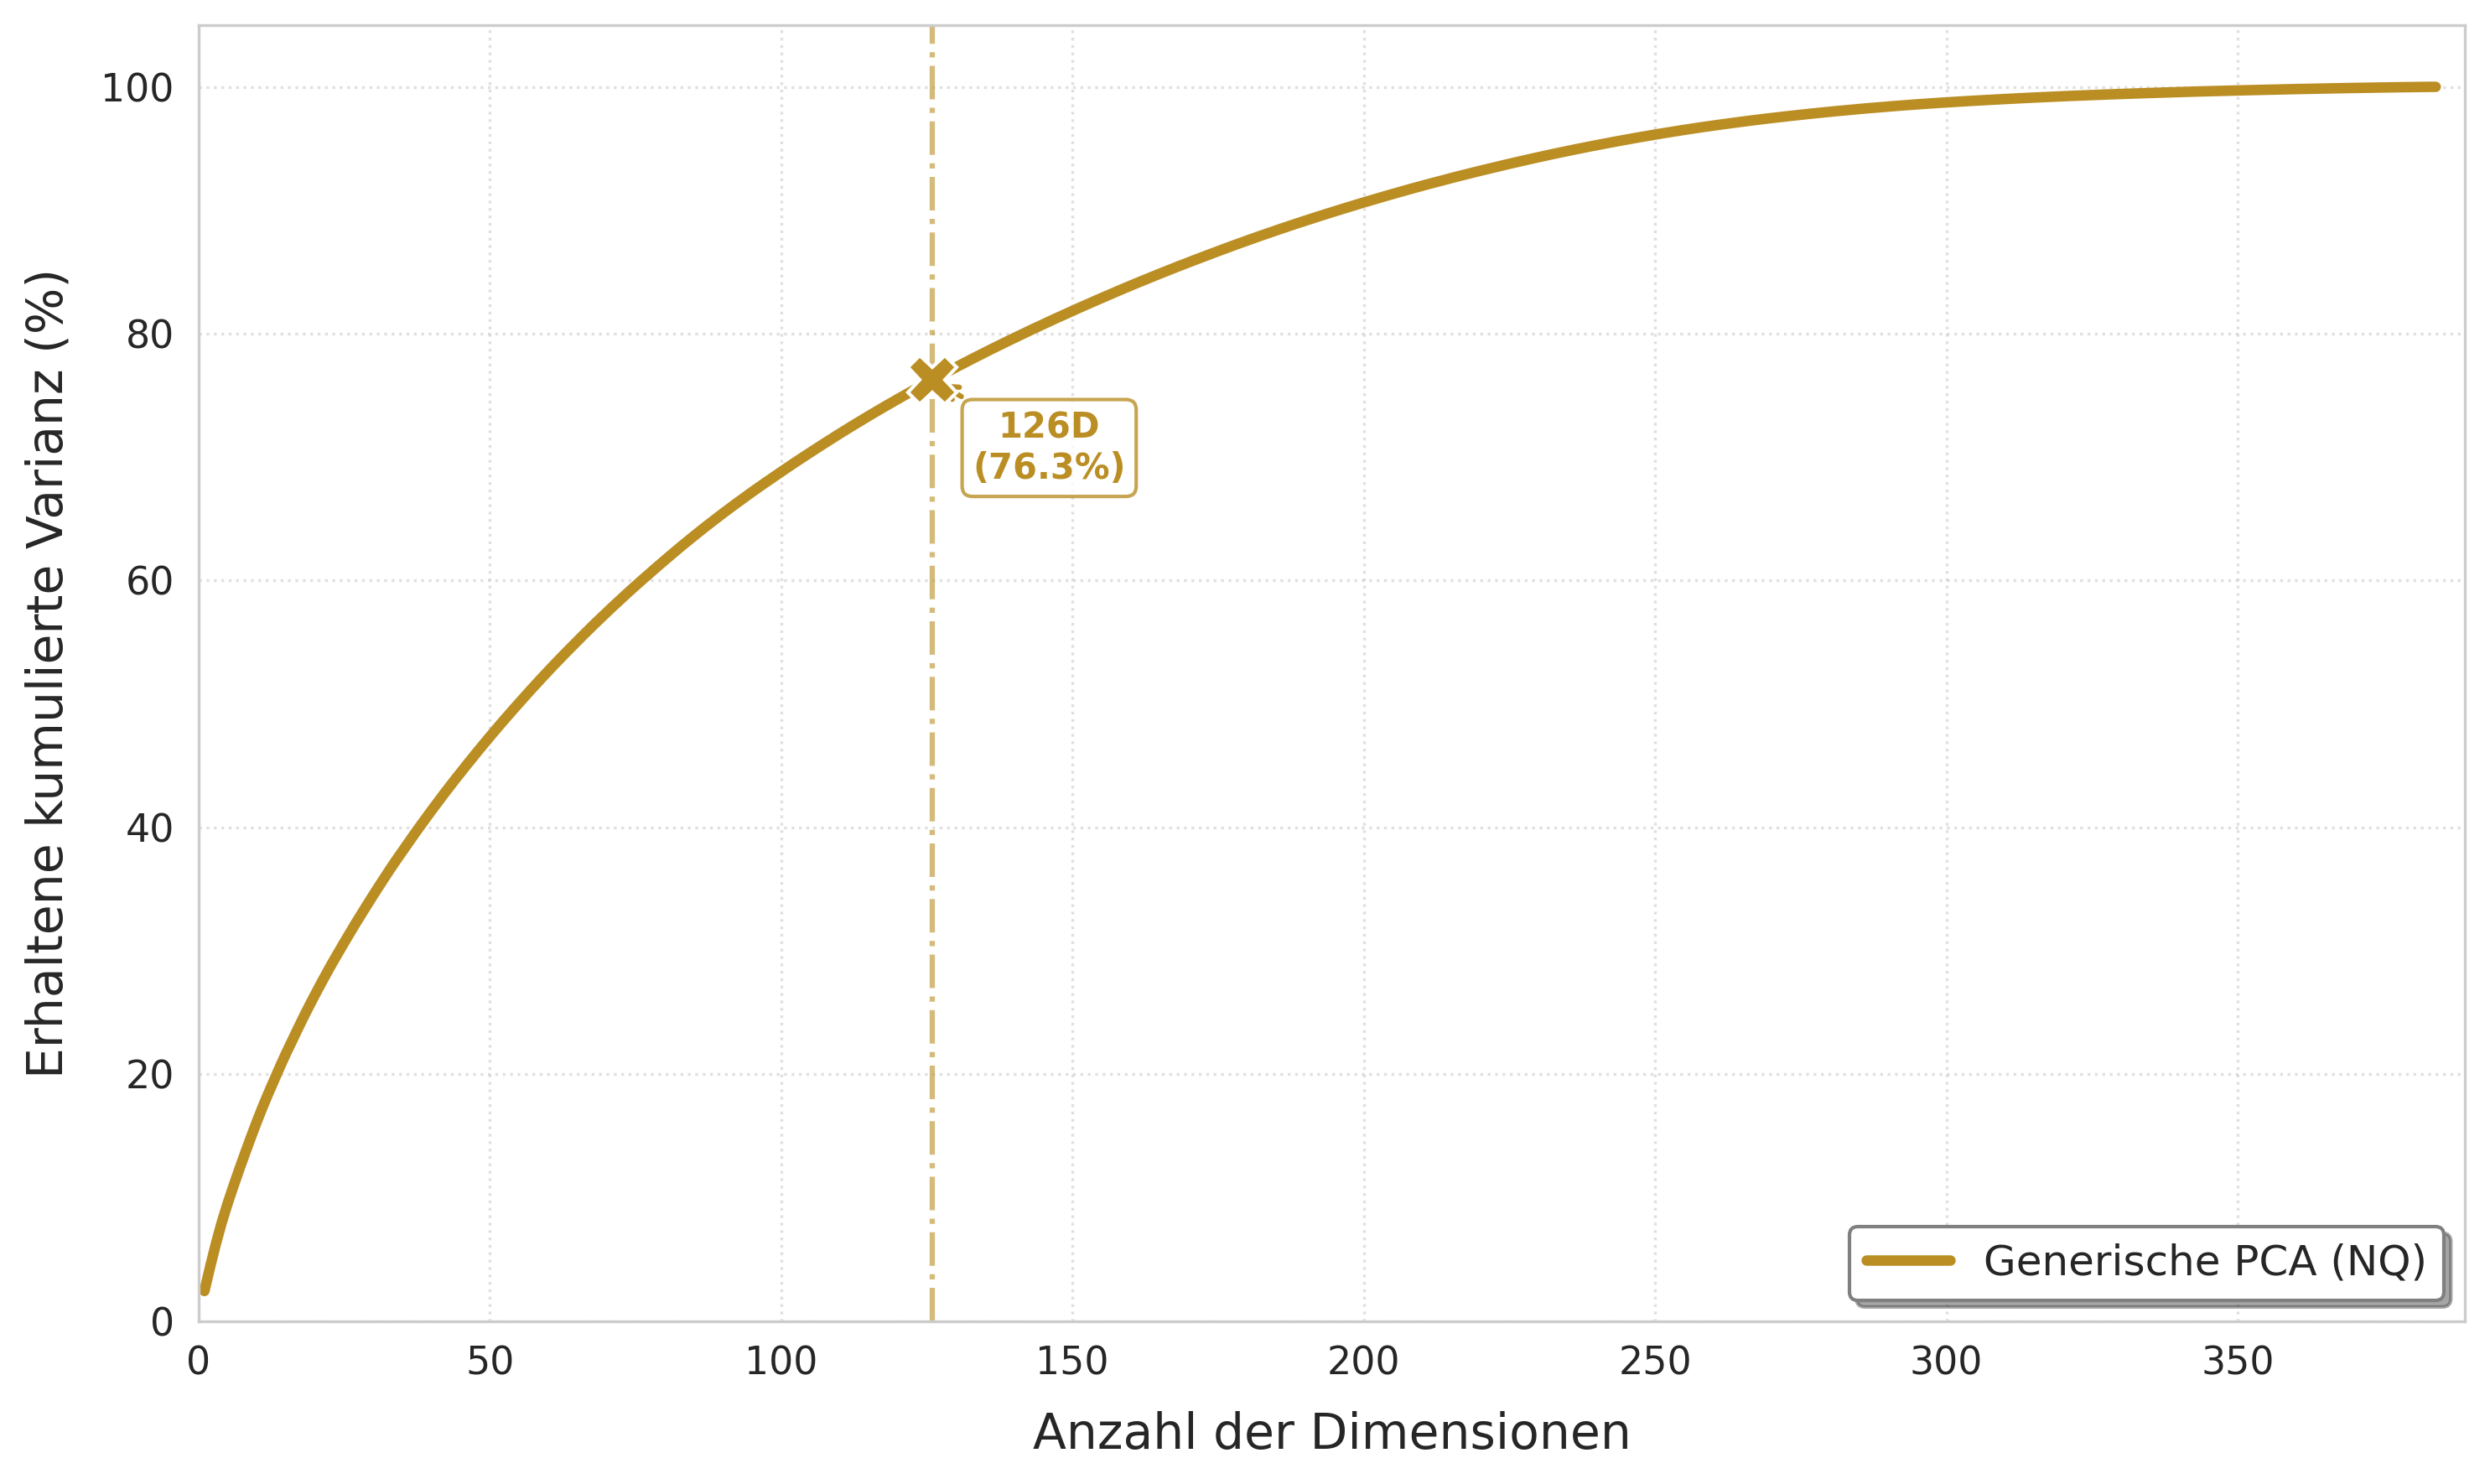

In [394]:
vg = var_gen_gen      
eg = elbow_gen_gen     
GEN_COLOR = '#BA8E23'

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Kurve als durchgezogene Linie 
ax.plot(
    range(1, len(vg)+1), vg, 
    label='Generische PCA', 
    color=GEN_COLOR, 
    linewidth=3, 
    linestyle='-'
)

# Knickpunkt markieren
if eg:
    ax.axvline(x=eg, color=GEN_COLOR, linestyle='-.', alpha=0.6)
    ax.plot(eg, vg[eg - 1], marker='X', markersize=14, color=GEN_COLOR, 
            markeredgecolor='white', zorder=5)
    
    ax.annotate(f'{eg}D\n({vg[eg-1]:.1f}%)', xy=(eg, vg[eg - 1]),
                xytext=(eg + 20, vg[eg - 1] - 8), # Offset leicht angepasst
                fontsize=10, fontweight='bold', color=GEN_COLOR, ha='center',
                arrowprops=dict(arrowstyle='->', color=GEN_COLOR, lw=1.5),
                bbox=dict(facecolor='white', alpha=0.8, edgecolor=GEN_COLOR, boxstyle='round,pad=0.3'))

# Optik & Beschriftung
ax.set_xlabel('Anzahl der Dimensionen', fontsize=14, labelpad=8)
ax.set_ylabel('Erhaltene kumulierte Varianz (%)', fontsize=14, labelpad=8)

ax.set_xlim(0, len(vg) + 5)
ax.set_ylim(0, 105)
ax.grid(True, linestyle=':', alpha=0.6)

# 3D-Legende
ax.legend(loc='lower right', fontsize=12, framealpha=1.0, edgecolor='gray', 
          fancybox=True, shadow=True, frameon=True)

ax.tick_params(labelsize=11)

# Speichern & Anzeigen
plt.tight_layout()
plt.savefig('pca_variance_generic.png', dpi=300, bbox_inches='tight')
plt.show()

In [393]:
domains = [
    ("Generisch vs. Medizin", elbow_gen_on_med, var_med_gen, elbow_med, var_med_spec, pca_med),
    ("Generisch vs. Jura",    elbow_gen_on_law, var_law_gen, elbow_law, var_law_spec, pca_law),
    ("Generisch vs. Finanz",  elbow_gen_on_fin, var_fin_gen, elbow_fin, var_fin_spec, pca_fin),
]

rows = []
for name, elbow_gen, var_gen, elbow_spec, var_spec, pca_obj in domains:
    rows.append({
        "Vergleich":            name,
        "Knick Generisch (Dim)":  elbow_gen,
        "Varianz Generisch":      safe_var(var_gen, elbow_gen),
        "Knick Spezifisch (Dim)": elbow_spec,
        "Varianz Spezifisch":     safe_var(var_spec, elbow_spec),
        "Δ Knickpunkt (Dim)":     f"{elbow_gen - elbow_spec:+d}" if elbow_gen and elbow_spec else "–",
        "Trainings-Samples":      f"{pca_obj.n_samples_:,}",
        "Max. Komponenten":       pca_obj.n_components_,
    })

df_compare = pd.DataFrame(rows)

display(df_compare.style
    .set_caption("Knickpunktvergleich — Generische PCA auf Domänen-Daten vs. Domänen-PCA")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]}
    ])
)

,Vergleich,Knick Generisch (Dim),Varianz Generisch,Knick Spezifisch (Dim),Varianz Spezifisch,Δ Knickpunkt (Dim),Trainings-Samples,Max. Komponenten
0,Generisch vs. Medizin,208,84.7%,101,83.0%,+107,600,384
1,Generisch vs. Jura,166,77.3%,100,86.2%,+66,418,384
2,Generisch vs. Finanz,160,76.7%,29,82.1%,+131,90,90


#### Domänenspezifische PCAs vs. generische PCA

In nächsten Schritt wird der theoretische Kipppunkt der Dimensionsreduktion für die jeweilige Fachdomäne ermittelt. Die kumulierte erklärte Varianz der fachspezifischen PCA wird mit jener der generischen Baseline verglichen. Die generische Pipeline wurde hierfür isoliert auf die Evaluationsdaten der jeweiligen Fachdomäne projiziert.

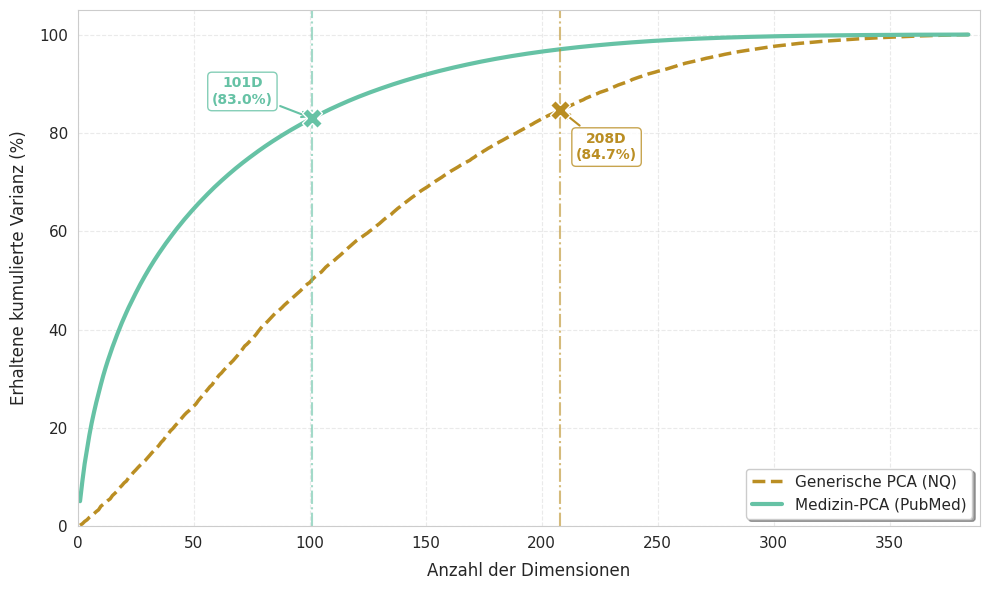

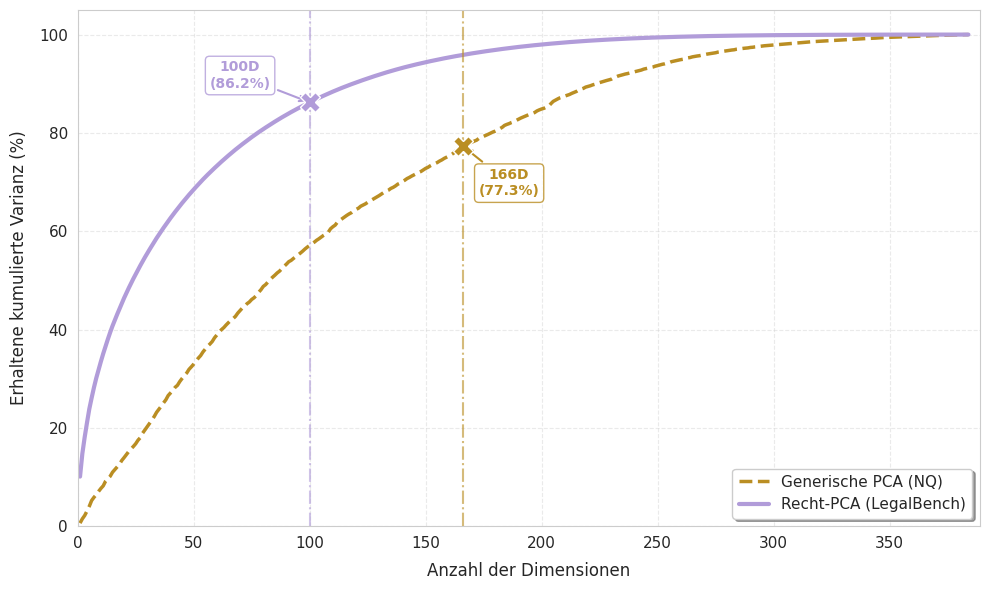

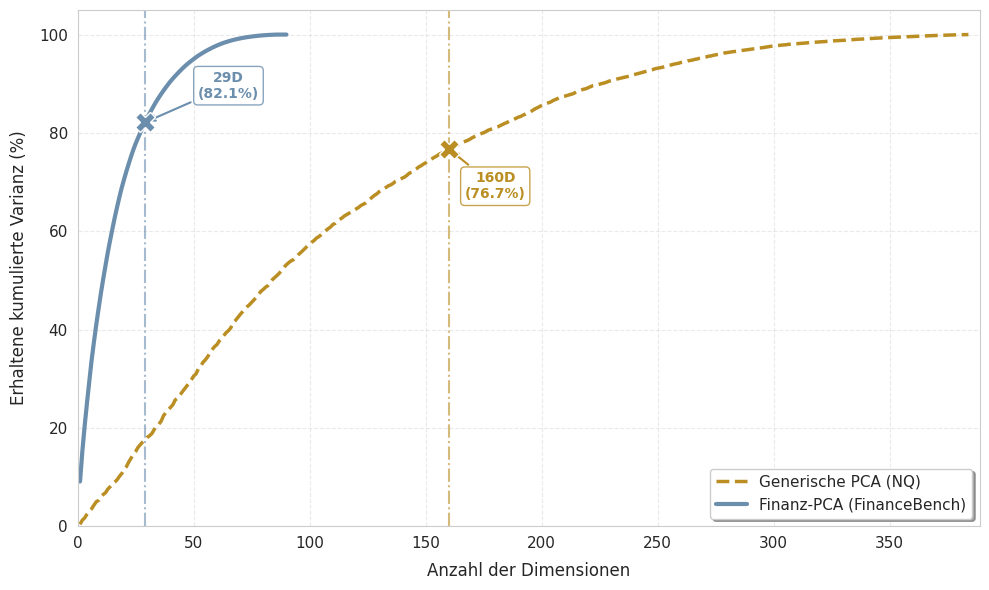

In [395]:
sns.set_style("whitegrid")

domains = [
    {
        "name": "Medizin",
        "var_spec": var_med_spec,        
        "var_gen": var_med_gen,             
        "elbow_spec": elbow_med,
        "elbow_gen": elbow_gen_on_med,
        "color_spec": sns.color_palette("Set2")[0], # Bleibt Grün/Teal
        "label_spec": "Medizin-PCA (PubMed)",
        "gen_offset": (20, -10),
        "dom_offset": (-30, 3),
    },
    {
        "name": "Recht",
        "var_spec": var_law_spec,            
        "var_gen": var_law_gen,             
        "elbow_spec": elbow_law,
        "elbow_gen": elbow_gen_on_law,
        "color_spec": '#B19CD9', 
        "label_spec": "Recht-PCA (LegalBench)",
        "gen_offset": (20, -10),
        "dom_offset": (-30, 3),
    },
    {
        "name": "Finanzen",
        "var_spec": var_fin_spec,            
        "var_gen": var_fin_gen,             
        "elbow_spec": elbow_fin,
        "elbow_gen": elbow_gen_on_fin,
        "color_spec": '#6B8EAD',
        "label_spec": "Finanz-PCA (FinanceBench)",
        "gen_offset": (20, -10),
        "dom_offset": (36, 5),
    },
]

# Schleife direkt über die Domänen 
for dom in domains:
    
    # Eigenständiges Diagramm für jede Domäne erstellen 
    fig, ax = plt.subplots(figsize=(10, 6))
    
    vg = dom["var_gen"]
    vs = dom["var_spec"]
    eg = dom["elbow_gen"]
    es = dom["elbow_spec"]
    
    # Kurven
    ax.plot(range(1, len(vg)+1), vg, 
            label='Generische PCA (NQ)',
            color='#BA8E23', linewidth=2.5, linestyle='--')
    ax.plot(range(1, len(vs)+1), vs, 
            label=dom["label_spec"],
            color=dom["color_spec"], linewidth=3)
    
    # Knickpunkt Generisch
    if eg:
        ax.axvline(x=eg, color='#BA8E23', linestyle='-.', alpha=0.6)
        ax.plot(eg, vg[eg - 1],
                marker='X', markersize=14, color='#BA8E23', 
                markeredgecolor='white', zorder=5)
        ax.annotate(
            f'{eg}D\n({vg[eg-1]:.1f}%)',
            xy=(eg, vg[eg - 1]),
            xytext=(eg + dom["gen_offset"][0],
                    vg[eg - 1] + dom["gen_offset"][1]),
            fontsize=10, fontweight='bold', color='#BA8E23', ha='center',
            arrowprops=dict(arrowstyle='->', color='#BA8E23', lw=1.5),
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#BA8E23',
                      boxstyle='round,pad=0.3')
        )
    
    # Knickpunkt Domäne
    col_s = dom["color_spec"]
    if es:
        ax.axvline(x=es, color=col_s, linestyle='-.', alpha=0.6)
        ax.plot(es, vs[es - 1],
                marker='X', markersize=14, color=col_s,
                markeredgecolor='white', zorder=5)
        ax.annotate(
            f'{es}D\n({vs[es-1]:.1f}%)',
            xy=(es, vs[es - 1]),
            xytext=(es + dom["dom_offset"][0],
                    vs[es - 1] + dom["dom_offset"][1]),
            fontsize=10, fontweight='bold', color=col_s, ha='center',
            arrowprops=dict(arrowstyle='->', color=col_s, lw=1.5),
            bbox=dict(facecolor='white', alpha=0.8, edgecolor=col_s,
                      boxstyle='round,pad=0.3')
        )
    
    # Achsen & Titel für den Einzelplot
    ax.set_xlabel('Anzahl der Dimensionen', fontsize=12, labelpad=8)
    ax.set_ylabel('Erhaltene kumulierte Varianz (%)', fontsize=12, labelpad=8)
    
    ax.set_xlim(0, max(len(vg), len(vs)) + 5)
    ax.set_ylim(0, 105)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
    ax.tick_params(labelsize=11)

    plt.tight_layout()
    
    # Dynamischer Dateiname pro Diagramm
    dateiname = f'pca_variance_{dom["name"].lower()}.png'
    plt.savefig(dateiname, dpi=300, bbox_inches='tight')

    plt.show()

### Schwellenwert-Analyse

Nachdem die Retrieval-Metriken bereits für alle Domänen berechnet wurden, steht nun deren systematische Analyse im Fokus. Im Gegensatz zur Varianz-Kurve verlaufen Retrieval-Metriken in der Praxis nicht vollständig glatt, sondern weisen leichte Fluktuationen auf. Da automatisierte Verfahren wie der Kneedle-Algorithmus bei solchen instabilen Kurvenverläufen unzuverlässig sind, erfolgt in diesem Schritt **Schwellenwert-Analyse**. Es wird berechnet, ab welcher Dimension die Modelle einen definierten Prozentsatz ihrer Maximalleistung erreichen.

Zur Vorbereitung der extrinsischen Analyse werden die Metrik-Datensätze aller Domänen geladen und die Ziel-Parameter sowie Schwellenwerte ($90\,\%$, $95\,\%$ und $99\,\%$) für die anschließende Sättigungsprüfung definiert.

In [433]:
# Konstanten
METRIC_INDEX = {
    'MRR@10':      0,
    'NDCG@10':     1,
    'Precision@1': 2,
    'Hit Rate@10': 3,
    'Mean Rank':   4,  
    'Latenz (ms)': 5, 
}
METRICS = list(METRIC_INDEX.keys())
SELECTED_METRICS = ['MRR@10', 'NDCG@10', 'Precision@1', 'Hit Rate@10']
THRESHOLDS = [0.90, 0.95, 0.99, 1.00] 
THRESH_LS  = {0.90: ':',  0.95: '--', 0.99: '-.', 1.00: '-'}
THRESH_LW  = {0.90: 1.5,  0.95: 2.2,  0.99: 1.5,  1.00: 1.0}
MARKER_SZ  = {0.90: 5,    0.95: 7,    0.99: 5,    1.00: 5}
BASE_DIM = 384
dims_list = np.arange(1, BASE_DIM + 1)

# Daten
gen_metrics_med = joblib.load(PATHS["med_gen"]  / "metrics_384D.joblib")
med_metrics     = joblib.load(PATHS["med_spec"] / "metrics_384D.joblib")
gen_metrics_law = joblib.load(PATHS["law_gen"]  / "metrics_384D.joblib")
law_metrics     = joblib.load(PATHS["law_spec"] / "metrics_384D.joblib")
gen_metrics_fin = joblib.load(PATHS["fin_gen"]  / "metrics_384D.joblib")
fin_metrics     = joblib.load(PATHS["fin_spec"] / "metrics_384D.joblib")

DOMAINS = [
    {"name": "Medizin", "gen_metrics": gen_metrics_med, "spec_metrics": med_metrics},
    {"name": "Recht",    "gen_metrics": gen_metrics_law, "spec_metrics": law_metrics},
    {"name": "Finanz",  "gen_metrics": gen_metrics_fin, "spec_metrics": fin_metrics},
]

#### Generische PCA

Zunächst werden die Schwellenwerte der Metriken nach Anwendung der generischen PCA auf den generischen NQ-Benchmark in **tabellarischer Form** dargestellt.

In [434]:
table_data = [] 

for metric in SELECTED_METRICS:
    d_gen, v_gen = extract_metric_curve(gen_metrics_gen, dims_list, metric)
    
    for t in THRESHOLDS:
        e_gen = find_threshold_elbow(d_gen, v_gen, t)
        t_label = "100%" if t == 1.00 else f"{int(t*100)}%"
        
        row = [
            metric, 
            t_label,
            str(e_gen) if e_gen else "–",
            safe_val_at_dim(d_gen, v_gen, e_gen)
        ]
        table_data.append(row)

# Spalten anpassen 
columns = ["Metrik", "Schwelle", "Dimension (Gen)", "Metrik-Wert"]
df_compact_gen = pd.DataFrame(table_data, columns=columns).set_index(["Metrik", "Schwelle"])

print(f"\n{'='*60}\n  KOMPAKTE SCHWELLENWERT-ANALYSE: GENERISCHE BASELINE\n{'='*60}")
styled_df_gen = (df_compact_gen.style
             .set_properties(**{'text-align': 'center'})
             .set_table_styles([
                 {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#f4f4f4')]}
             ]))
display(styled_df_gen)


  KOMPAKTE SCHWELLENWERT-ANALYSE: GENERISCHE BASELINE


Ergänzend zur tabellarischen Übersicht visualisiert der nachfolgende Plot den kontinuierlichen **Kurvenverlauf** aller vier Retrieval-Metriken über die abnehmende Dimensionalität. Zur besseren Einordnung des Informationsverlusts sind die zuvor berechneten Schwellenwerte als vertikale Hilfslinien eingezeichnet.

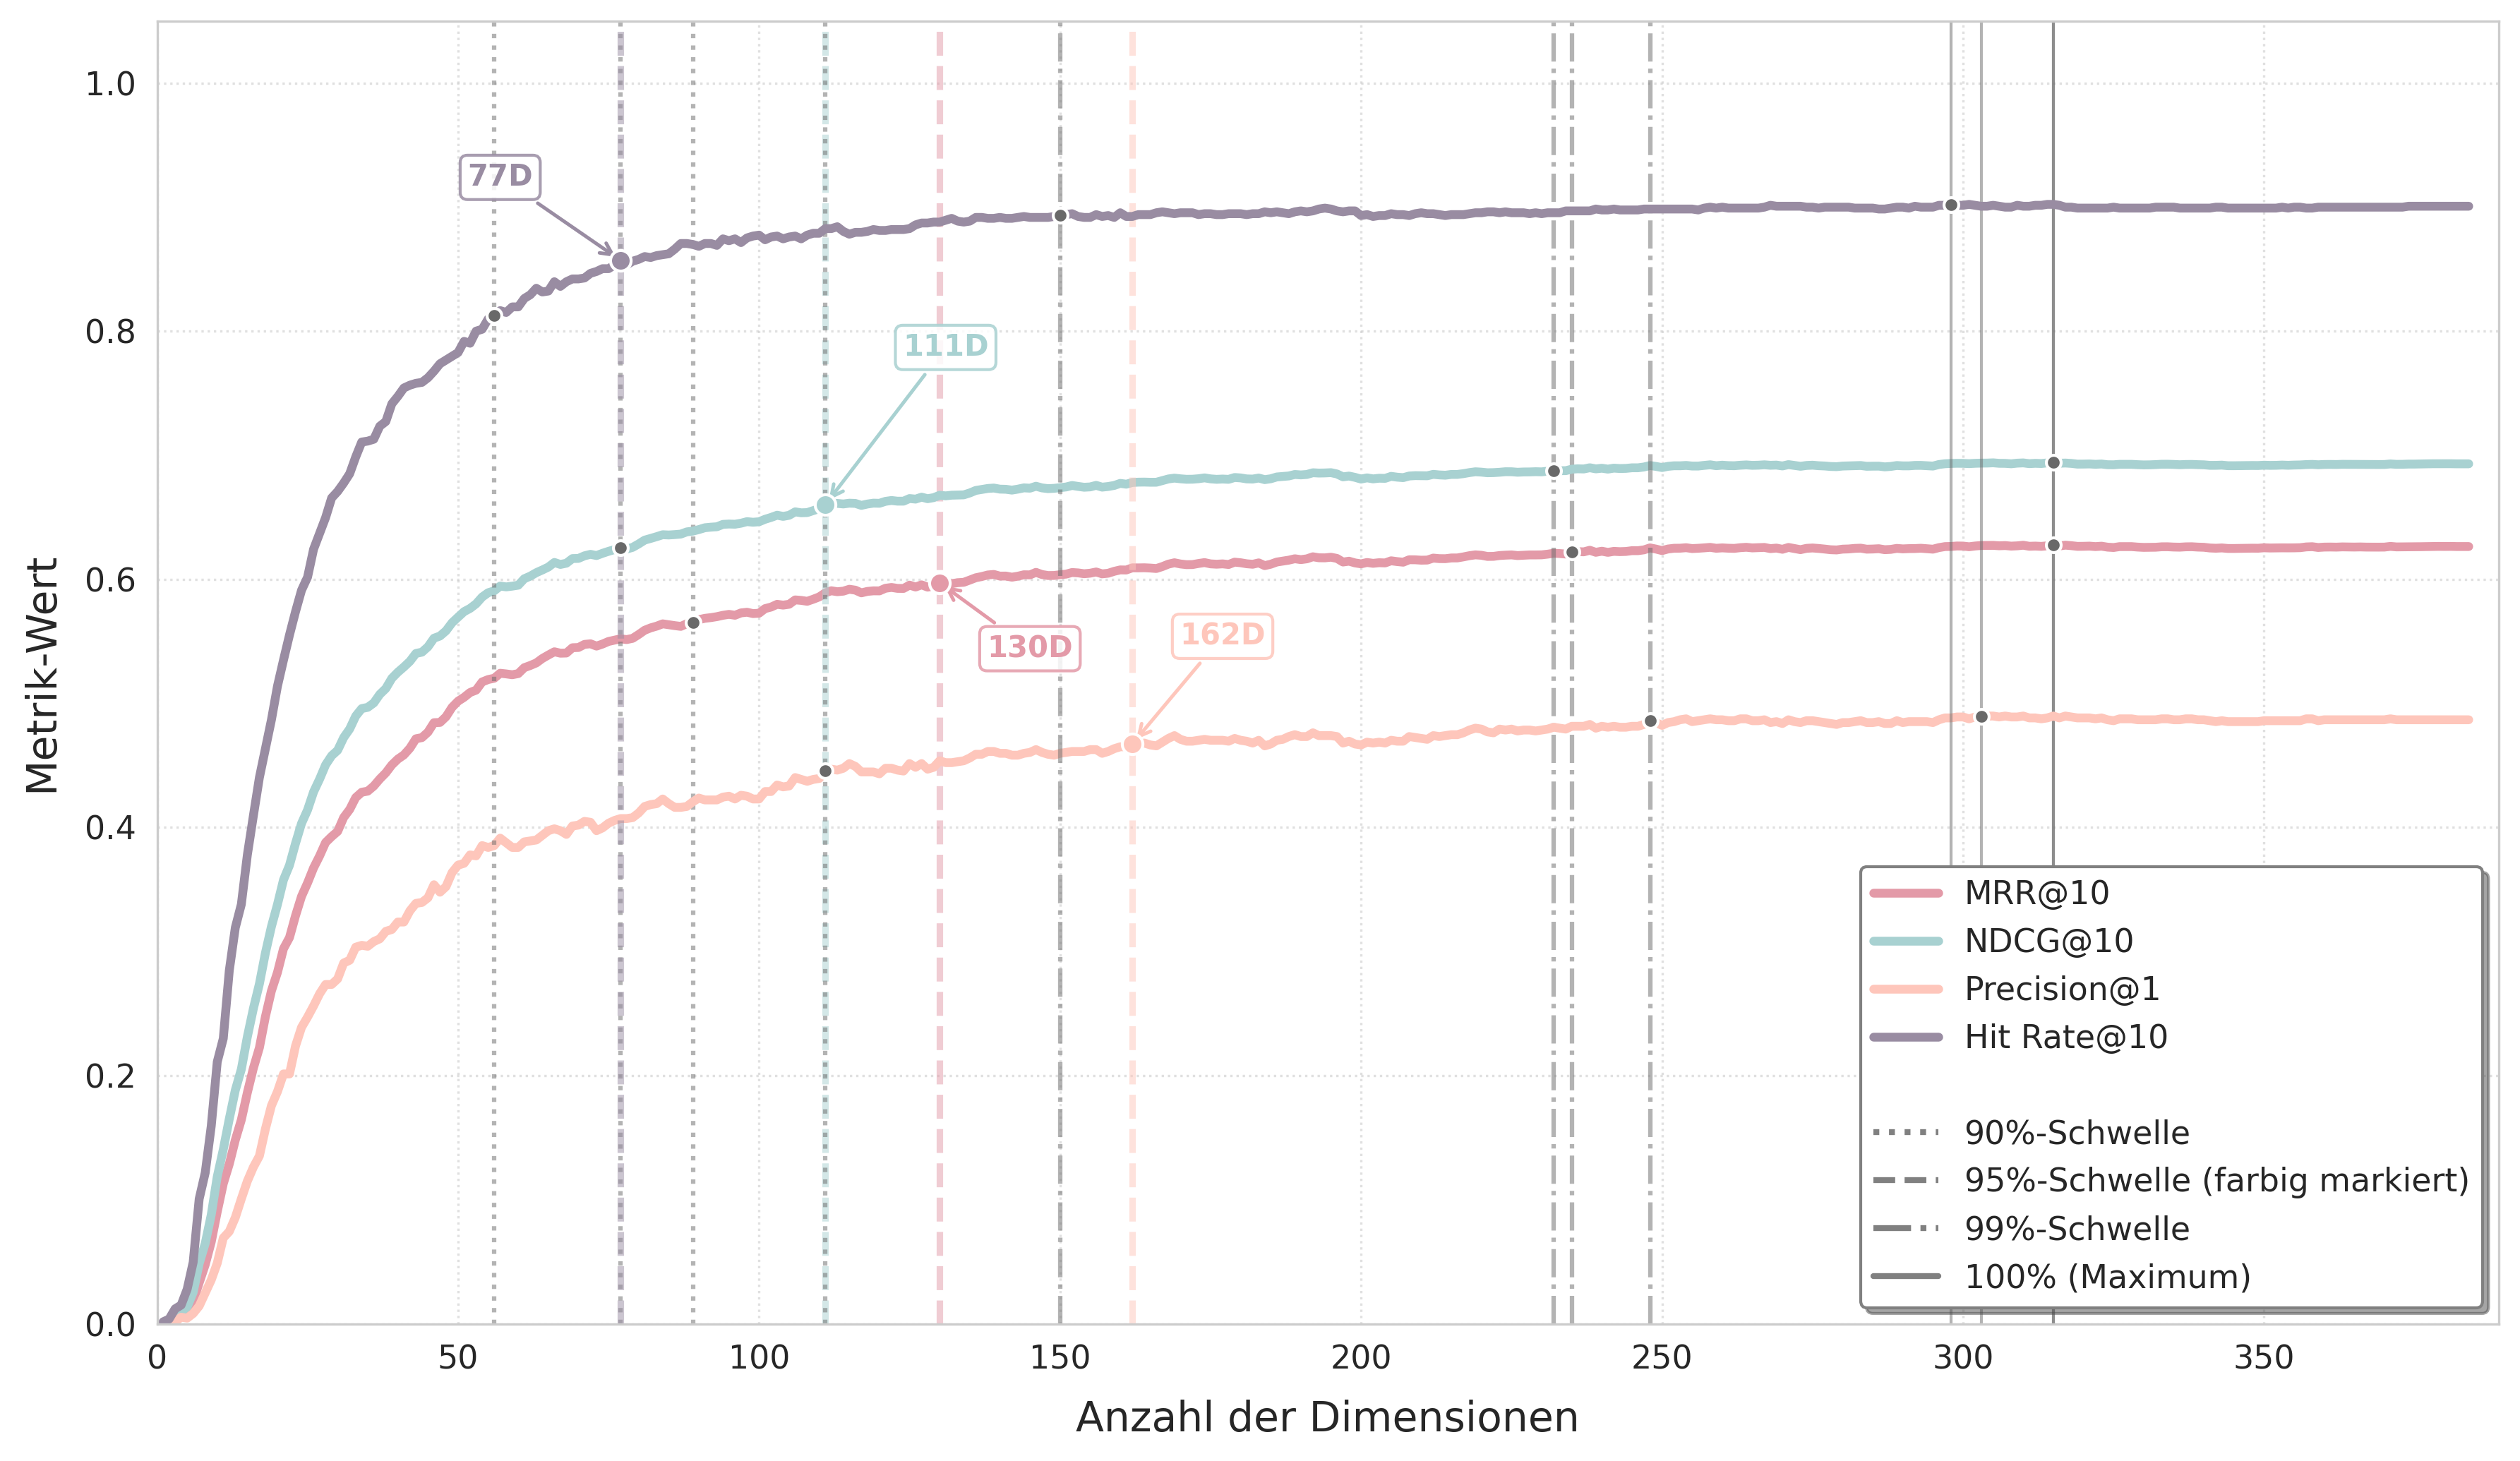

In [435]:
sns.set_style("whitegrid")
# Farben
METRIC_COLORS = {
    'MRR@10': '#E39AA8',
    'NDCG@10': '#A8D1D1',
    'Precision@1': '#FEC6BB',
    'Hit Rate@10': '#998CA2'
}

# Individuelle Offsets für die 95%-Labels, damit sie nicht überlappen
ANNOTATION_OFFSETS = {
    'MRR@10': (15, -0.06),       
    'NDCG@10': (20, 0.12),      
    'Precision@1': (15, 0.08),  
    'Hit Rate@10': (-20, 0.06)   
}


fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

for metric in SELECTED_METRICS:
    # Daten extrahieren
    d_gen, v_gen = extract_metric_curve(gen_metrics_gen, dims_list, metric)
    color = METRIC_COLORS[metric]
    
    if len(d_gen) > 0:
        # Haupt-Kurve
        ax.plot(d_gen, v_gen, linestyle='-', linewidth=3.0, color=color, label=metric)
        
        # Schwellenwerte
        for t in THRESHOLDS:
            e_gen = find_threshold_elbow(d_gen, v_gen, t)
            
            if e_gen and e_gen in d_gen:
                val = v_gen[d_gen == e_gen][0]
                
                # Farb-Weiche 
                line_color = color if t == 0.95 else 'dimgray'
                
                # Vertikale Linie & Marker
                ax.axvline(x=e_gen, color=line_color, linestyle=THRESH_LS[t], alpha=0.5, linewidth=THRESH_LW[t])
                ax.plot(e_gen, val, marker='o', color=line_color, markersize=MARKER_SZ[t], markeredgecolor='white', zorder=5)
                
                # Annotation für 95%
                if t == 0.95:
                    # Holen des spezifischen Offsets für diese Metrik
                    off_x, off_y = ANNOTATION_OFFSETS[metric]
                    
                    ax.annotate(f'{e_gen}D', xy=(e_gen, val), 
                                xytext=(e_gen + off_x, val + off_y), 
                                fontsize=10, fontweight='bold', color=color,
                                ha='center',
                                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=color, alpha=0.85))

# Optik
ax.set_xlabel("Anzahl der Dimensionen", fontsize=14, labelpad=8)
ax.set_ylabel("Metrik-Wert", fontsize=14, labelpad=8)

ax.set_xlim(0, BASE_DIM + 5)
ax.set_ylim(0, 1.05)

# Hintergrundraster
ax.grid(True, linestyle=":", alpha=0.6)

# Legende
handles, labels = ax.get_legend_handles_labels()

# Platzhalter-Zeile einfügen
handles.append(plt.Line2D([0], [0], color='none'))
labels.append('')

# Schwellenwert-Infos zur Legende hinzufügen
legend_items = [
    (':', '90%-Schwelle'), 
    ('--', '95%-Schwelle (farbig markiert)'), 
    ('-.', '99%-Schwelle'),
    ('-', '100% (Maximum)')
]

for ls, lbl in legend_items:
    handles.append(plt.Line2D([0], [0], color='gray', linestyle=ls, linewidth=2.0))
    labels.append(lbl)

# Legende zeichnen
ax.legend(
    handles, labels,
    fontsize=11, 
    loc="lower right", 
    framealpha=1.0, 
    edgecolor='gray', 
    fancybox=True, 
    shadow=True, 
    frameon=True
)

ax.tick_params(labelsize=11)

# Speichern & Anzeigen
plt.tight_layout()
plt.savefig("plot_all_metrics_combined_generic_thresholds.png", dpi=300, bbox_inches='tight')
plt.show()

#### Domänenspezifische PCAs vs. generische PCA

Für jede Fachdomäne (Medizin, Recht, Finanzen) wird nun **tabellarisch** gegenübergestellt, ab welcher Dimension die definierten Qualitätsniveaus unterschritten werden. Um die Effizienzsteigerung durch das fachspezifische PCA-Training zu quantifizieren, wird zusätzlich das Delta ($\Delta$) berechnet. Dieses Delta zeigt auf, wie viel stärker das spezifische Modell komprimiert werden kann, bevor es denselben relativen Informationsverlust wie das generische Modell erleidet.

In [429]:
all_results = {}

for dom in DOMAINS:
    name = dom["name"]
    all_results[name] = {}
    table_data = [] 
    
    for metric in SELECTED_METRICS:
        # Daten extrahieren
        d_gen,  v_gen  = extract_metric_curve(dom["gen_metrics"],  dims_list, metric)
        d_spec, v_spec = extract_metric_curve(dom["spec_metrics"], dims_list, metric)
        
        for t in THRESHOLDS:
            e_gen  = find_threshold_elbow(d_gen,  v_gen,  t)
            e_spec = find_threshold_elbow(d_spec, v_spec, t)
            
            # Δ% berechnen
            if e_gen and e_spec:
                delta_pct = f"−{((e_gen - e_spec) / e_gen * 100):.0f}%"
                # ---> HIER IST DIE NEUE ZEILE <---
                delta_pct = delta_pct.replace("−-", "+") 
            else:
                delta_pct = "–"
            
            # Label für die Schwelle
            t_label = "100%" if t == 1.00 else f"{int(t*100)}%"
            
            # Zeile aufbauen
            row = [
                metric, 
                t_label,
                str(e_gen)  if e_gen  else "–",
                str(e_spec) if e_spec else "–",
                delta_pct,
                safe_val_at_dim(d_gen,  v_gen,  e_gen),
                safe_val_at_dim(d_spec, v_spec, e_spec)
            ]
            
            table_data.append(row)
        
        # Rohdaten für Plots speichern
        all_results[name][metric] = {
            'd_gen': d_gen, 'v_gen': v_gen,
            'd_spec': d_spec, 'v_spec': v_spec,
        }
    
    # Spalten definieren
    columns = [
        "Metrik", "Schwelle", 
        "Dim Gen", "Dim Spec", "Δ Dim", 
        "Wert Gen", "Wert Spec"
    ]
    
    # DataFrame erstellen und Index setzen
    df_compact = pd.DataFrame(table_data, columns=columns)
    df_compact = df_compact.set_index(["Metrik", "Schwelle"])
    
    # Ausgabe
    print(f"\n{'='*60}")
    print(f"  KOMPAKTE SCHWELLENWERT-ANALYSE: {name.upper()}")
    print(f"{'='*60}")
    
    styled_df = (df_compact.style
                 .set_properties(**{'text-align': 'center'})
                 .set_table_styles([
                     {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#f4f4f4')]}
                 ]))
    
    display(styled_df)


  KOMPAKTE SCHWELLENWERT-ANALYSE: MEDIZIN



  KOMPAKTE SCHWELLENWERT-ANALYSE: RECHT



  KOMPAKTE SCHWELLENWERT-ANALYSE: FINANZ


Zur visuellen Einordnung des tabellarischen Vergleichs werden die Kurvenverläufe der domänenspezifischen PCA (farbig) und der generischen Baseline (gestrichelt) für alle vier Retrieval-Metriken in einem kombinierten **Matrix-Plot** übereinandergelegt. Die vertikalen Schwellenlinien (insbesondere der hervorgehobene 95-%-Marker) verdeutlichen den horizontalen Versatz beider Kurven.

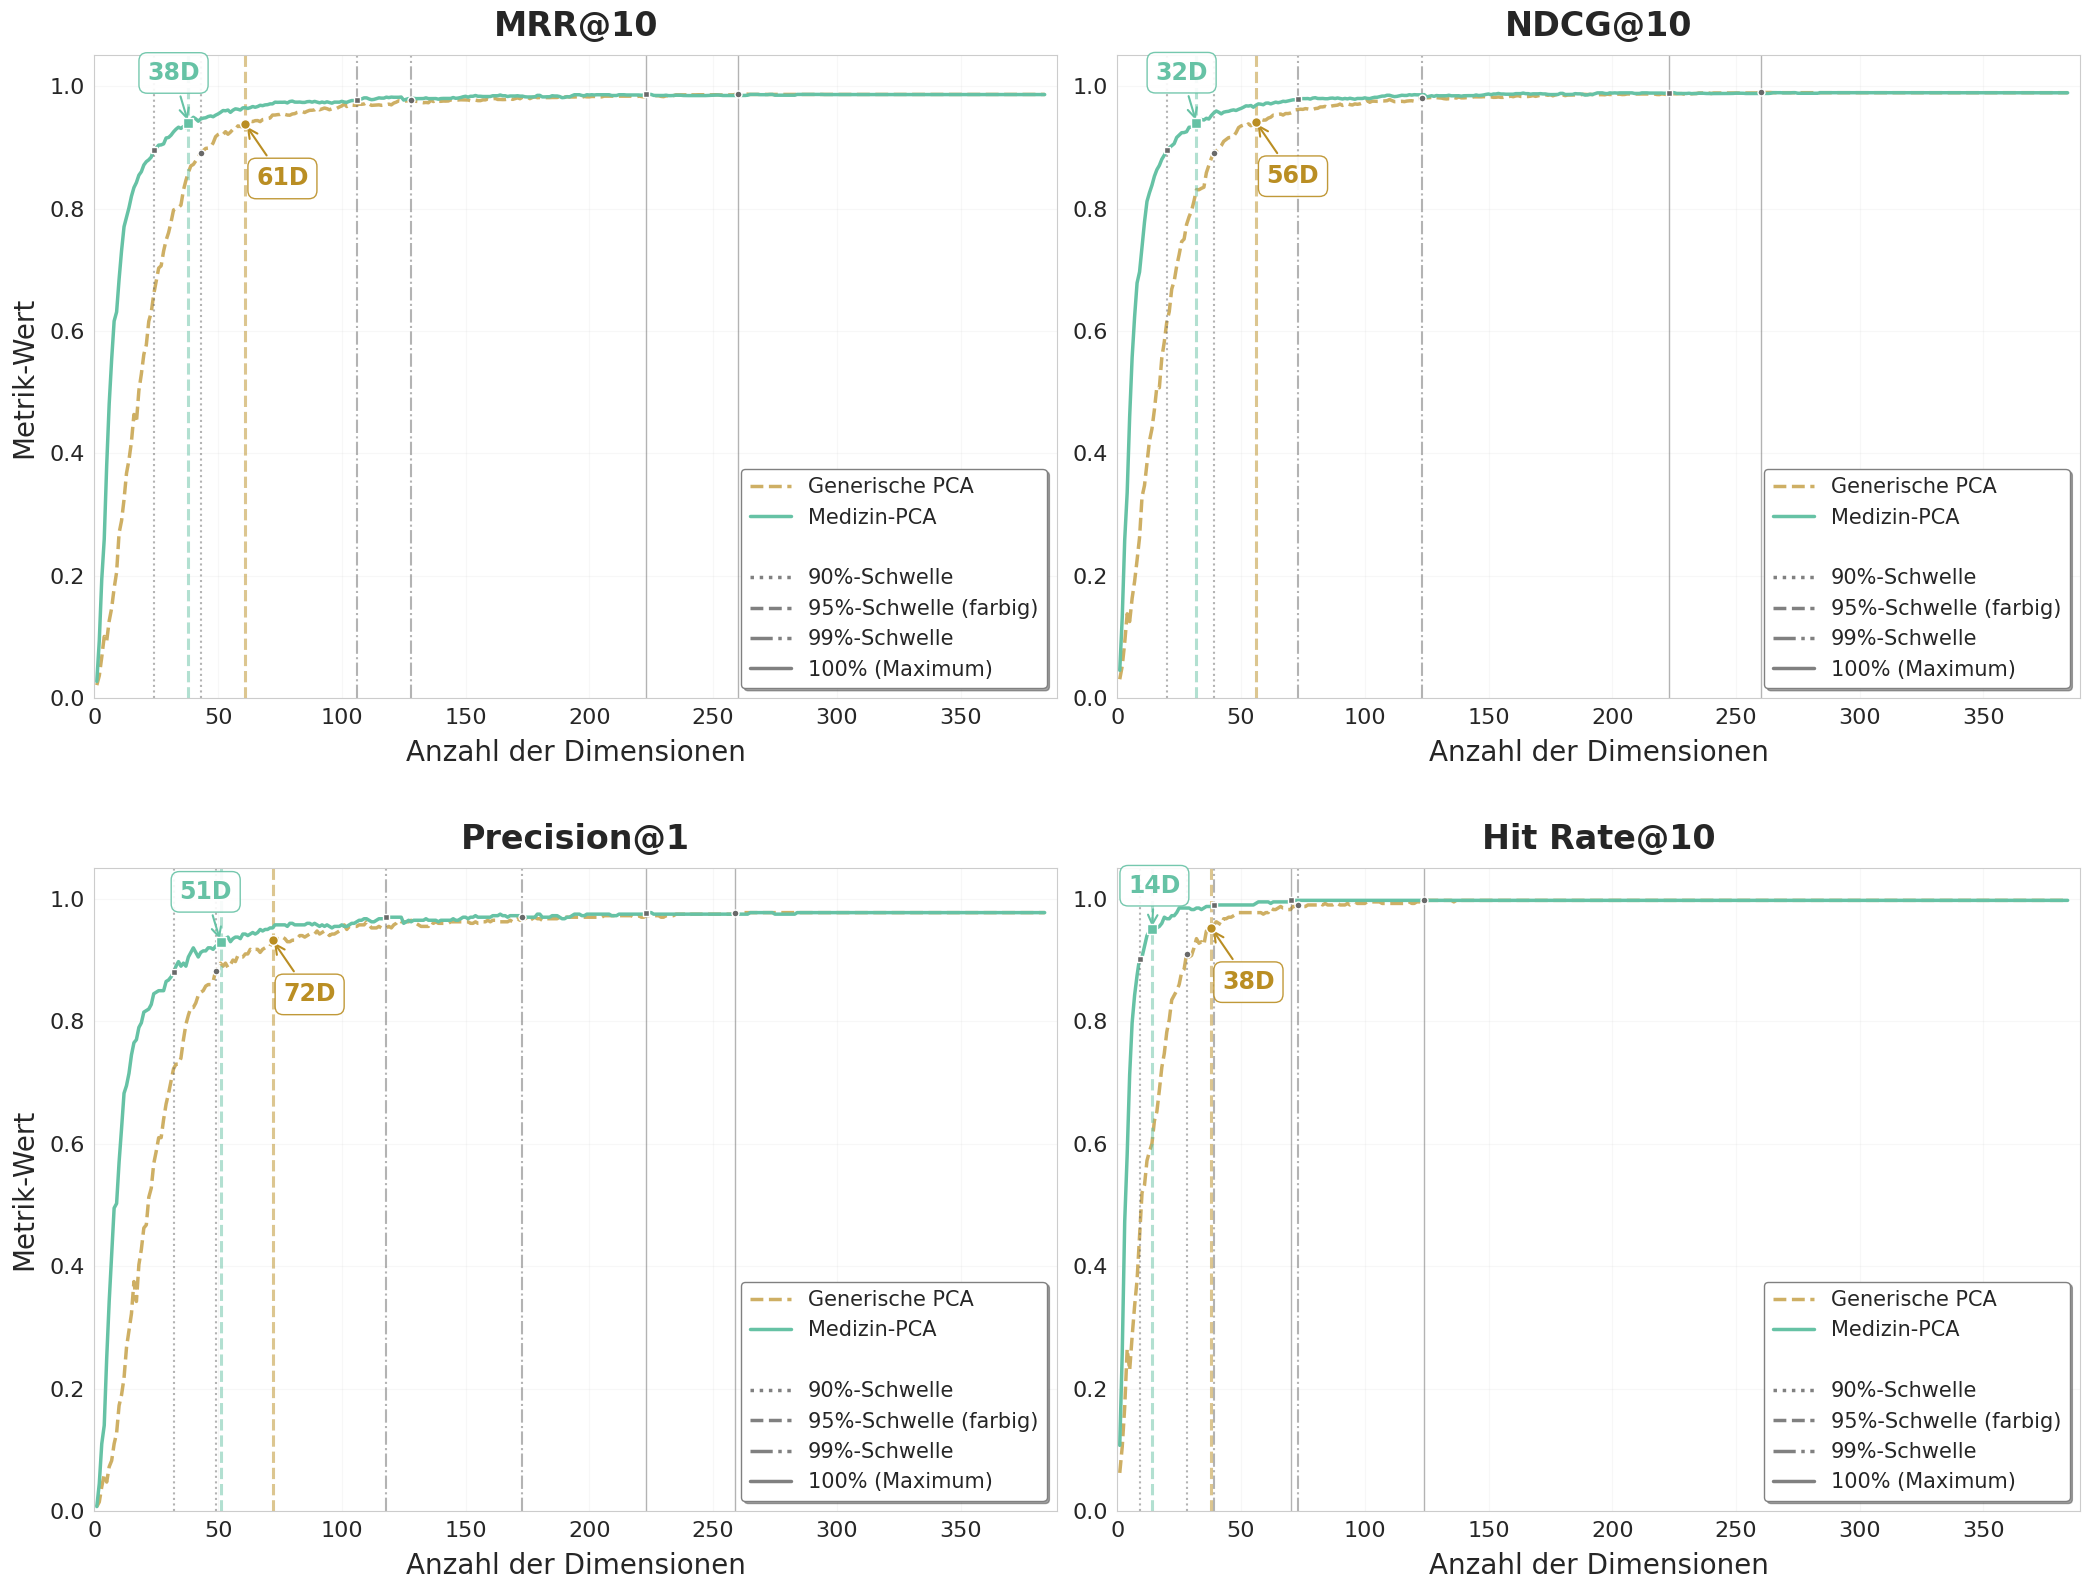

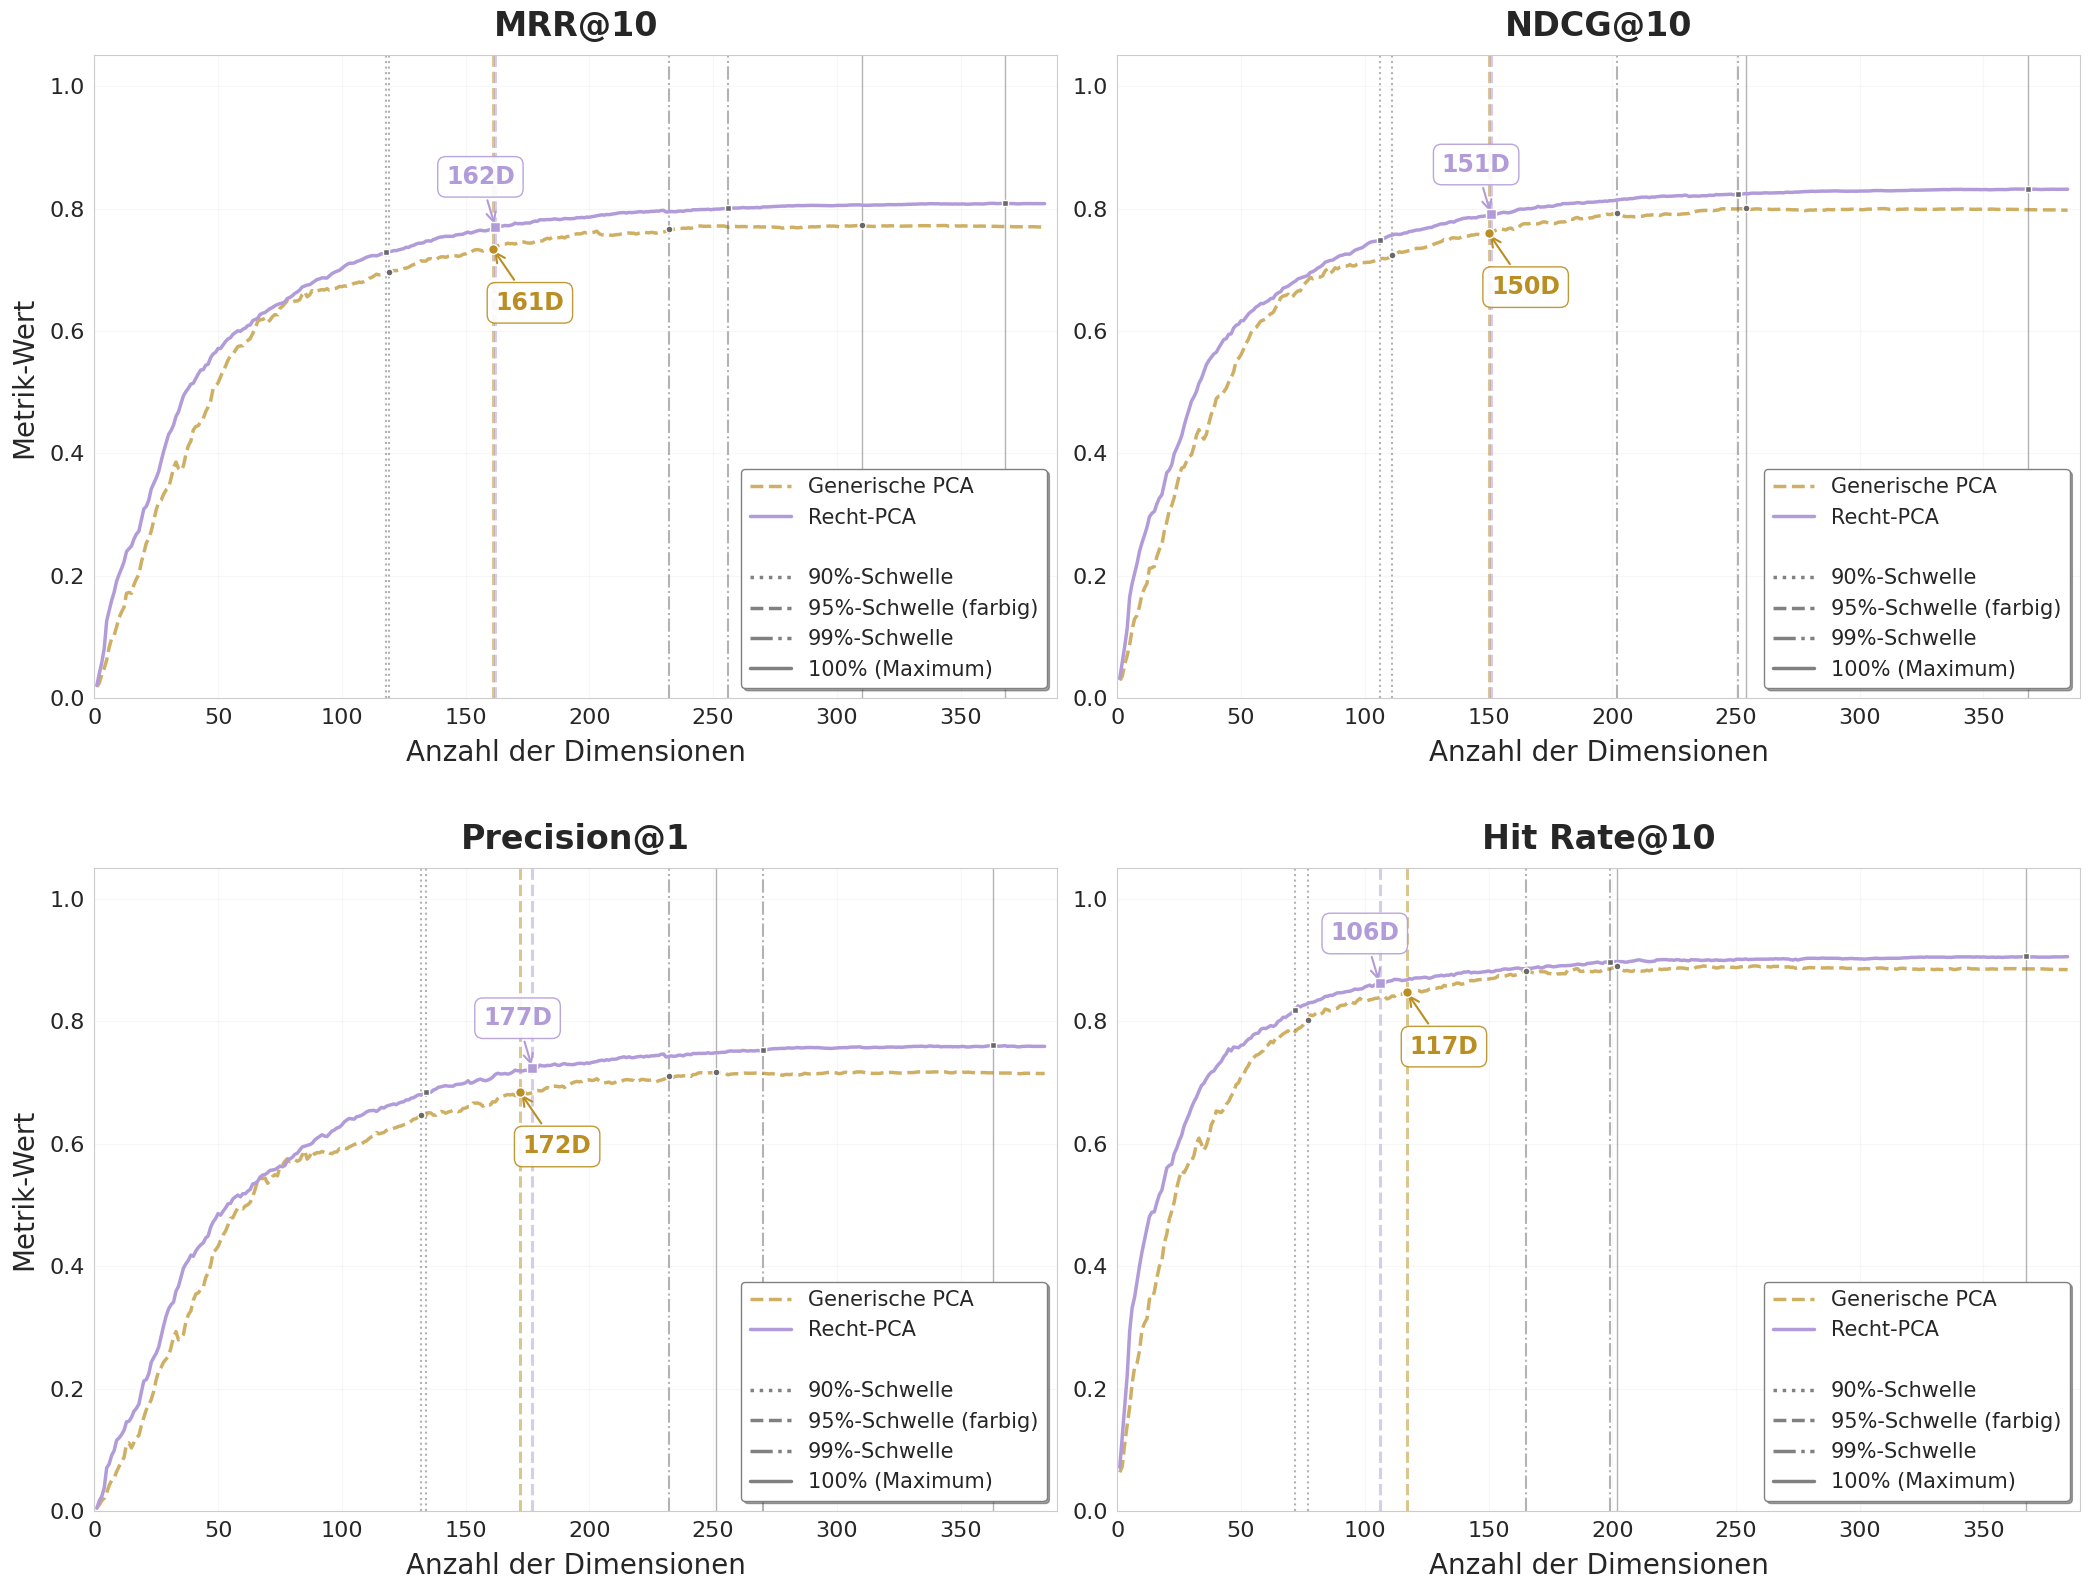

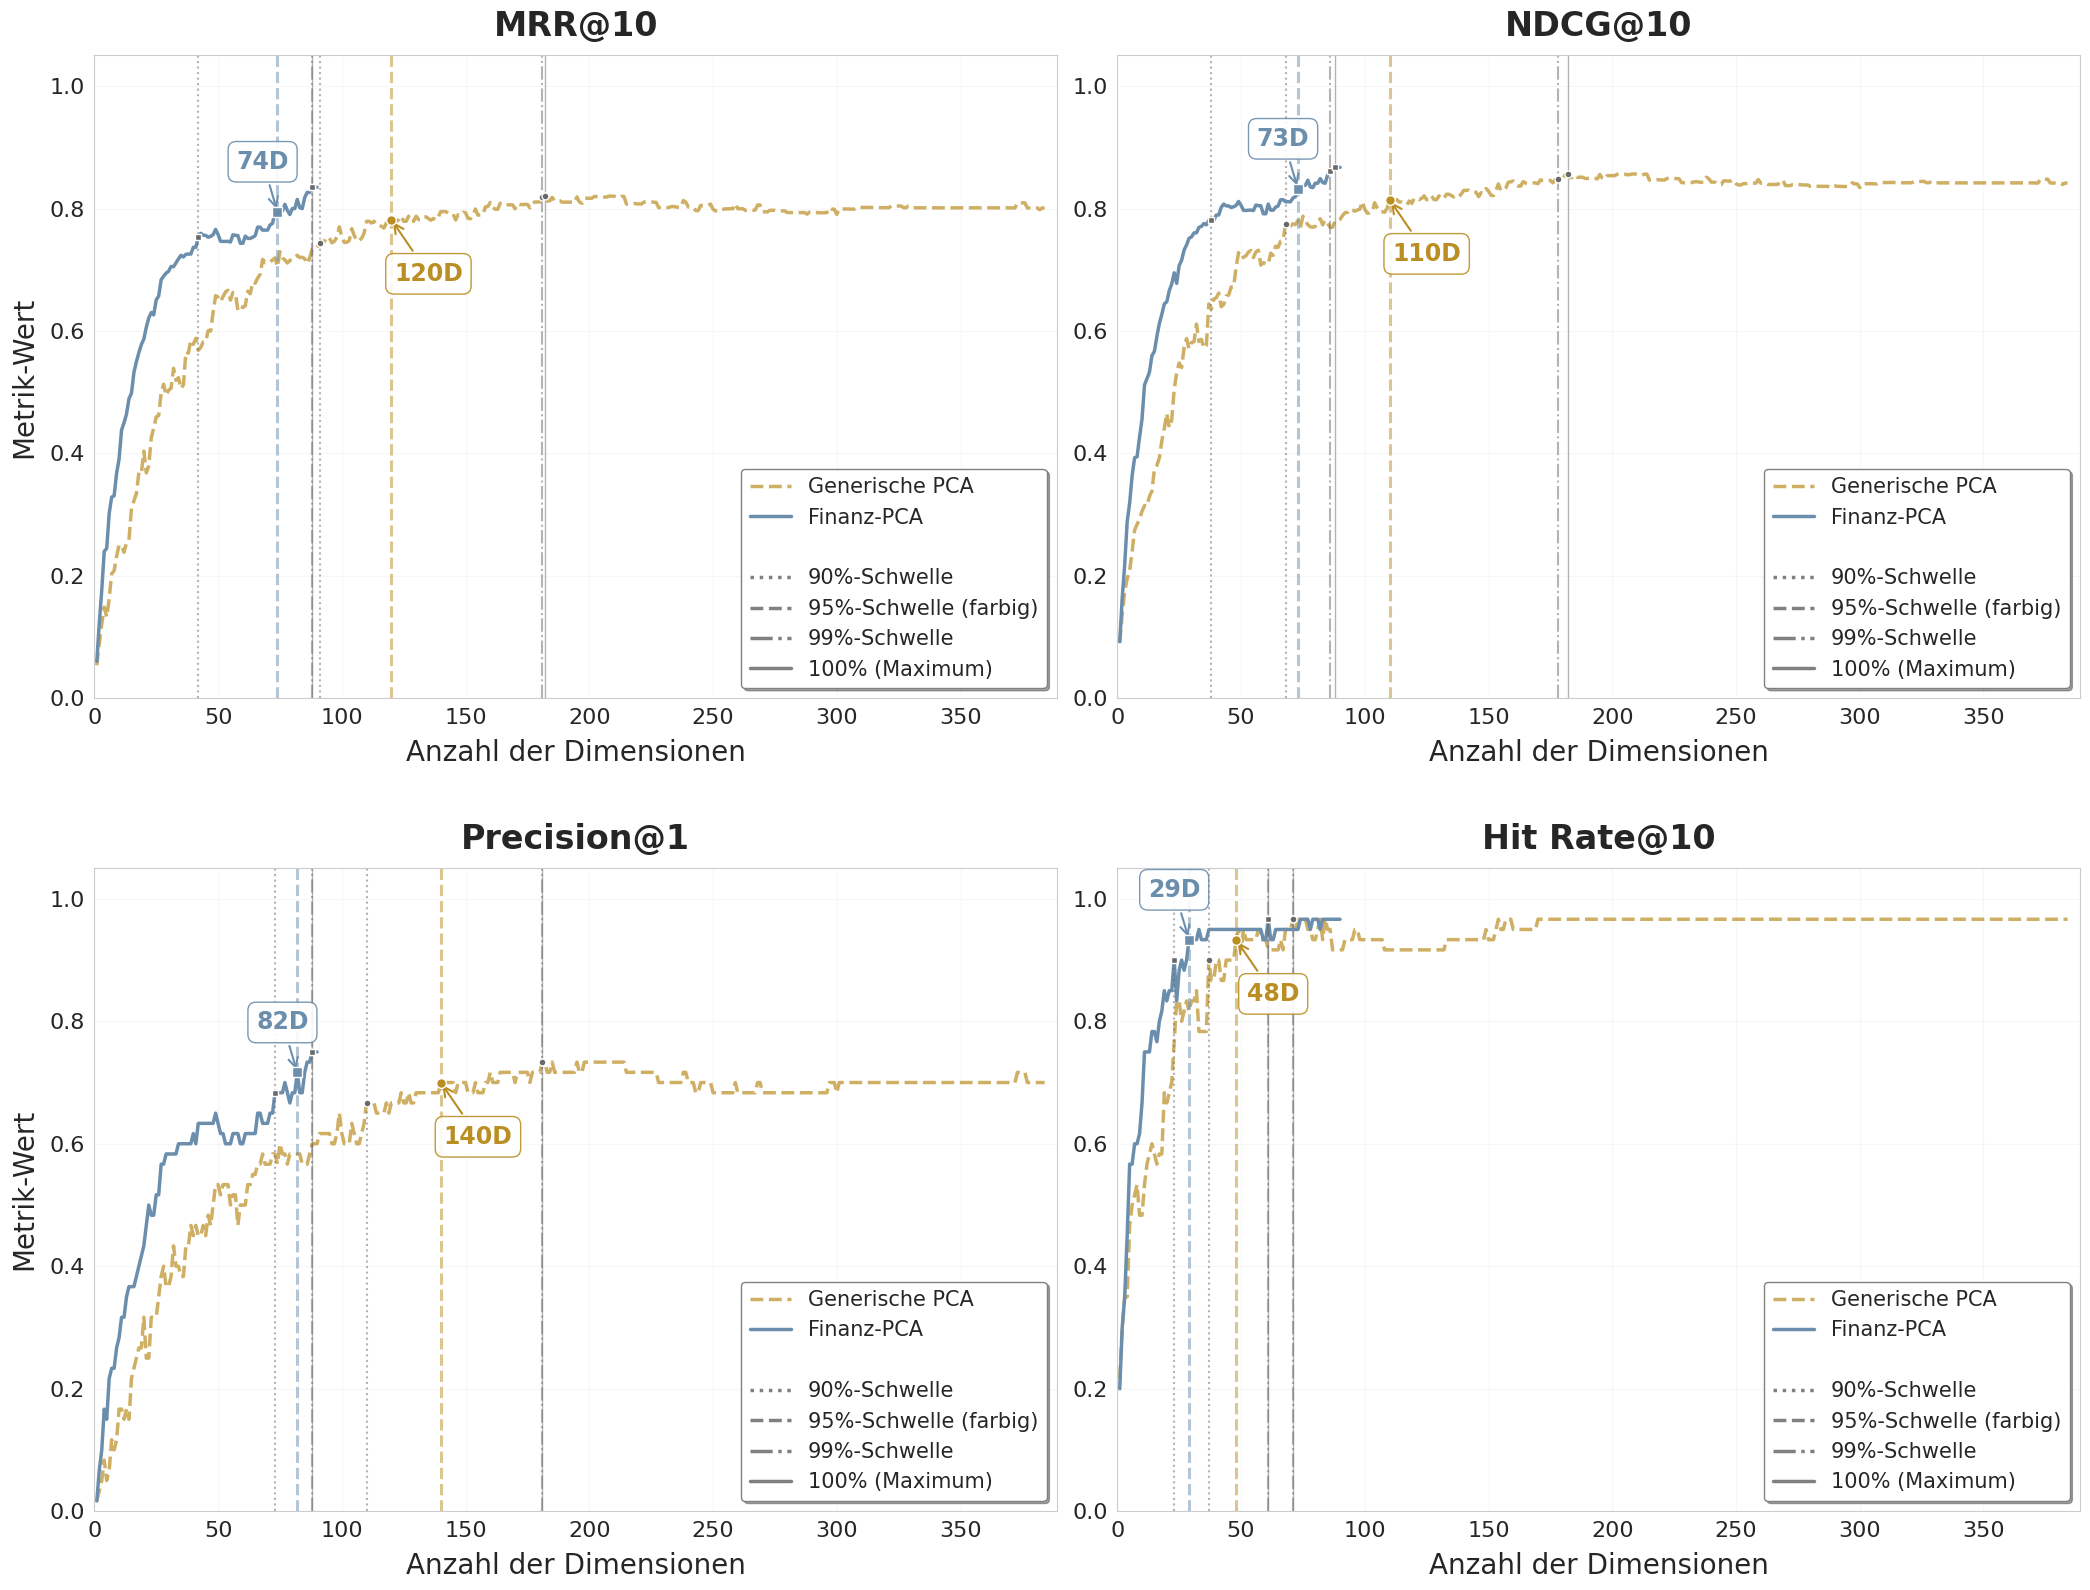

In [436]:
sns.set_style("whitegrid")

DOMAIN_COLORS = {
    'Medizin': '#66c2a5',
    'Recht': '#B19CD9',
    'Finanz': '#6B8EAD'
}

GEN_COLOR = '#BA8E23' 

for dom in DOMAINS:
    name = dom["name"]
    
    domain_color = DOMAIN_COLORS.get(name, '#333333') 
    
    fig, axes = plt.subplots(2, 2, figsize=(21, 16))
    axes = axes.flatten() 
    
    for idx, metric in enumerate(SELECTED_METRICS):
        ax = axes[idx]
        
        d_gen  = all_results[name][metric]['d_gen']
        v_gen  = all_results[name][metric]['v_gen']
        d_spec = all_results[name][metric]['d_spec']
        v_spec = all_results[name][metric]['v_spec']
        
        # Generische Kurve & Schwellen 
        if len(d_gen) > 0:
            ax.plot(d_gen, v_gen, linestyle='--', color=GEN_COLOR, linewidth=2.5, alpha=0.7, label="Generische PCA")
            
            for t in THRESHOLDS:
                e_gen = find_threshold_elbow(d_gen, v_gen, t)
                if e_gen and e_gen in d_gen:
                    val = v_gen[d_gen == e_gen][0]
                    
                    line_color = GEN_COLOR if t == 0.95 else 'dimgray'
                    
                    ax.axvline(x=e_gen, color=line_color, linestyle=THRESH_LS[t], alpha=0.5, linewidth=THRESH_LW[t])
                    ax.plot(e_gen, val, marker='o', color=line_color, markersize=MARKER_SZ[t], markeredgecolor='white', zorder=5)
                    
                    if t == 0.95:
                        ax.annotate(f'{e_gen}D', xy=(e_gen, val), 
                                    xytext=(e_gen + 15, val - 0.10), 
                                    fontsize=17, fontweight='bold', color=GEN_COLOR,
                                    ha='center',
                                    arrowprops=dict(arrowstyle='->', color=GEN_COLOR, lw=1.5),
                                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor=GEN_COLOR, alpha=0.9))
        
        # Spezifische Kurve & Schwellen
        if len(d_spec) > 0:
            ax.plot(d_spec, v_spec, linestyle='-', color=domain_color, linewidth=2.5, alpha=1.0, label=f"{name}-PCA")
            
            for t in THRESHOLDS:
                e_spec = find_threshold_elbow(d_spec, v_spec, t)
                if e_spec and e_spec in d_spec:
                    val = v_spec[d_spec == e_spec][0]
                    
                    line_color = domain_color if t == 0.95 else 'dimgray'
                    
                    ax.axvline(x=e_spec, color=line_color, linestyle=THRESH_LS[t], alpha=0.5, linewidth=THRESH_LW[t])
                    ax.plot(e_spec, val, marker='s', color=line_color, markersize=MARKER_SZ[t], markeredgecolor='white', zorder=5)
            
                    if t == 0.95:
                        # Sonderfall: Nur Medizin + Hit Rate
                        if name == 'Medizin' and metric == 'Hit Rate@10':
                            txt_offset = (e_spec + 1, val + 0.06)
                        else:
                            txt_offset = (e_spec - 6, val + 0.07)
                        
                        ax.annotate(f'{e_spec}D', xy=(e_spec, val), 
                                    xytext=txt_offset, 
                                    fontsize=17, fontweight='bold', color=domain_color,
                                    ha='center',
                                    arrowprops=dict(arrowstyle='->', color=domain_color, lw=1.5),
                                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor=domain_color, alpha=0.9))
    
        # Layout der einzelnen Kachel 
        ax.set_title(metric, fontsize=24, fontweight='bold', pad=14)
        ax.set_xlim(0, BASE_DIM + 5)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle='-', alpha=0.15) 
        
        # Erweiterte Legende pro Kachel
        handles, labels = ax.get_legend_handles_labels()
        handles.append(plt.Line2D([0], [0], color='none')); labels.append('')
        
        legend_items = [
            (':', '90%-Schwelle'), 
            ('--', '95%-Schwelle (farbig)'), 
            ('-.', '99%-Schwelle'),
            ('-', '100% (Maximum)')
        ]
        
        for ls, lbl in legend_items:
            handles.append(plt.Line2D([0], [0], color='gray', linestyle=ls, linewidth=2.5))
            labels.append(lbl)
            
        ax.legend(
            handles, 
            labels, 
            loc='lower right', 
            fontsize=15, 
            framealpha=1.0,    
            edgecolor='gray', 
            fancybox=True, 
            shadow=True,       
            frameon=True       
        )
        
        ax.tick_params(labelsize=16)
        ax.set_xlabel('Anzahl der Dimensionen', fontsize=20, labelpad=8)
        if idx % 2 == 0: 
            ax.set_ylabel('Metrik-Wert', fontsize=20, labelpad=8)
    
    # Speichern & Anzeigen
    plt.tight_layout(h_pad=4.0)
    filename = f"retrieval_matrix_all_thresholds_{name.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


### Latenz

#### Generische PCA

Im Folgenden wird die Suchlatenz untersucht, die sich aus der Anwendung der **generischen PCA** auf den **generischen Benchmark** ergibt.

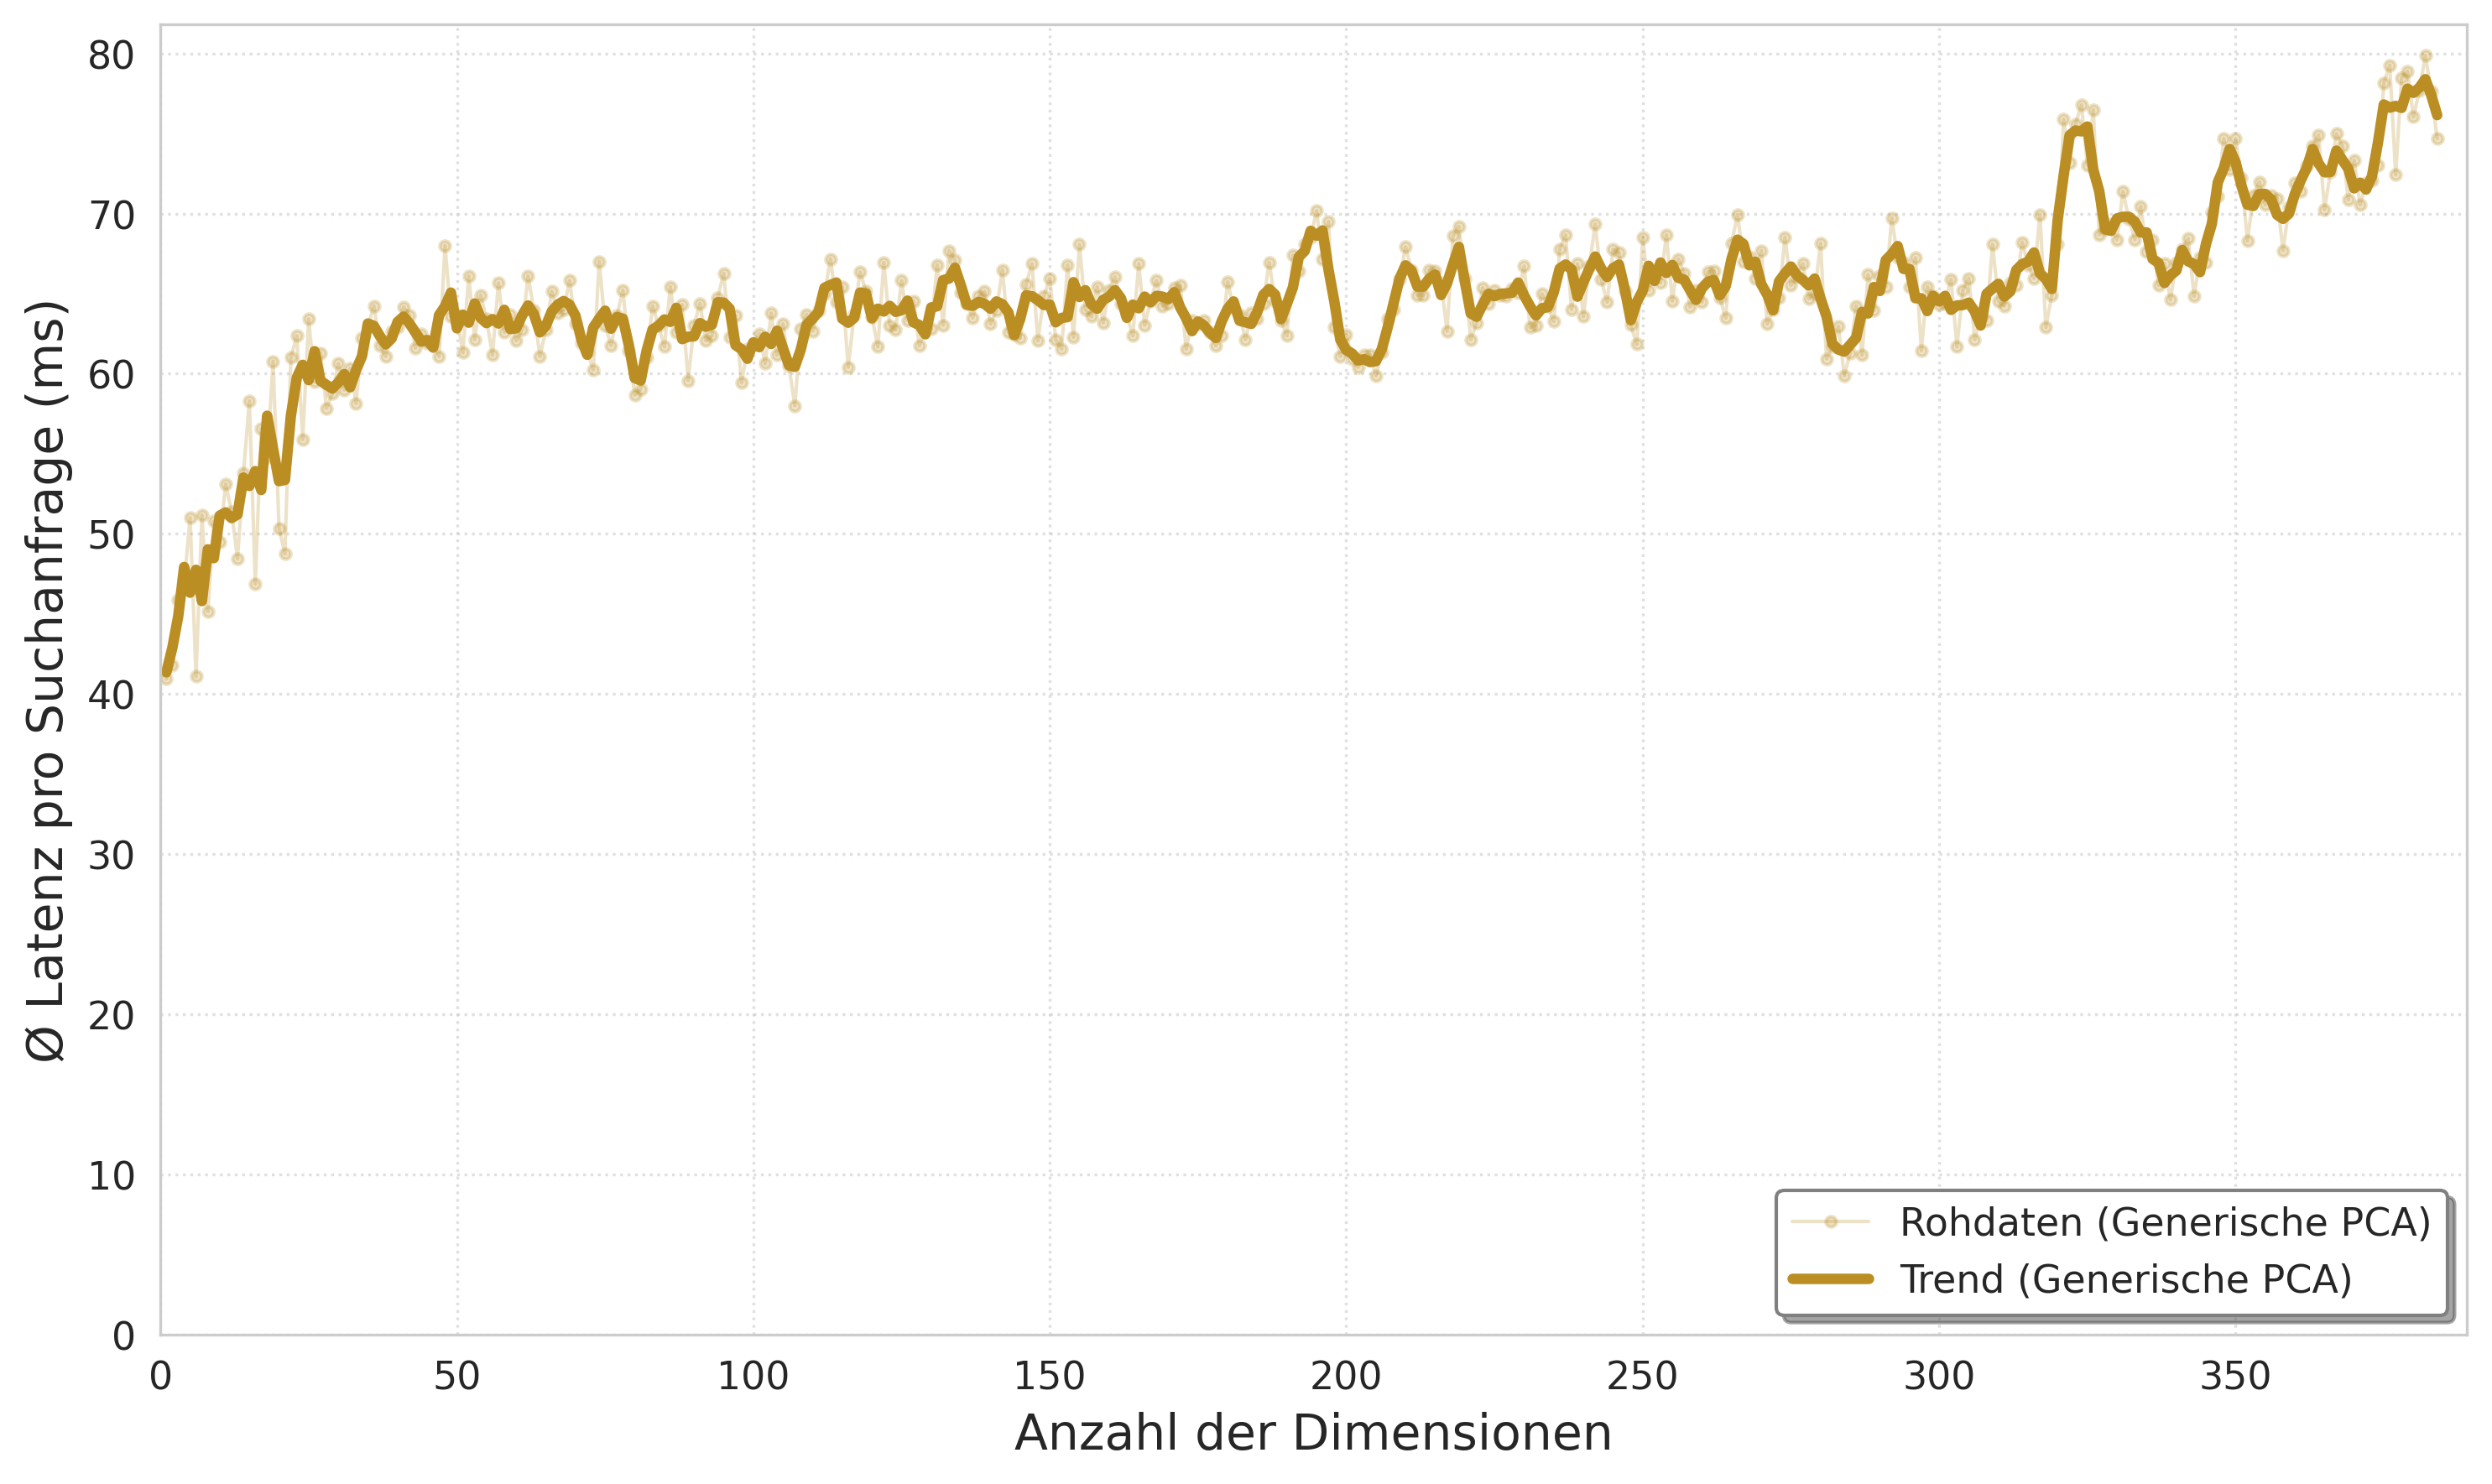

In [386]:
# Latenz extrahieren
dims_gen, vals_gen = extract_metric_curve(gen_metrics_gen, dims_list, 'Latenz (ms)')

if len(dims_gen) > 0:
    df_gen = pd.DataFrame({"Dimension": dims_gen, "Latenz": vals_gen})
    df_gen["Trend"] = df_gen["Latenz"].rolling(window=3, min_periods=1, center=True).mean()
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # Rohe Daten
    ax.plot(df_gen["Dimension"], df_gen["Latenz"], marker="o", markersize=3, 
            color=GEN_COLOR, alpha=0.25, linewidth=1, label="Rohdaten (Generische PCA)")
    
    # Geglätteter Trend
    ax.plot(df_gen["Dimension"], df_gen["Trend"], color=GEN_COLOR, linewidth=3, 
            label="Trend (Generische PCA)")
    
    ax.set_xlabel("Anzahl der Dimensionen", fontsize=14)
    ax.set_ylabel("Ø Latenz pro Suchanfrage (ms)", fontsize=14)
    ax.set_xlim(0, BASE_DIM + 5)
    ax.set_ylim(bottom=0) 
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.legend(fontsize=11, loc="lower right", framealpha=1.0, edgecolor='gray', 
              fancybox=True, shadow=True, frameon=True)
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    plt.savefig("plot_latenz_smooth_generic.png", dpi=300, bbox_inches='tight')
    plt.show()

#### Domänenspezifische PCA vs. generische PCA

Anschließend werden die gemessenen Latenzen zwischen der **domänenspezifischen PCA** und der **generischen PCA** gegenübergestellt, wobei beide auf die **domänenspezifischen Benchmarks** angewendet werden.

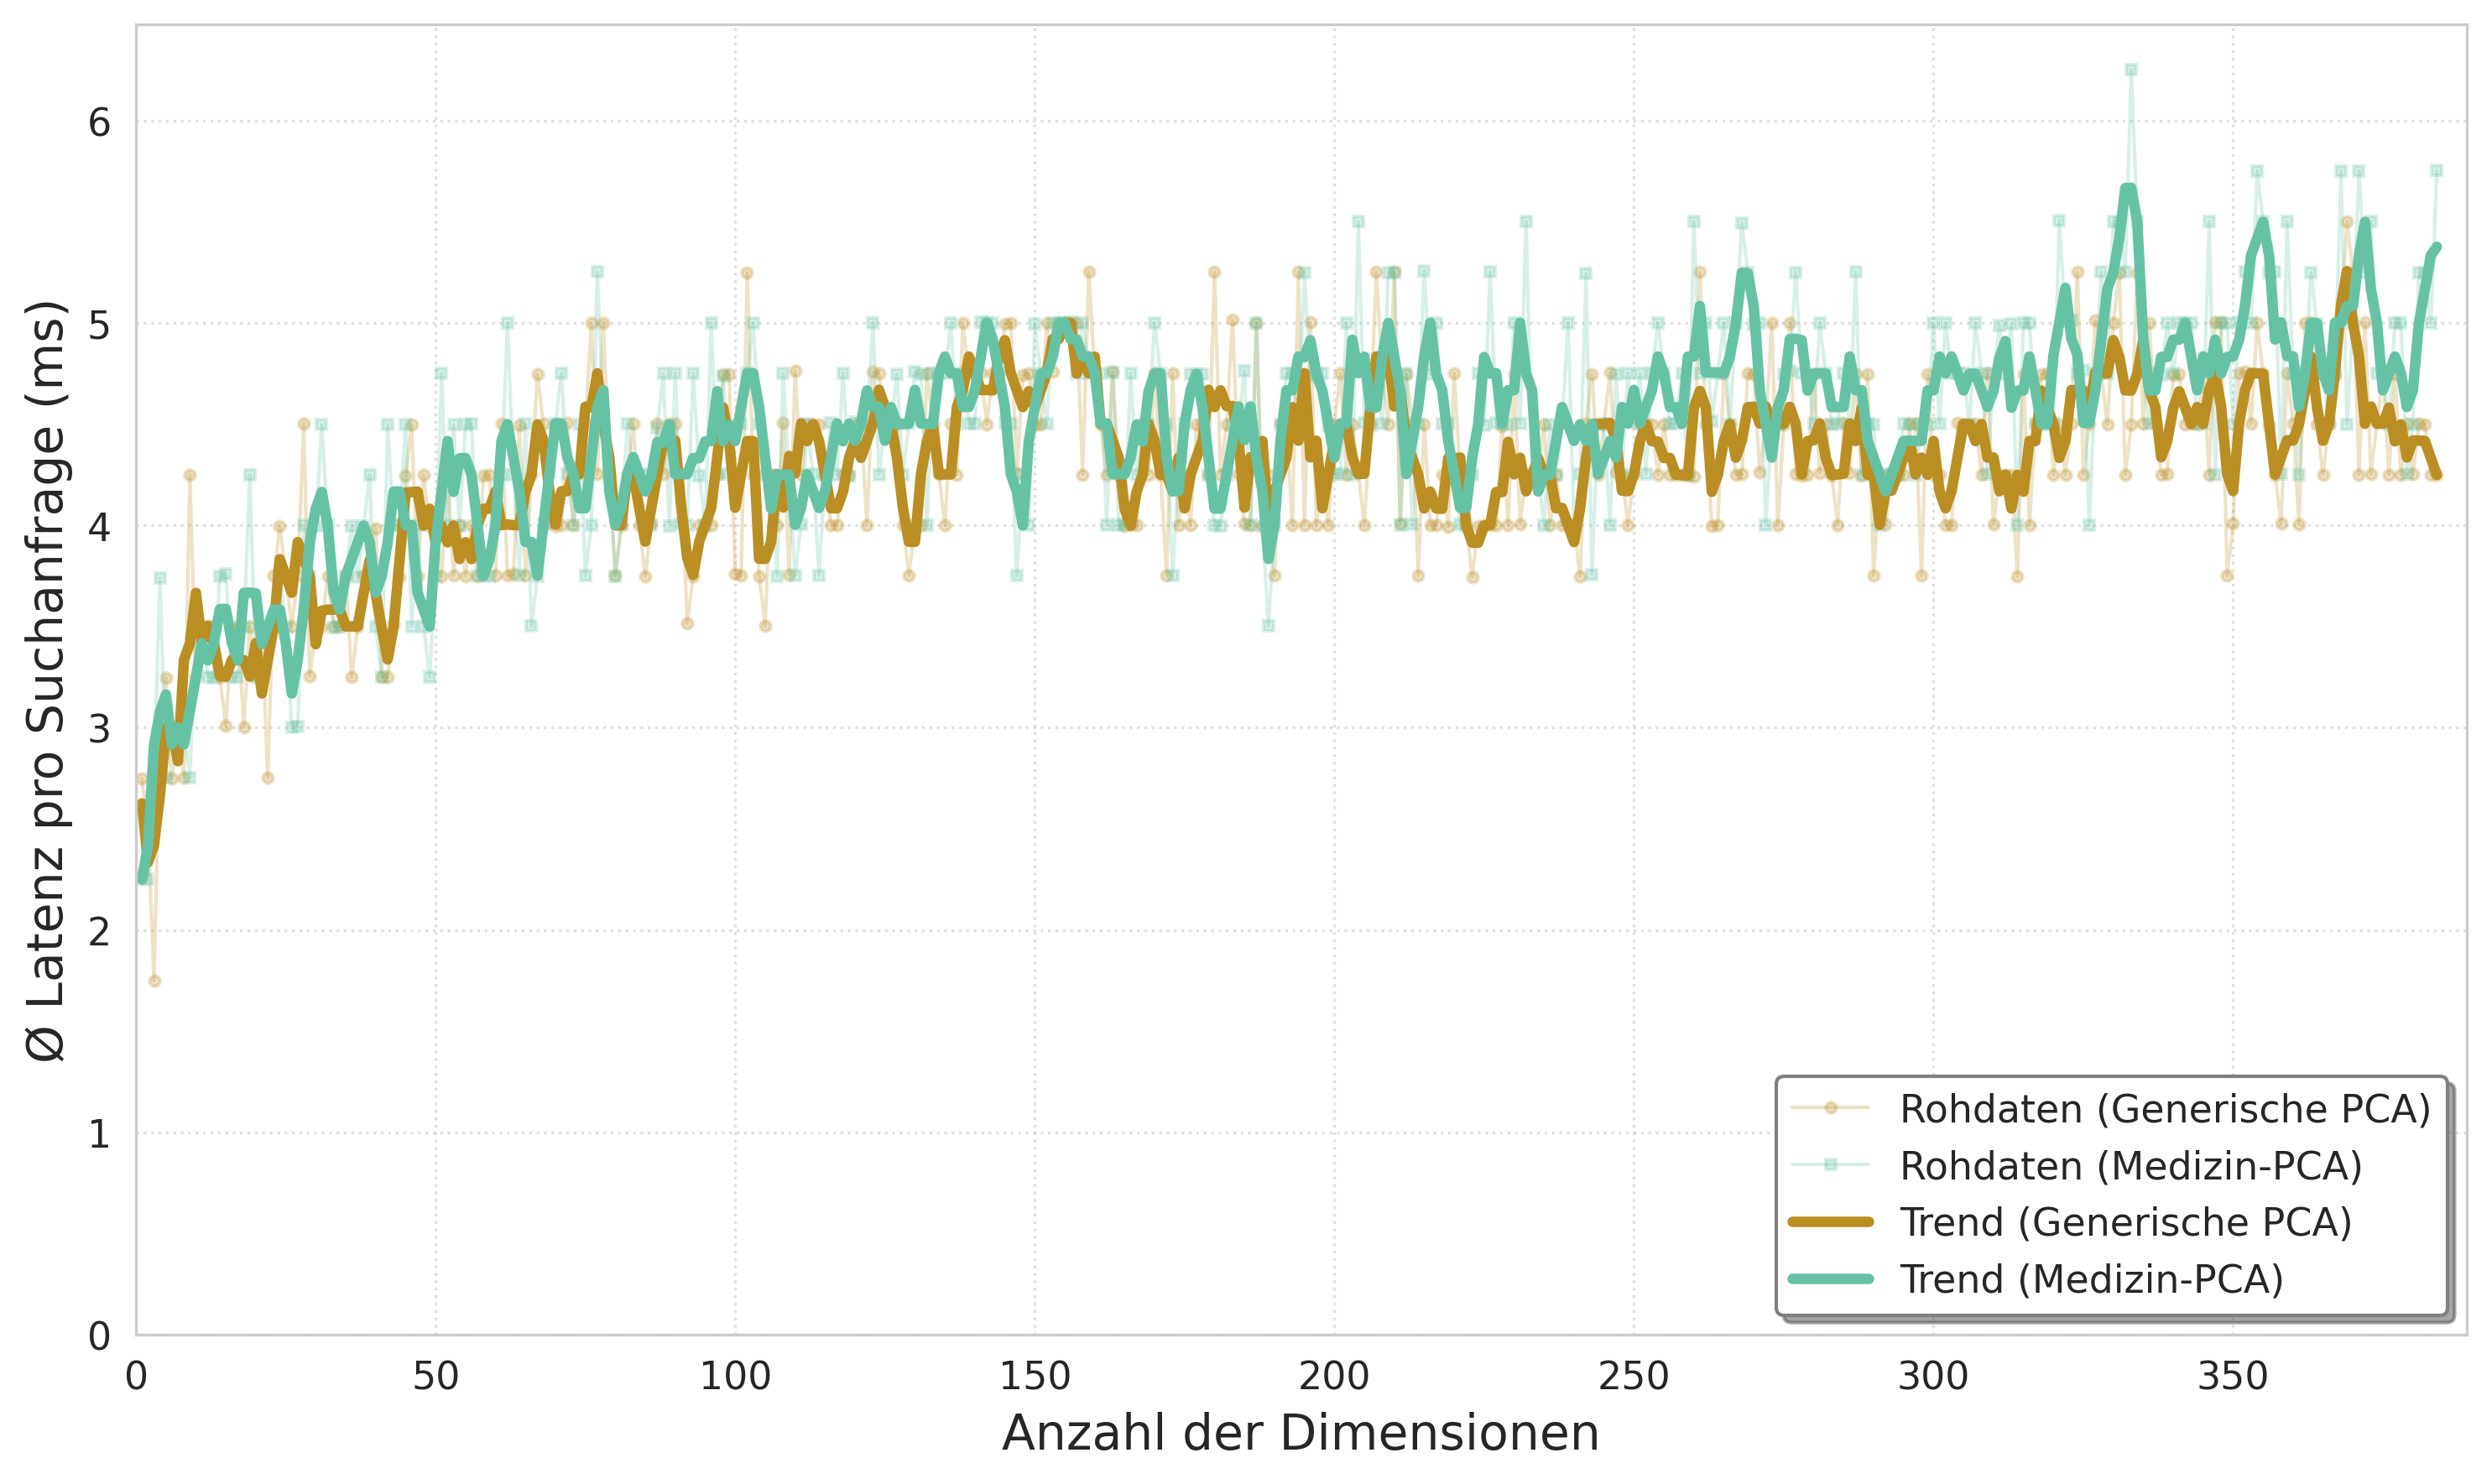

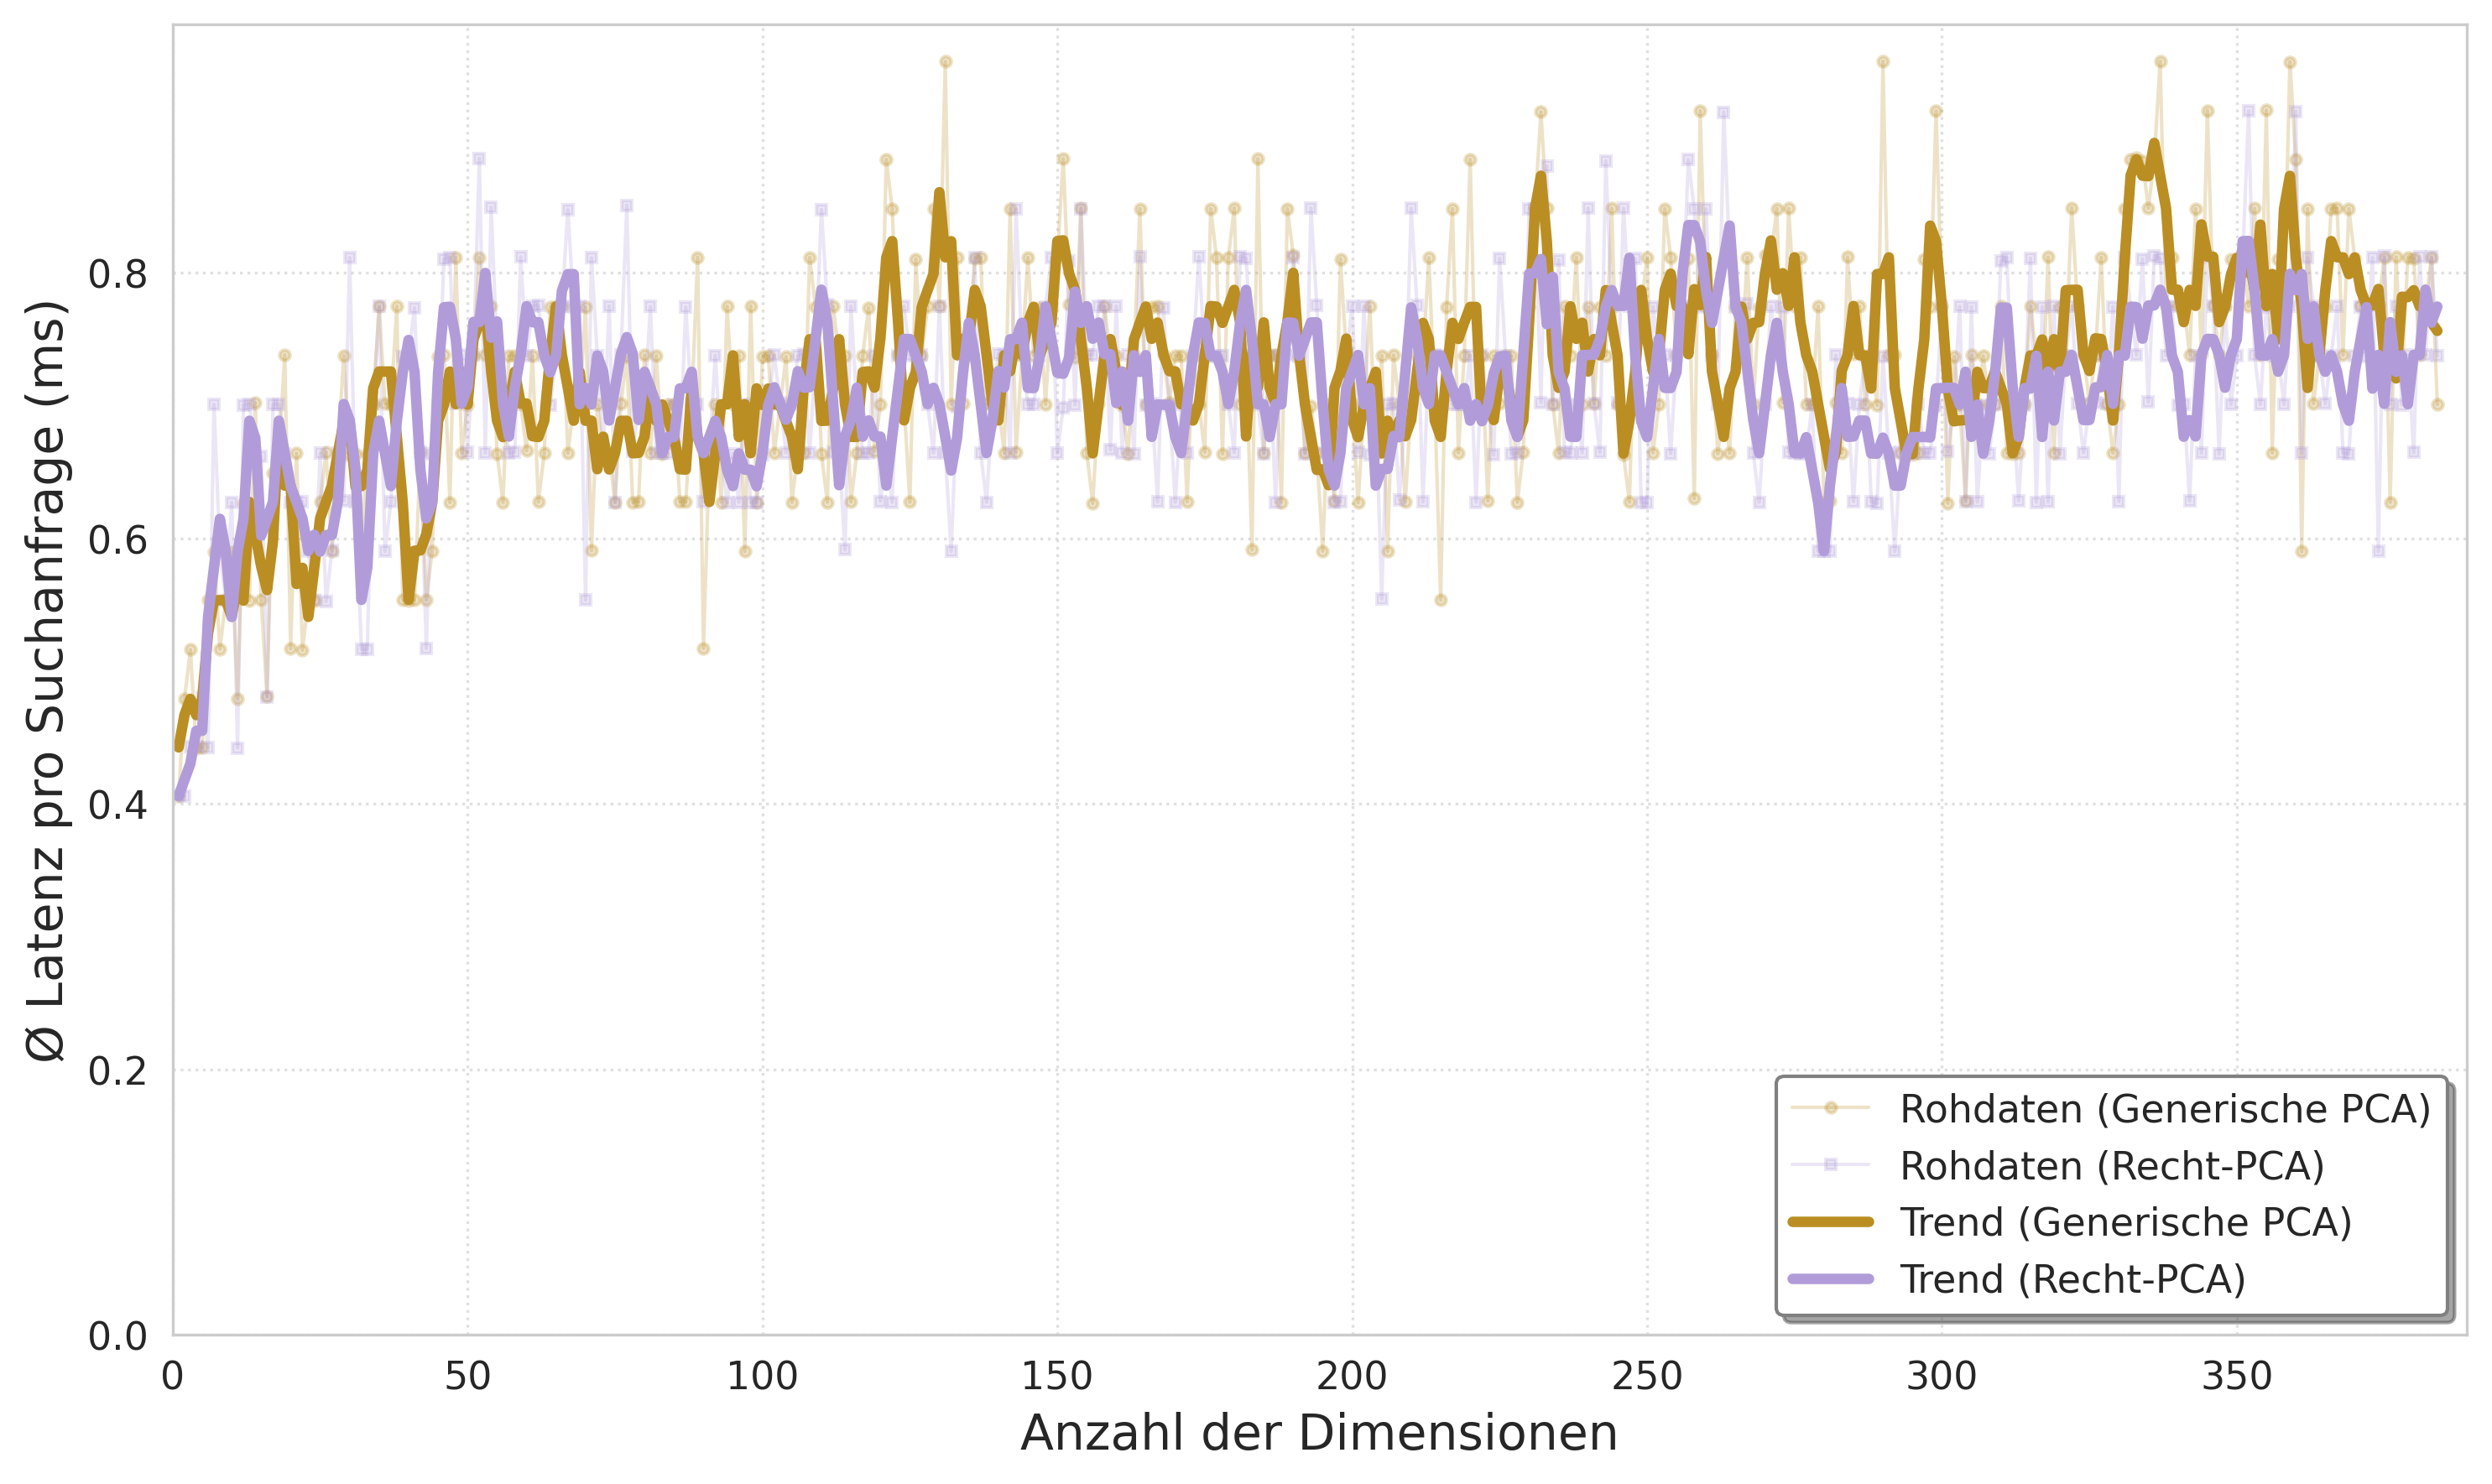

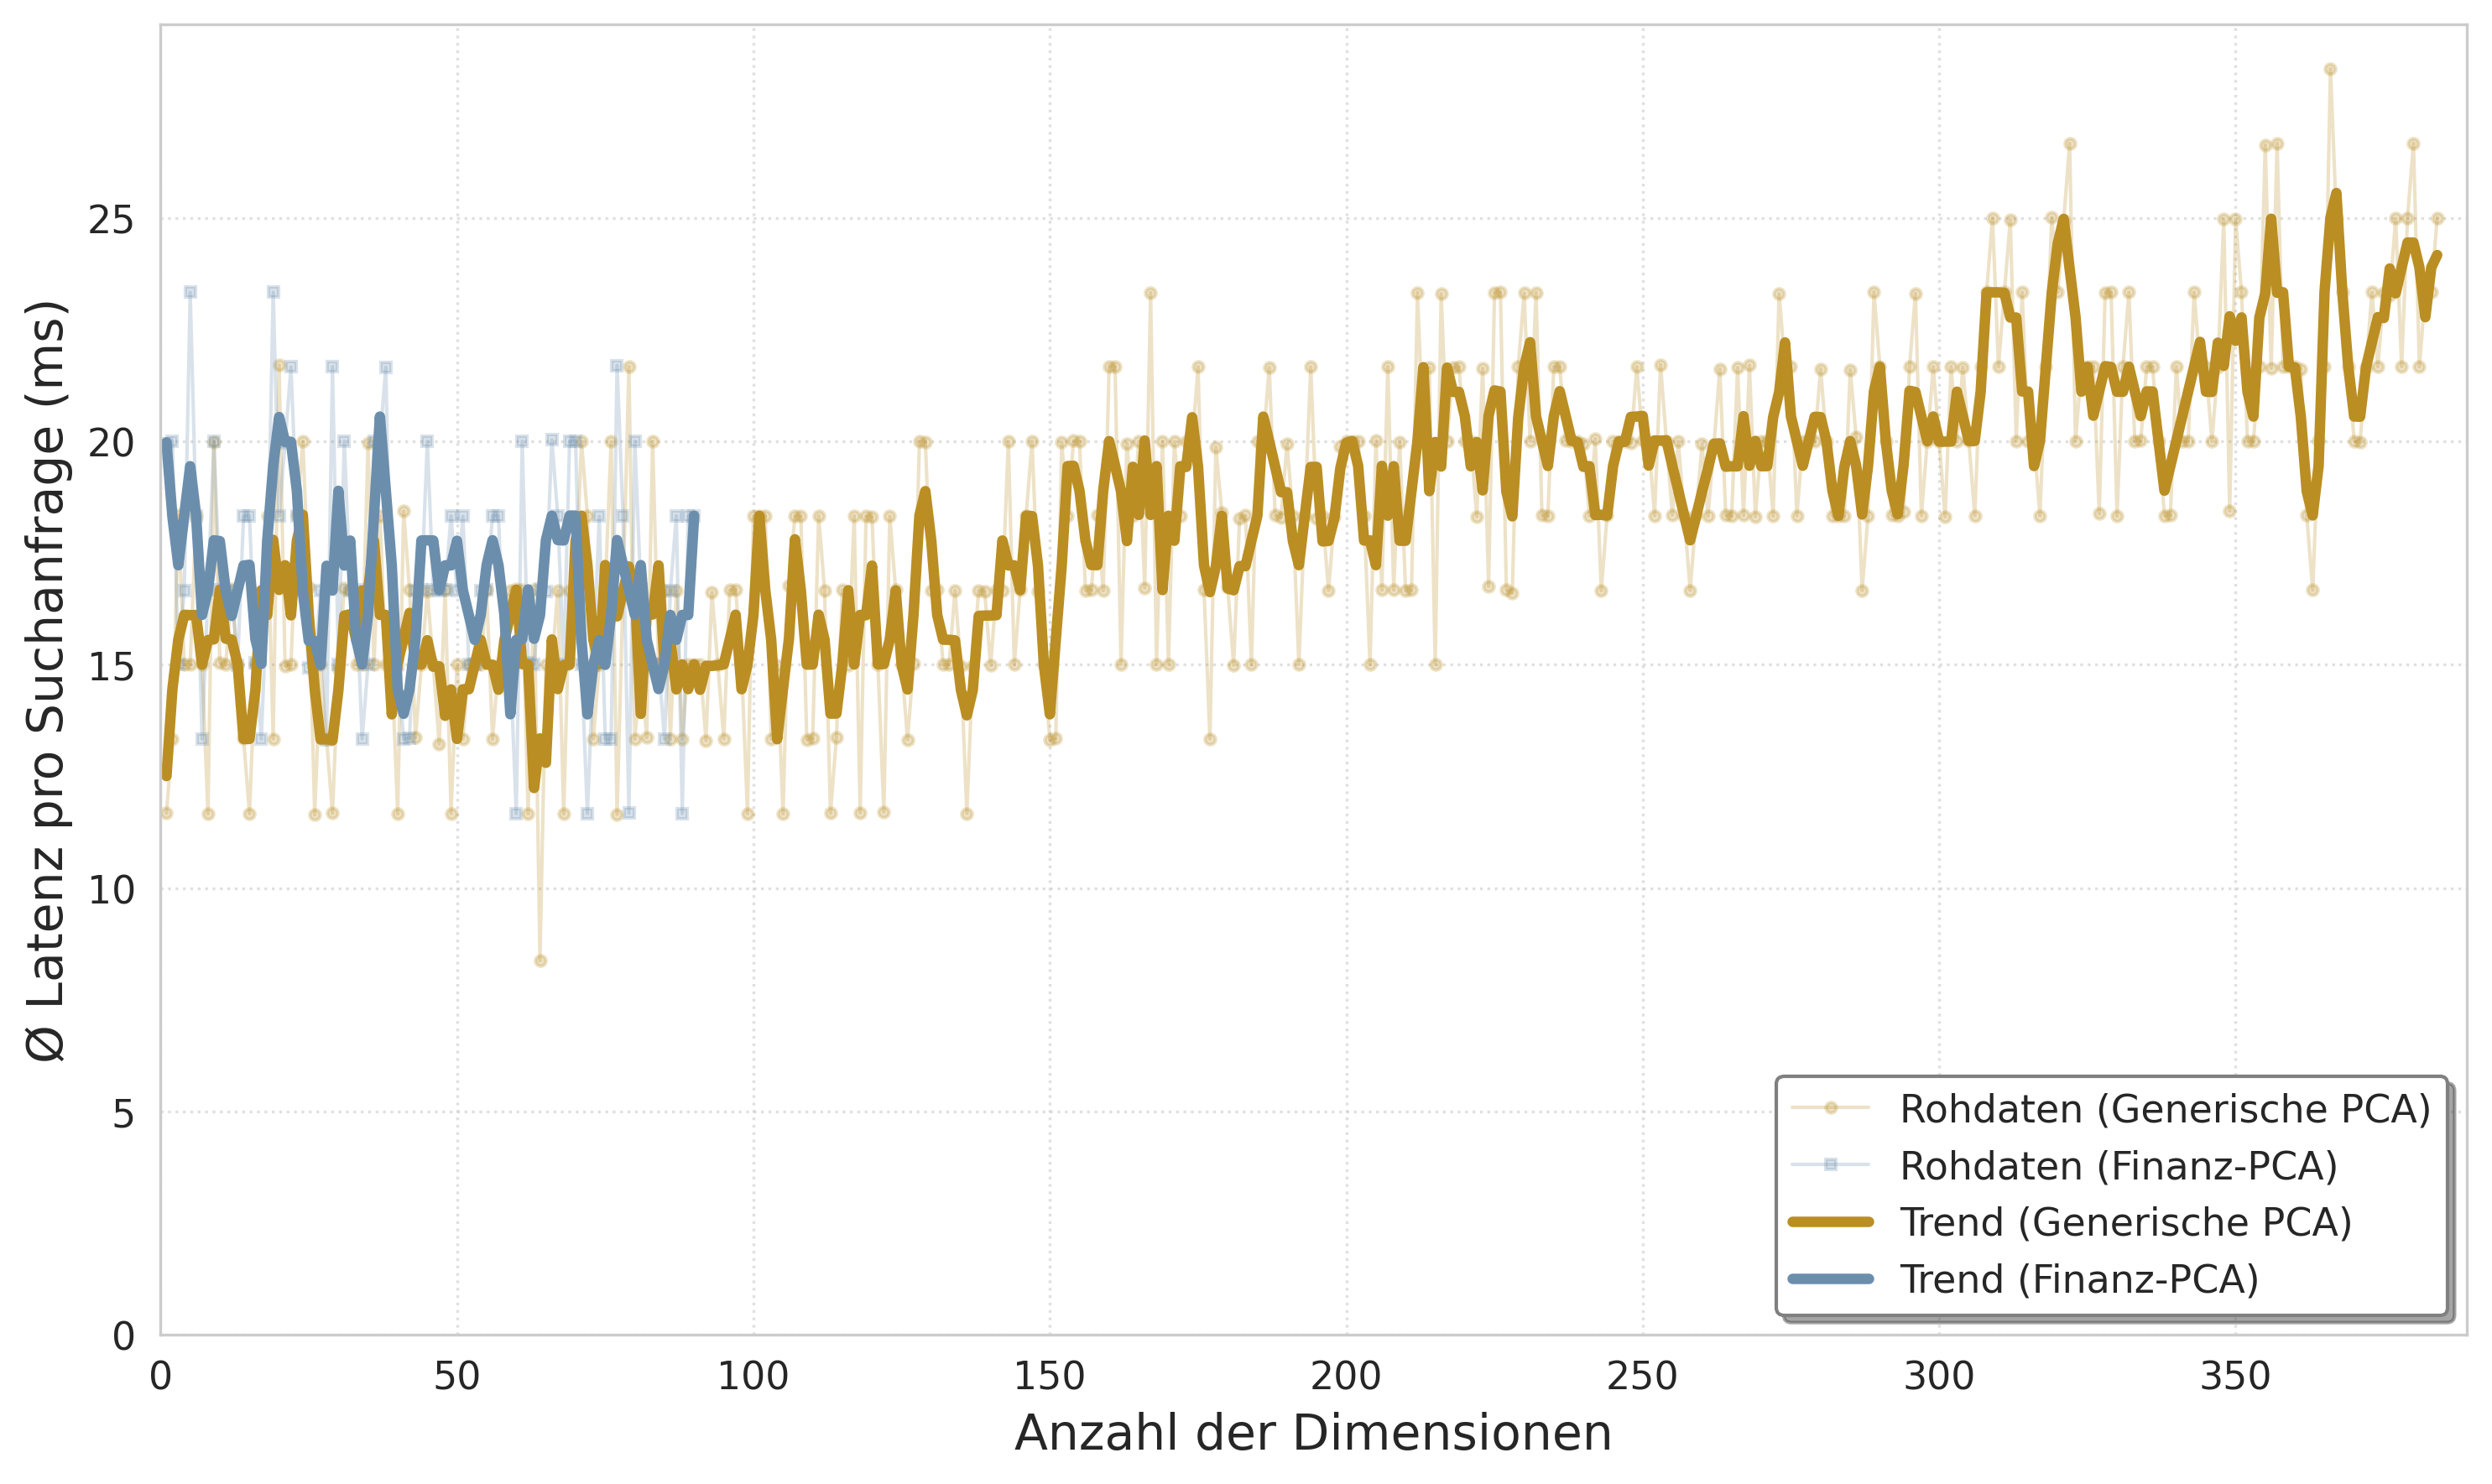

In [349]:
sns.set_style("whitegrid")

# Hilfsfunktion 
def extract_custom_metric(metrics_dict, dims_list, idx):
    dims, vals = [], []
    for d in dims_list:
        if d in metrics_dict:
            dims.append(d)
            vals.append(metrics_dict[d][idx])
    return np.array(dims), np.array(vals)

# Index für Latenz
IDX_LATENCY = 5

DOMAIN_COLORS = {
    'Medizin': '#66c2a5',
    'Recht': '#B19CD9',
    'Finanz': '#6B8EAD'
}

for dom in DOMAINS:
    name = dom["name"]
    
    # Daten extrahieren
    dims_gen, vals_gen = extract_custom_metric(dom["gen_metrics"], dims_list, IDX_LATENCY)
    dims_spec, vals_spec = extract_custom_metric(dom["spec_metrics"], dims_list, IDX_LATENCY)
    
    if len(dims_gen) == 0 or len(dims_spec) == 0:
        continue
        
    # In DataFrames umwandeln
    df_gen = pd.DataFrame({"Dimension": dims_gen, "Latenz": vals_gen})
    df_spec = pd.DataFrame({"Dimension": dims_spec, "Latenz": vals_spec})
    
    # Rolling Average
    df_gen["Trend"] = df_gen["Latenz"].rolling(window=3, min_periods=1, center=True).mean()
    df_spec["Trend"] = df_spec["Latenz"].rolling(window=3, min_periods=1, center=True).mean()
    
    c_gen = '#BA8E23'
    c_spec = DOMAIN_COLORS.get(name, '#333333')

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # Rohe Daten (blass im Hintergrund)
    ax.plot(df_gen["Dimension"], df_gen["Latenz"], marker="o", markersize=3, 
            color=c_gen, alpha=0.25, linewidth=1, label="Rohdaten (Generische PCA)")
    ax.plot(df_spec["Dimension"], df_spec["Latenz"], marker="s", markersize=3, 
            color=c_spec, alpha=0.25, linewidth=1, label=f"Rohdaten ({name}-PCA)")
    
    # Geglättete Trendlinien (dick im Vordergrund)
    ax.plot(df_gen["Dimension"], df_gen["Trend"], color=c_gen, linewidth=3, label="Trend (Generische PCA)")
    ax.plot(df_spec["Dimension"], df_spec["Trend"], color=c_spec, linewidth=3, label=f"Trend ({name}-PCA)")
    
    # Optik
    ax.set_xlabel("Anzahl der Dimensionen", fontsize=14)
    ax.set_ylabel("Ø Latenz pro Suchanfrage (ms)", fontsize=14)
    
    ax.set_xlim(0, BASE_DIM + 5)
    ax.set_ylim(bottom=0) 
    
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.legend(
        fontsize=11, 
        loc="lower right", 
        framealpha=1.0,   
        edgecolor='gray', 
        fancybox=True, 
        shadow=True,       
        frameon=True       
    )
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    filename = f"plot_latenz_smooth_{name.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

### Mittlerer Rang

#### Generische PCA

Im Folgenden wird der Mittlerer Rang untersucht, der sich aus der Anwendung der **generischen PCA** auf den **generischen Benchmark** ergibt.

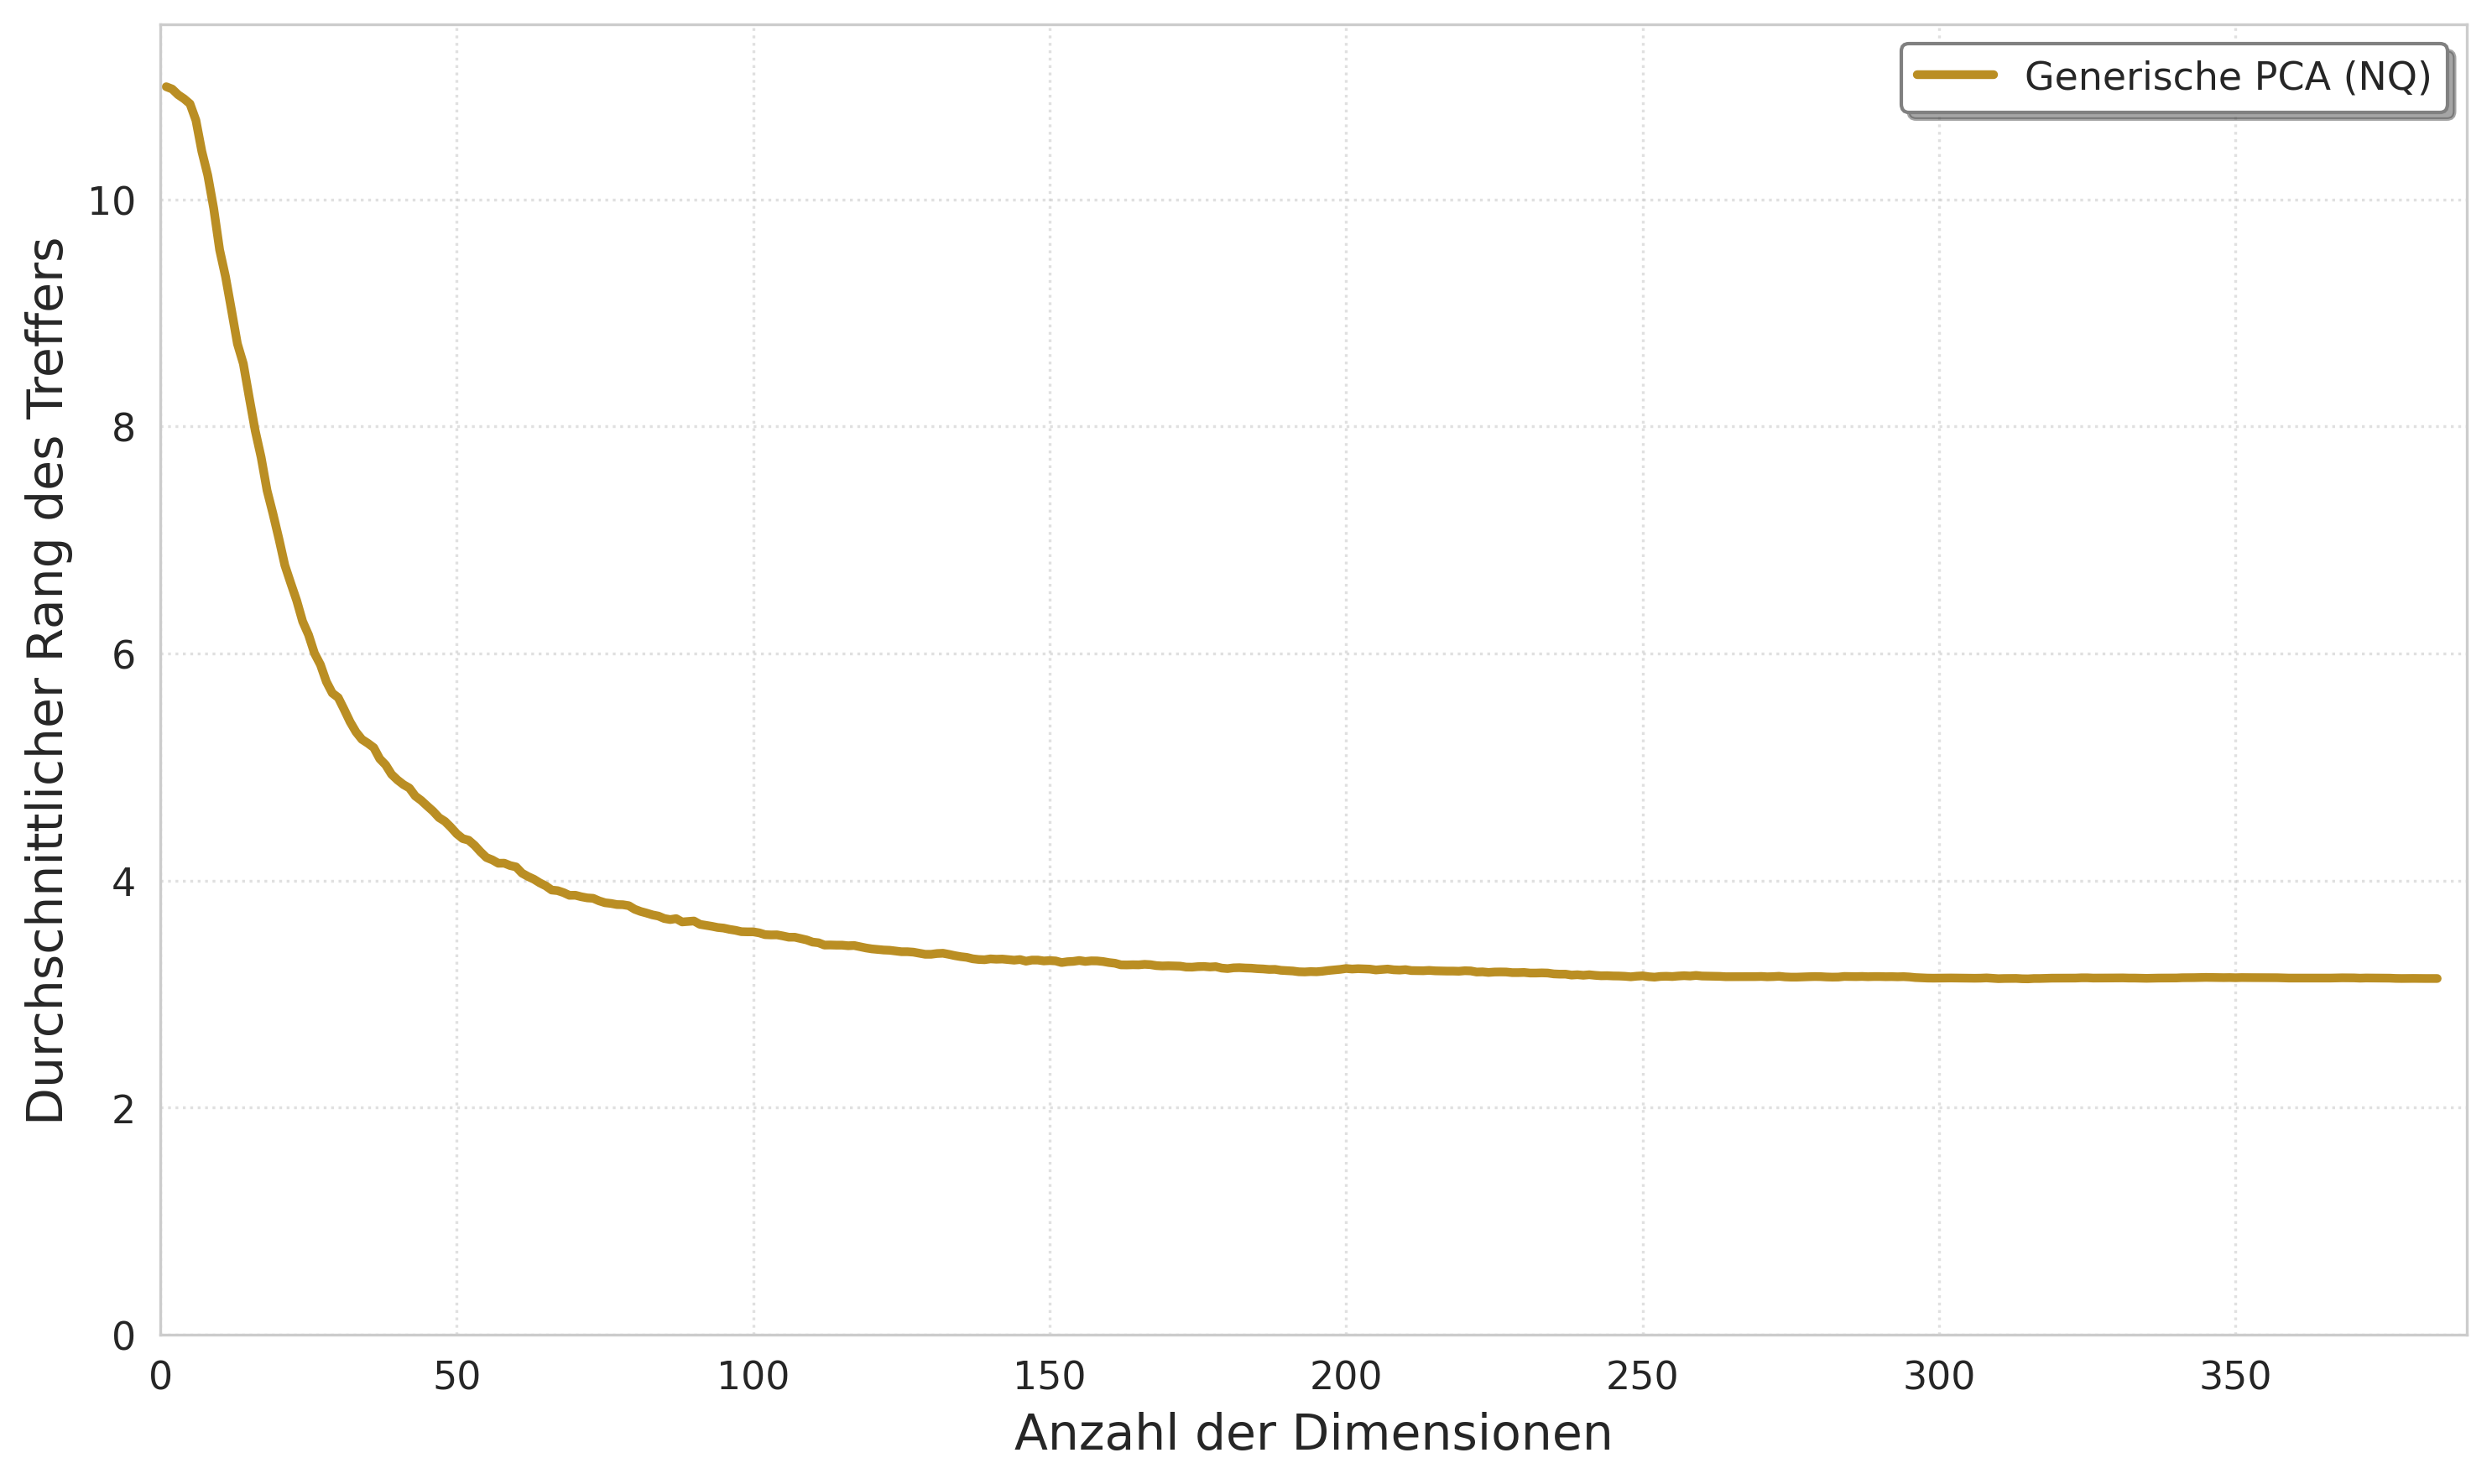

In [387]:
# Mean Rank extrahieren
dims_gen, vals_gen = extract_metric_curve(gen_metrics_gen, dims_list, 'Mean Rank')

if len(dims_gen) > 0:
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    ax.plot(dims_gen, vals_gen, color=GEN_COLOR, linewidth=2.5, label="Generische PCA (NQ)")
    
    ax.set_xlabel("Anzahl der Dimensionen", fontsize=14)
    ax.set_ylabel("Durchschnittlicher Rang des Treffers", fontsize=14)
    ax.set_xlim(0, BASE_DIM + 5)
    ax.set_ylim(0, vals_gen.max() * 1.05) 
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.legend(fontsize=11, loc="upper right", framealpha=1.0, edgecolor='gray', 
              fancybox=True, shadow=True, frameon=True)
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    plt.savefig("plot_meanrank_generic.png", dpi=300, bbox_inches='tight')
    plt.show()

#### Domänenspezifische PCA vs. generische PCA

Nachfolgend wird die Entwicklung des durchschnittlichen Rangs zwischen der **domänenspezifischen PCA** und der **generischen PCA** gegenübergestellt, wobei beide auf die **domänenspezifischen Benchmarks** angewendet werden.

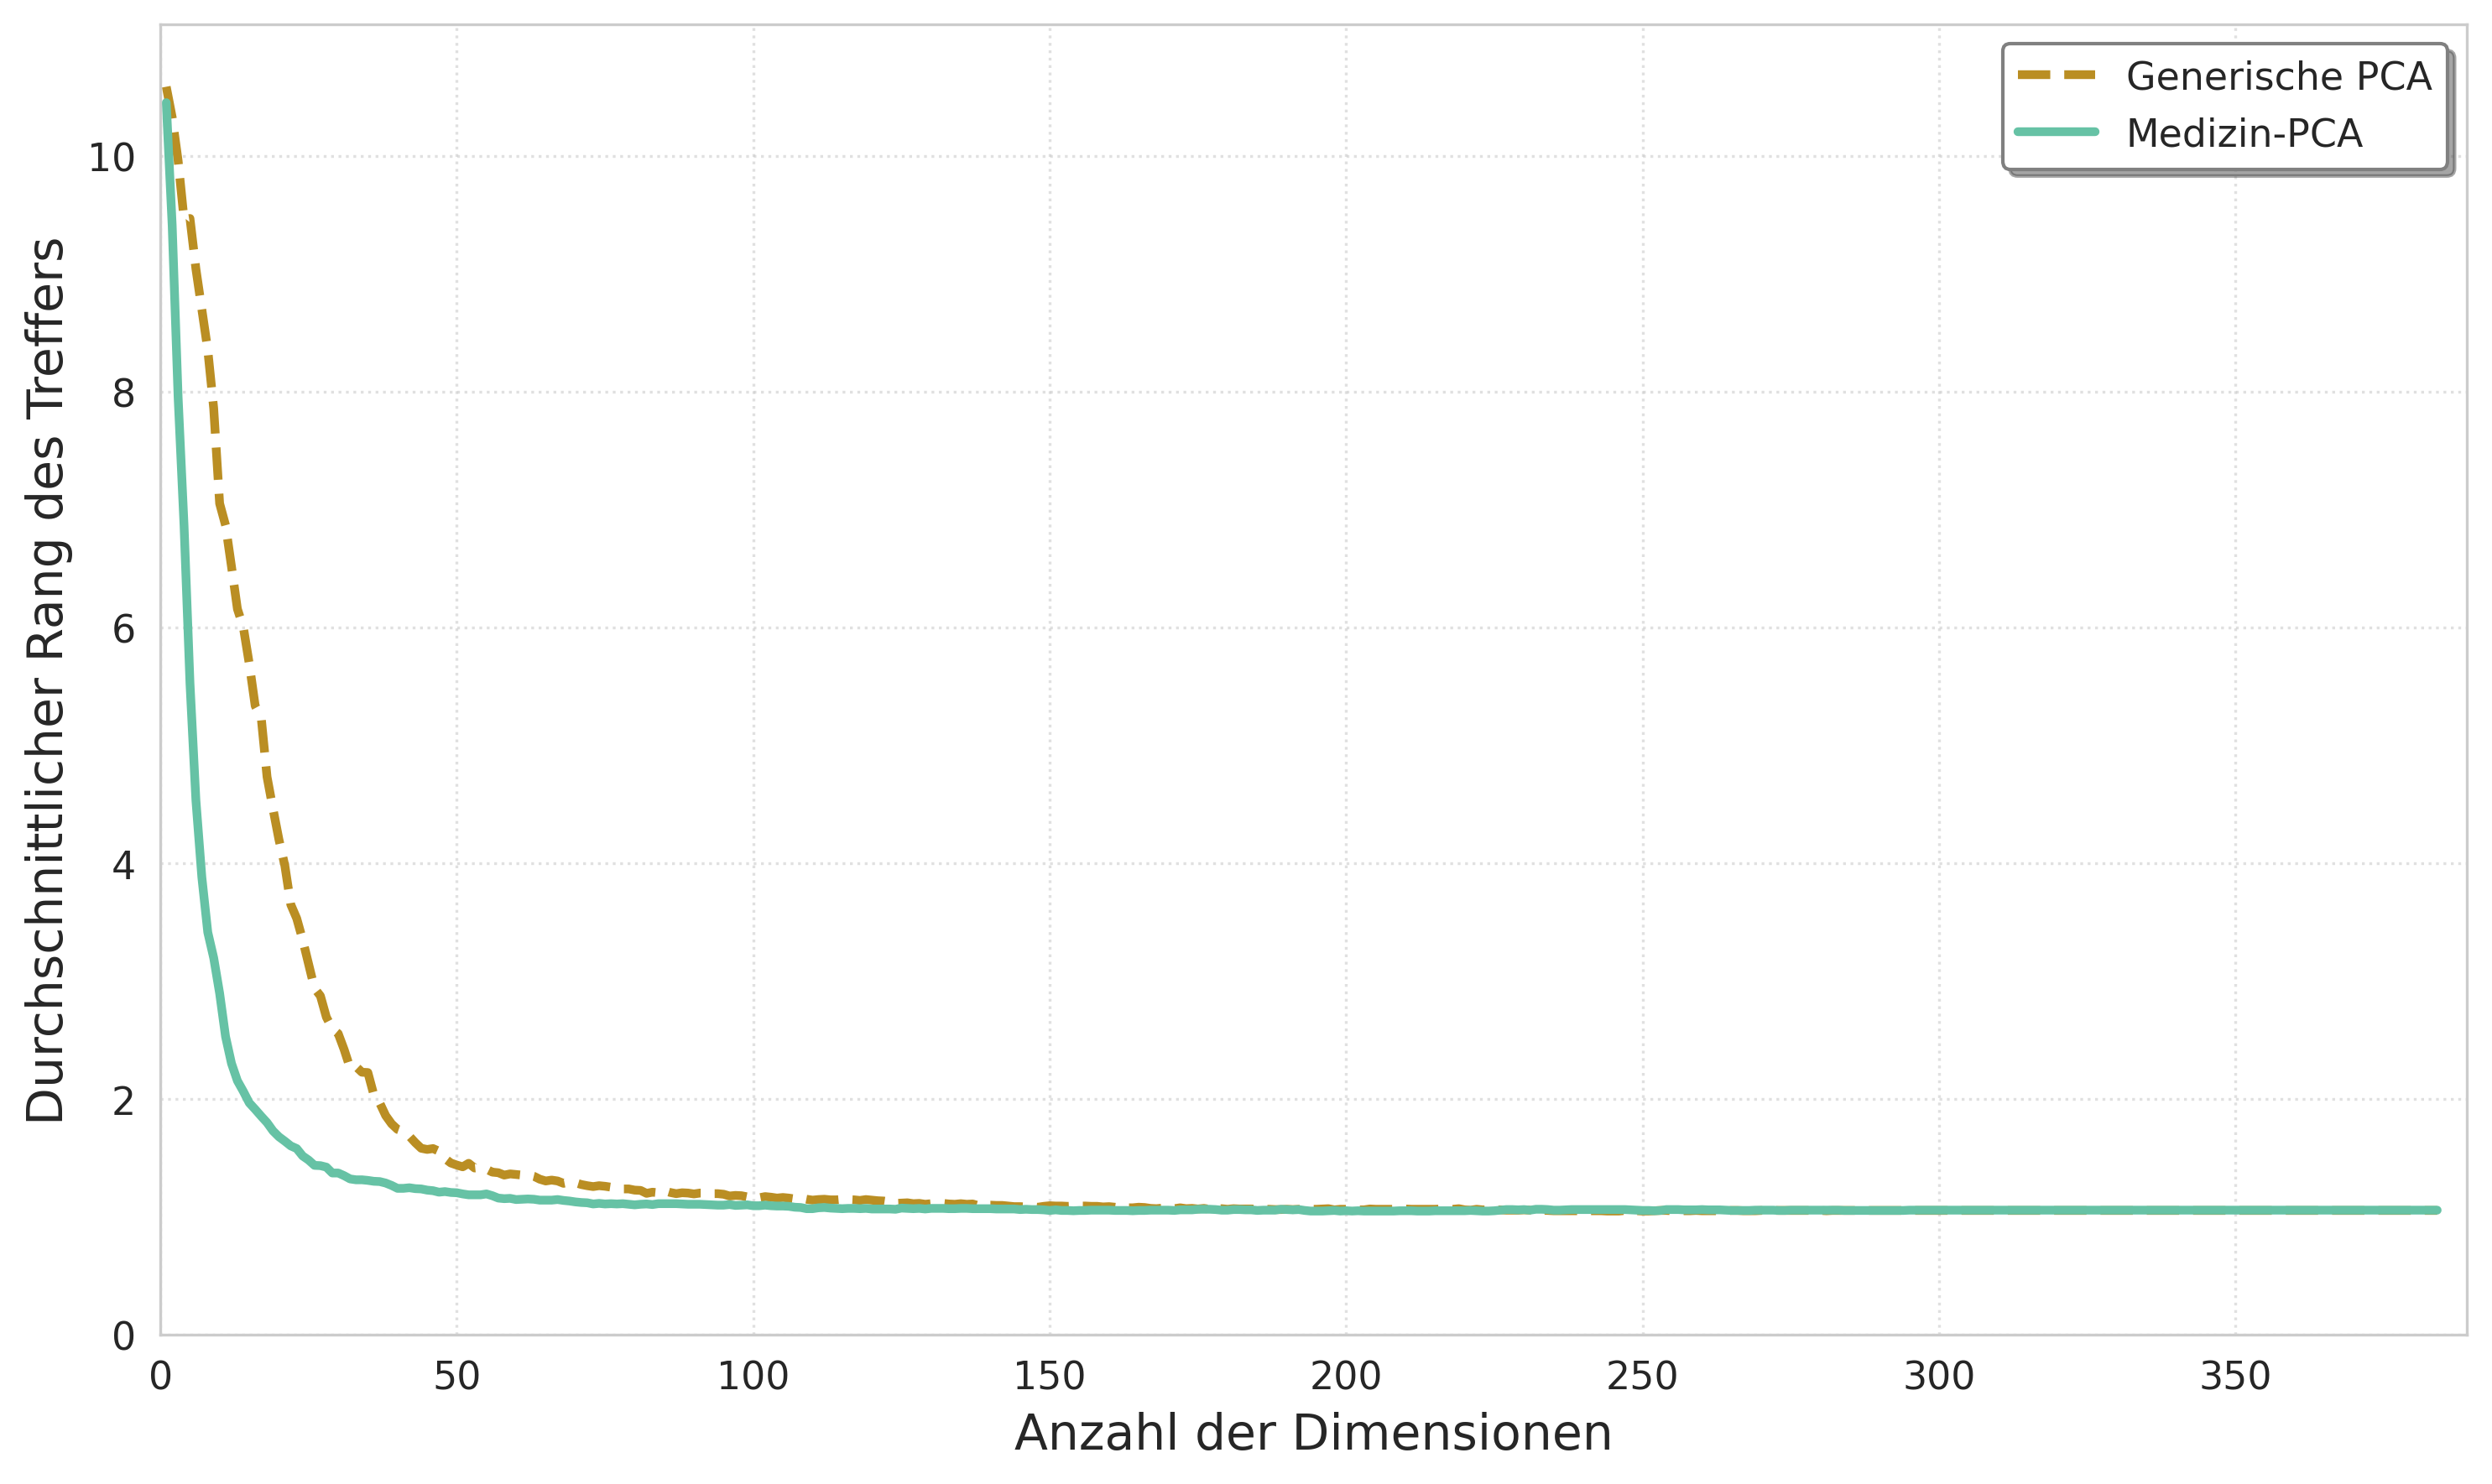

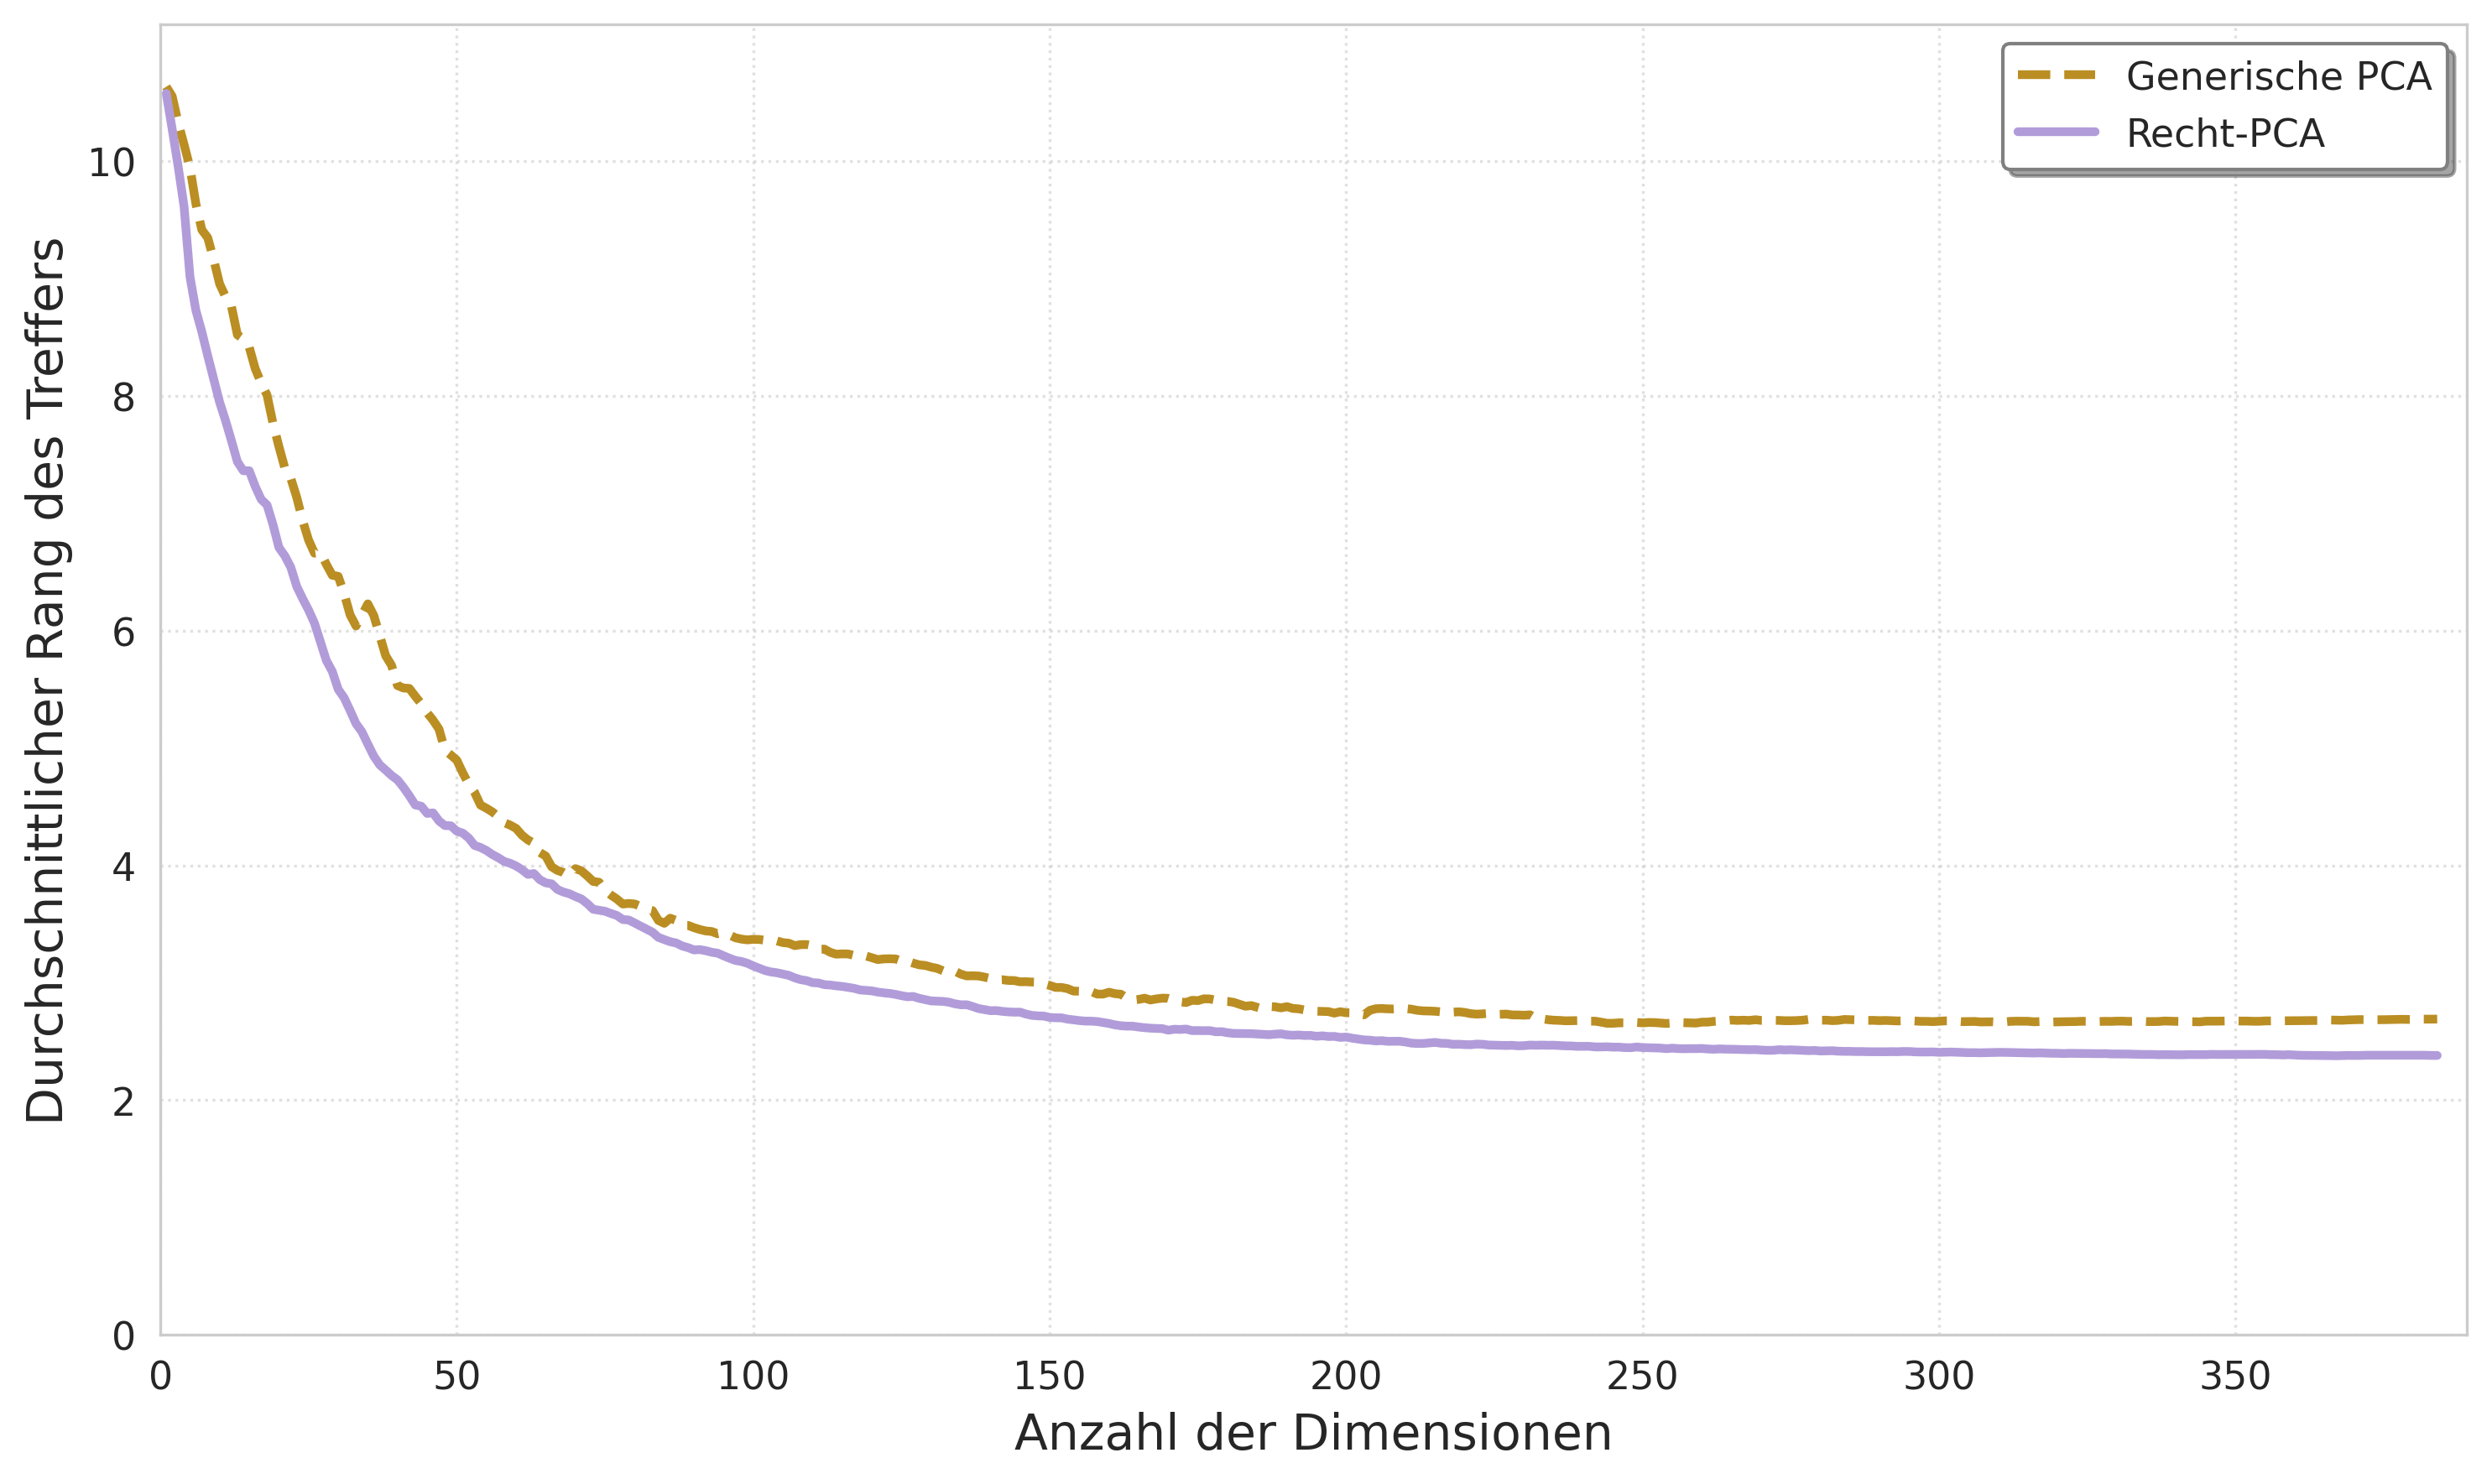

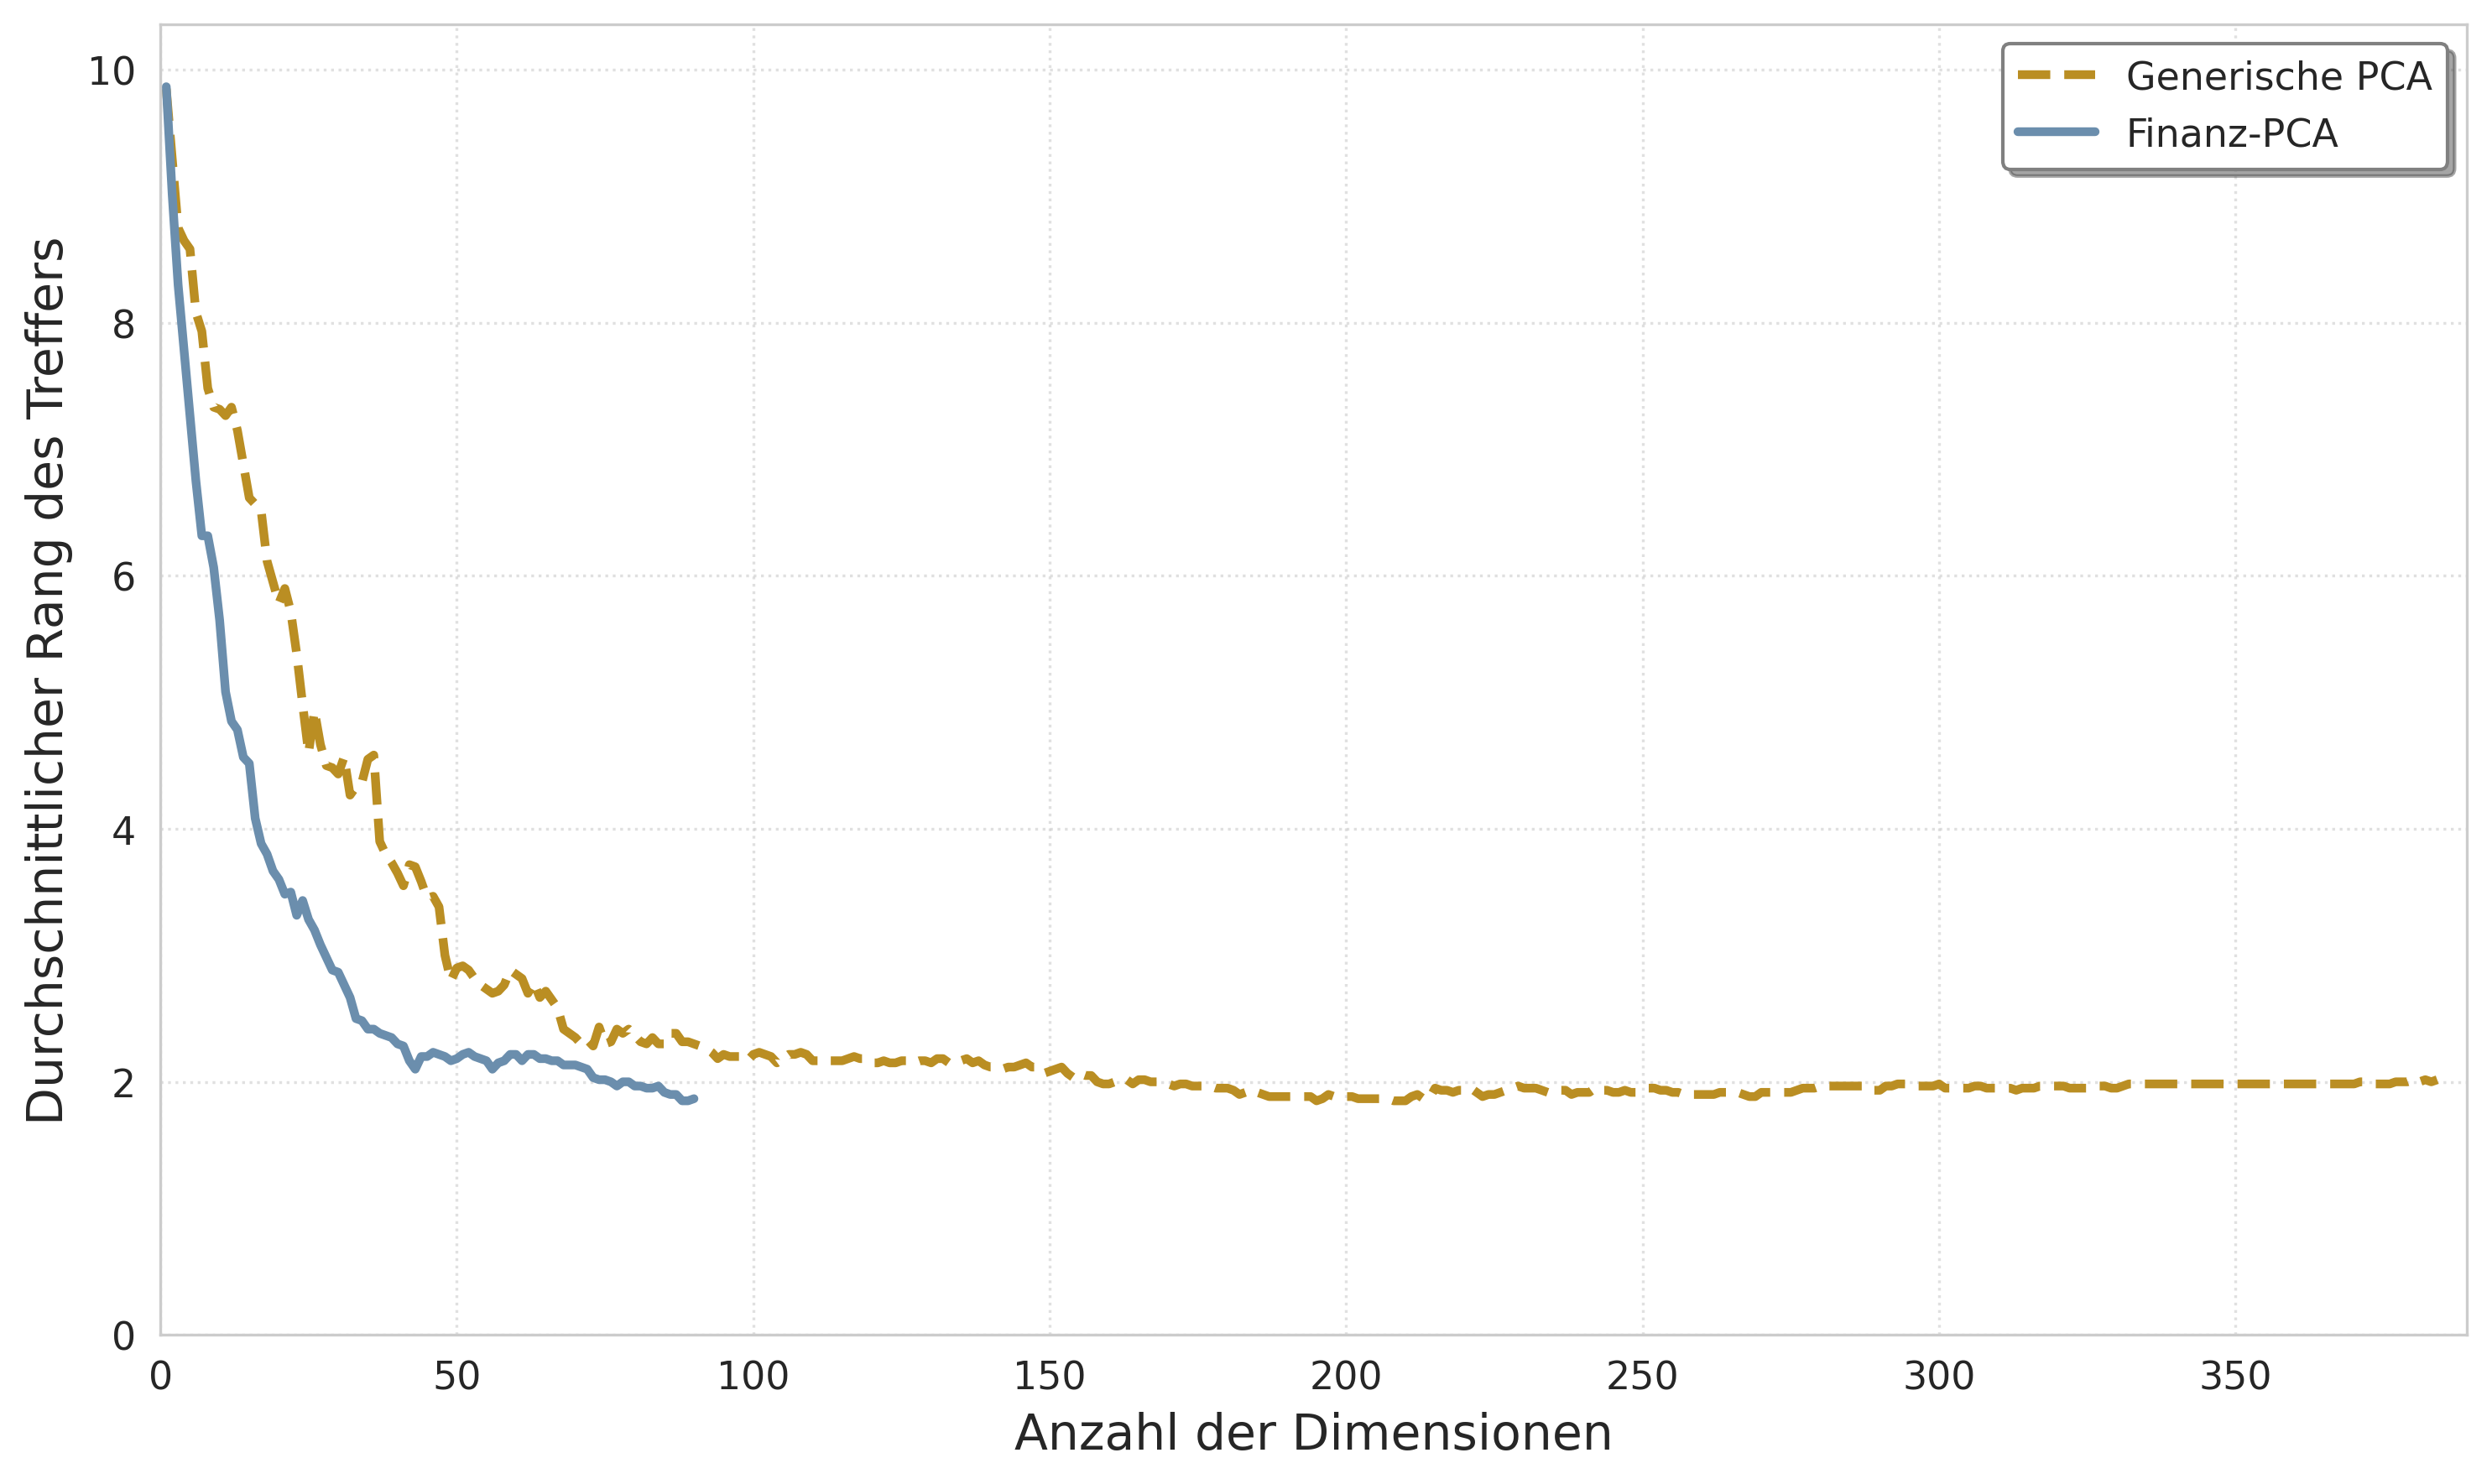

In [350]:
sns.set_style("whitegrid")

# Index für Mean Rank
IDX_MEAN_RANK = 4

# Konsistentes Farb-Dictionary für alle Domänen
DOMAIN_COLORS = {
    'Medizin': '#66c2a5',
    'Recht': '#B19CD9',
    'Finanz': '#6B8EAD'
}

for dom in DOMAINS:
    name = dom["name"]
    
    # Daten extrahieren
    dims_gen, vals_gen = extract_custom_metric(dom["gen_metrics"], dims_list, IDX_MEAN_RANK)
    dims_spec, vals_spec = extract_custom_metric(dom["spec_metrics"], dims_list, IDX_MEAN_RANK)
    
    if len(dims_gen) == 0 or len(dims_spec) == 0:
        continue
    
    c_gen = '#BA8E23'
    c_spec = DOMAIN_COLORS.get(name, '#333333')
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # Generische Kurve (gestrichelt)
    ax.plot(dims_gen, vals_gen, color=c_gen, linewidth=2.5, linestyle='--', 
            label="Generische PCA")
    
    # Spezifische Kurve (durchgezogen)
    ax.plot(dims_spec, vals_spec, color=c_spec, linewidth=2.5, linestyle='-', 
            label=f"{name}-PCA")
    
    # Optik
    ax.set_xlabel("Anzahl der Dimensionen", fontsize=14)
    ax.set_ylabel("Durchschnittlicher Rang des Treffers", fontsize=14)
    
    ax.set_xlim(0, BASE_DIM + 5)
    
    # y-Achse dynamisch anpassen
    max_val = max(vals_gen.max(), vals_spec.max())
    ax.set_ylim(0, max_val * 1.05) 
    
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.legend(
        fontsize=11, 
        loc="upper right", 
        framealpha=1.0,    
        edgecolor='gray', 
        fancybox=True, 
        shadow=True,      
        frameon=True
    )
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    filename = f"plot_meanrank_{name.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()